# <b> Stormont Vail Health Load Analysis - ASA DATAFEST 2026
### Team Immortal


In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import seaborn as sns
import networkx as nx
from matplotlib.ticker import FuncFormatter
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportion_confint

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

BASE_PATH = "Dataset"

C_ED, C_OUT, C_WARN, C_OK = "#E63946", "#457B9D", "#F4A261", "#2A9D8F"
C_PURPLE     = "#6A4C93"
C_SOFT_BLUE  = "#a2d2ff"
C_HIGHLIGHT  = "#e63946"
C_LIGHT_BLUE = "#caf0f8"
C_MUTED_TEXT = "#457B9D"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": False,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 18, "axes.labelsize": 15,
    "xtick.labelsize": 13, "ytick.labelsize": 13,
    "legend.fontsize": 13, "figure.dpi": 150,
    "text.color": "#1a1a1a",
    "axes.labelcolor": "#1a1a1a",
    "xtick.color": "#1a1a1a",
    "ytick.color": "#1a1a1a",
    "axes.titlecolor": "#1a1a1a",
    "axes.edgecolor": "#cccccc",
    "axes.linewidth": 1.2,
})

# Returns a concise statistical significance label based on p-value.
def sig_label(p):
    if p < 0.001: return "p < 0.001 (highly significant)"
    if p < 0.01:  return f"p = {p:.3f} (significant)"
    if p < 0.05:  return f"p = {p:.3f} (significant)"
    return f"p = {p:.3f} (not significant at α=0.05)"

# Performs a Chi-Square test of independence between two categorical variables.
def run_chi2(df, col_a, col_b, label=""):
    ct = pd.crosstab(df[col_a], df[col_b])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    n = ct.values.sum()
    cramers_v = np.sqrt((chi2 / n) / (min(ct.shape) - 1))
    print(f"[Chi-Square Test] {label}")
    print(f"  chi2 = {chi2:,.2f} | dof = {dof} | {sig_label(p)} | Cramer's V = {cramers_v:.3f}")
    return chi2, p, cramers_v

# Performs a Kruskal-Wallis non-parametric test to compare >2 groups on skewed continuous variables.
def run_kruskal(df, group_col, value_col, label=""):
    groups = [g[value_col].dropna().values for _, g in df.groupby(group_col) if len(g) > 0]
    stat, p = stats.kruskal(*groups)
    print(f"[Kruskal-Wallis Test] {label}")
    print(f"  H = {stat:,.2f} | {sig_label(p)}")
    return stat, p

# Performs a two-proportion Z-test.
def two_proportion_ztest(count1, n1, count2, n2, label=""):
    p1, p2 = count1/n1, count2/n2
    p_pool = (count1 + count2) / (n1 + n2)
    se = np.sqrt(p_pool * (1-p_pool) * (1/n1 + 1/n2))
    z = (p1 - p2) / se if se > 0 else np.nan
    p = 2 * (1 - stats.norm.cdf(abs(z))) if se > 0 else np.nan
    print(f"[Two-Proportion Z-Test] {label}")
    print(f"  p1 = {p1*100:.2f}% | p2 = {p2*100:.2f}% | z = {z:.2f} | {sig_label(p)}")
    return z, p

# Calculates proportion + 95% Wilson Confidence Interval per group.
def run_wilson_ci(df, group_col, flag_col, label=""):
    print(f"[Proportion + 95% Wilson CI] {label}")
    rows = []
    for grp, sub in df.groupby(group_col):
        n_success = sub[flag_col].sum()
        n_total = len(sub)
        ci_low, ci_high = proportion_confint(n_success, n_total, method="wilson")
        prop = n_success / n_total if n_total else np.nan
        print(f"  {grp}: {prop*100:.1f}% (95% CI: {ci_low*100:.1f}%-{ci_high*100:.1f}%), n={n_total:,}")
        rows.append({"group": grp, "prop": prop, "ci_low": ci_low, "ci_high": ci_high, "n": n_total})
    return pd.DataFrame(rows).set_index("group")

# Attaches statistical test results directly onto a plot chart as an annotation box.
def stat_annotation(ax, text, loc="upper right", color="#1d3557"):
    xy = {"upper right": (0.97, 0.95), "upper left": (0.03, 0.95),
          "lower right": (0.97, 0.05), "lower left": (0.03, 0.05)}[loc]
    ha = "right" if "right" in loc else "left"
    va = "top" if "upper" in loc else "bottom"
    ax.text(xy[0], xy[1], text, transform=ax.transAxes, fontsize=10.5,
            fontweight="bold", color=color, ha=ha, va=va,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor=color, alpha=0.9))


In [2]:
def load_csv(fname):
    path = os.path.join(BASE_PATH, fname)
    df = pd.read_csv(path, low_memory=False)
    return df

enc  = load_csv("encounters.csv")
pat  = load_csv("patients.csv")
soc  = load_csv("social_determinants.csv")
diag = load_csv("diagnosis.csv")
dept = load_csv("departments.csv")
prov = load_csv("providers.csv")


In [3]:
for col in ["IsEdVisit","IsHospitalAdmission","IsHospitalOutpatientVisit",
            "IsInpatientAdmission","IsObservation","IsOutpatientFaceToFaceVisit"]:
    if col in enc.columns:
        enc[col] = enc[col].astype(str).str.strip().str.lower().isin(["true","1","yes"])

enc["Date"]     = pd.to_datetime(enc["Date"], errors="coerce")
enc             = enc.sort_values(["PatientDurableKey","Date"])

BARRIER_ANSWERS = ["yes", "already shut off"]

DOMAINS = ["Transportation Needs","Financial Resource Strain","Housing Stability","Food Insecurity"]

soc_positive = soc[
    soc["Domain"].isin(DOMAINS) &
    soc["AnswerText"].astype(str).str.strip().str.lower().isin(BARRIER_ANSWERS)
].copy()

enc_diag = enc[["EncounterKey","PatientDurableKey","PrimaryDiagnosisKey"]].merge(
    diag[["DiagnosisKey","DiagnosisValue"]],
    left_on="PrimaryDiagnosisKey", right_on="DiagnosisKey", how="left"
)

soc_journey = soc_positive.merge(
    enc_diag[["EncounterKey","PatientDurableKey","DiagnosisValue"]],
    on=["EncounterKey","PatientDurableKey"], how="left"
)

soc_flags = (
    soc_journey
    .groupby(["PatientDurableKey","DiagnosisValue","Domain"]).size()
    .unstack(fill_value=0).clip(upper=1).astype(bool).reset_index()
)
for d in DOMAINS:
    if d not in soc_flags.columns: soc_flags[d] = False

soc_flags["Both"]        = soc_flags["Transportation Needs"] & soc_flags["Financial Resource Strain"]
soc_flags["TransOnly"]   = soc_flags["Transportation Needs"] & ~soc_flags["Financial Resource Strain"]
soc_flags["FinOnly"]     = ~soc_flags["Transportation Needs"] &  soc_flags["Financial Resource Strain"]
soc_flags["Neither"]     = ~soc_flags["Transportation Needs"] & ~soc_flags["Financial Resource Strain"]
soc_flags["Any_Barrier"] = soc_flags["Transportation Needs"] | soc_flags["Financial Resource Strain"]

def label_barrier(row):
    if row["Both"]:      return "Both Barriers"
    if row["FinOnly"]:   return "Financial Only"
    if row["TransOnly"]: return "Transport Only"
    return "No Barrier"
soc_flags["Barrier_Group"] = soc_flags.apply(label_barrier, axis=1)

enc = enc.merge(
    diag[["DiagnosisKey","DiagnosisValue"]],
    left_on="PrimaryDiagnosisKey", right_on="DiagnosisKey", how="left"
)

enc = enc.sort_values(["PatientDurableKey","DiagnosisValue","Date"])
enc["PrevDate"] = enc.groupby(["PatientDurableKey","DiagnosisValue"])["Date"].shift(1)
enc["GapDays"]  = (enc["Date"] - enc["PrevDate"]).dt.days

master = enc.merge(pat, left_on="PatientDurableKey", right_on="DurableKey", how="left")
master = master.merge(
    soc_flags[["PatientDurableKey","DiagnosisValue"] + DOMAINS +
              ["Both","TransOnly","FinOnly","Neither","Any_Barrier","Barrier_Group"]],
    on=["PatientDurableKey","DiagnosisValue"], how="left"
)
for d in DOMAINS: master[d] = master[d].fillna(False)
master["Any_Barrier"]   = master["Any_Barrier"].fillna(False)
master["Barrier_Group"] = master["Barrier_Group"].fillna("No Barrier")

visit_cnt = enc.groupby("PatientDurableKey").size().reset_index(name="VisitCount")
pat_mc    = pat.merge(visit_cnt, left_on="DurableKey", right_on="PatientDurableKey", how="left")
pat_mc["VisitCount"] = pat_mc["VisitCount"].fillna(0)
pat_mc["MyChartStatus"] = pat_mc["MyChartStatus"].astype(str).str.strip()

print(f"Screened (any barrier reported): {soc_flags['Any_Barrier'].sum():,} journeys")
print(f"Transport Only:                 {soc_flags['TransOnly'].sum():,} journeys")
print(f"Financial Only:                 {soc_flags['FinOnly'].sum():,} journeys")
print(f"Both Barriers:                  {soc_flags['Both'].sum():,} journeys")


Screened (any barrier reported): 4,709 journeys
Transport Only:                 1,158 journeys
Financial Only:                 2,172 journeys
Both Barriers:                  1,379 journeys


---

# System Overview: Baseline Utilization & Social Determinants Burden

> *"Before diagnosing where the bottlenecks originate, we must first quantify: what is the true scale and distribution of acute demand?"*

This section establishes the empirical baseline:
- Total volume and clinical distribution of Emergency Department (ED) encounters versus routine outpatient care
- Longitudinal encounter trends over time
- Prevalence ranking of social determinants of health (SDOH) reported by patients


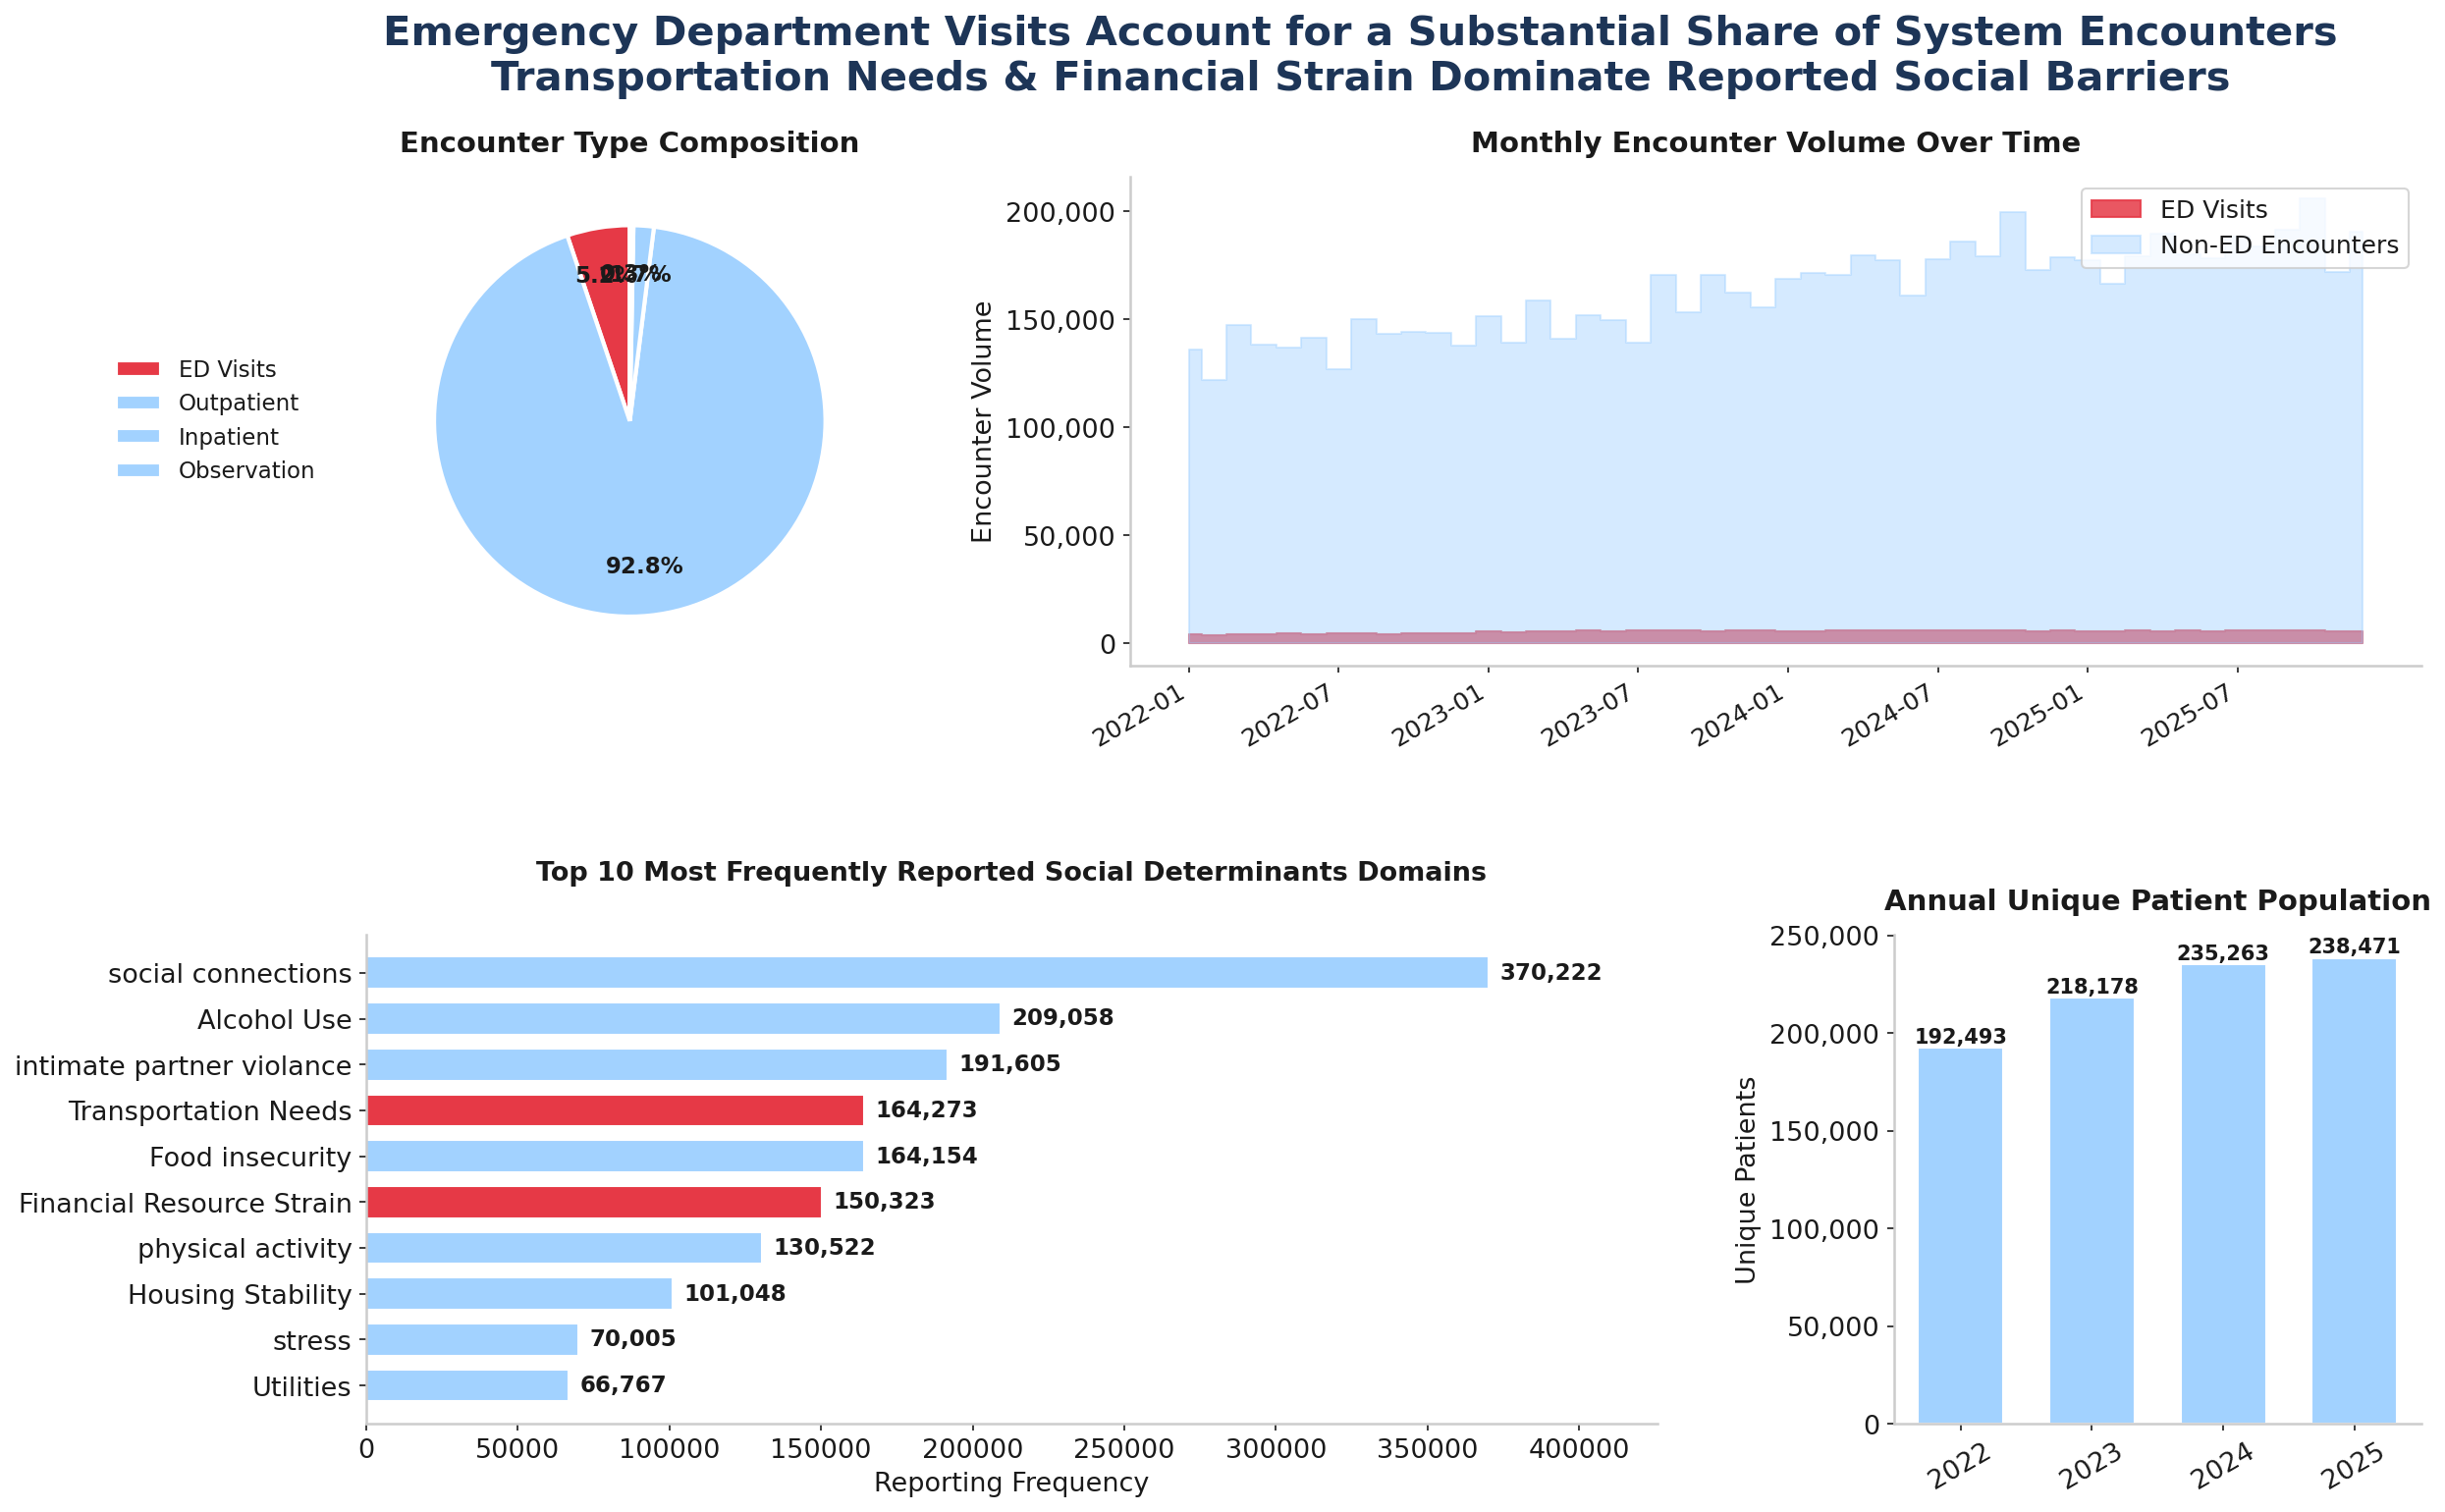

In [4]:
fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor("white")

fig.suptitle(
    "Emergency Department Visits Account for a Substantial Share of System Encounters\n"
    "Transportation Needs & Financial Strain Dominate Reported Social Barriers",
    fontsize=20, fontweight="bold", y=0.98, color="#1d3557"
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.45)

ax0 = fig.add_subplot(gs[0, 0])
visit_types = {
    "ED Visits":     enc["IsEdVisit"].sum(),
    "Outpatient":    enc["IsOutpatientFaceToFaceVisit"].sum() if "IsOutpatientFaceToFaceVisit" in enc.columns else 0,
    "Inpatient":     enc["IsInpatientAdmission"].sum()        if "IsInpatientAdmission"        in enc.columns else 0,
    "Observation":   enc["IsObservation"].sum()               if "IsObservation"               in enc.columns else 0,
}
visit_types = {k: v for k, v in visit_types.items() if v > 0}
pie_colors = [C_HIGHLIGHT if k == "ED Visits" else C_SOFT_BLUE for k in visit_types.keys()]
wedges, texts, autos = ax0.pie(
    visit_types.values(),
    labels=None,
    colors=pie_colors,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    textprops={"fontsize": 12, "fontweight": "bold"}
)
for auto in autos:
    auto.set_fontsize(11)
    auto.set_fontweight("bold")
ax0.legend(
    wedges,
    visit_types.keys(),
    loc="center right",
    bbox_to_anchor=(-0.1, 0.5),
    fontsize=11,
    frameon=False
)
ax0.set_title("Encounter Type Composition", fontweight="bold", fontsize=14, pad=12)

ax1 = fig.add_subplot(gs[0, 1:3])
enc["YearMonth"] = enc["Date"].dt.to_period("M")
monthly = enc.groupby(["YearMonth","IsEdVisit"]).size().unstack(fill_value=0)
monthly.index = monthly.index.astype(str)
if True in monthly.columns: ax1.fill_between(monthly.index, monthly[True], alpha=0.85, color=C_HIGHLIGHT, label="ED Visits", step="mid")
if False in monthly.columns: ax1.fill_between(monthly.index, monthly[False], alpha=0.45, color=C_SOFT_BLUE, label="Non-ED Encounters", step="mid")
step = max(1, len(monthly)//8)

ax1.set_xticks(range(0, len(monthly), step))
ax1.set_xticklabels(monthly.index[::step], rotation=30, ha="right", fontsize=12)
ax1.set_ylabel("Encounter Volume", fontsize=13)
ax1.set_title("Monthly Encounter Volume Over Time", fontweight="bold", fontsize=14, pad=12)
ax1.legend(fontsize=12, framealpha=0.8)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f"{int(x):,}"))
for sp in ["top","right"]: ax1.spines[sp].set_visible(False)

ax2 = fig.add_subplot(gs[1, 0:2])
domain_counts = soc["Domain"].value_counts().head(10)
cols_domain = [C_HIGHLIGHT if ("Transport" in d or "Financial" in d) else C_SOFT_BLUE for d in domain_counts.index]
bars = ax2.barh(domain_counts.index[::-1], domain_counts.values[::-1],
                color=list(reversed(cols_domain)), edgecolor="white", height=0.7)
for b in bars:
    ax2.text(b.get_width() + domain_counts.max()*0.01, b.get_y()+b.get_height()/2,
             f"{b.get_width():,}", va="center", fontsize=11, fontweight="bold")
ax2.set_xlabel("Reporting Frequency", fontsize=13)
ax2.set_title("Top 10 Most Frequently Reported Social Determinants Domains\n", fontweight="bold", fontsize=13, pad=12)
ax2.set_xlim(0, domain_counts.max() * 1.15)
for sp in ["top","right"]: ax2.spines[sp].set_visible(False)

ax3 = fig.add_subplot(gs[1, 2])
enc["Year"] = enc["Date"].dt.year
yearly_pat  = enc.groupby("Year")["PatientDurableKey"].nunique()
yearly_pat  = yearly_pat[yearly_pat.index > 2000]
bars_y = ax3.bar(yearly_pat.index.astype(str), yearly_pat.values,
                  color=C_SOFT_BLUE, edgecolor="white", width=0.65)
for b in bars_y:
    ax3.text(b.get_x()+b.get_width()/2, b.get_height() + yearly_pat.max()*0.01,
             f"{int(b.get_height()):,}", ha="center", fontsize=10, fontweight="bold")
ax3.set_ylabel("Unique Patients", fontsize=13)
ax3.set_title("Annual Unique Patient Population", fontweight="bold", fontsize=14, pad=12)
ax3.tick_params(axis="x", rotation=30)
ax3.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f"{int(x):,}"))
for sp in ["top","right"]: ax3.spines[sp].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### Baseline Observations

Across the multi-year Stormont Vail Health (SVH) records spanning hundreds of thousands of encounters and hundreds of thousands of unique patients, foundational patterns emerge:
1. **Emergency Department (ED) Encounters Form a Substantial Operational Load**: Acute ED visits represent a major share of acute interactions, exhibiting consistent seasonal and monthly volume.
2. **Concentration of Social Risk Domains**: Among all screened Social Determinants of Health (SDOH), two challenges stand out dramatically above all others: **Transportation Needs** and **Financial Resource Strain**.

These two barriers account for the overwhelming majority of positive SDOH screenings, indicating that patient physical mobility and economic vulnerability are the primary non-clinical headwinds shaping healthcare access across the region.


### Working Hypotheses & Analytical Framework

> *"A common assumption in health operations is that patients visit the Emergency Department primarily due to sudden, unforeseen clinical deterioration. However, real-world data reveals an alternative reality: vulnerable patients often turn to the ED as an unavoidable last resort when routine, proactive care channels fail."*

Patients who disproportionately utilize emergency services frequently exhibit documented socioeconomic vulnerabilities—specifically transportation deficits and severe financial strain. Lacking reliable transportation or unable to afford copays/routine care, these patients miss regular clinic appointments, leading to unmanaged disease progression that culminates in high-acuity, emergency presentations.

We rigorously investigate this hypothesis across four sequential dimensions:
1. **Headline Disparities**: Do patients with documented social barriers utilize the ED at significantly higher rates and frequencies than unscreened/barrier-free peers?
2. **Compound Risk & Disease Journeys**: Does the concurrence of *both* financial and transportation barriers multiply the likelihood of ED involvement across episodic disease journeys?
3. **Clinical Profile**: Are barrier-affected patients presenting with unpredictable acute emergencies, or are their encounters dominated by ambulatory care-sensitive chronic conditions?
4. **System Flow & Economic Impact**: Where in the outpatient referral network do wait-time bottlenecks arise, and what is the quantifiable financial cost of avoidable ED visits?


### 1.0 Headline Analysis: Social Barriers Drive Disproportionate Healthcare Utilization via Emergency Care

To evaluate the clinical and operational footprint of social barriers, we categorize surveyed patients into **four mutually exclusive cohorts**:
- **No Barrier**: Screened patients with no documented transportation or financial needs
- **Financial Only**: Documented financial resource strain without transportation barriers
- **Transport Only**: Documented transportation barriers without financial strain
- **Both Barriers**: Dual-burden patients reporting both transportation and financial barriers

We evaluate two primary metrics:
1. **ED Visit Rate (%)**: The proportion of each patient's total encounters that occur within the Emergency Department.
2. **Total Utilization Frequency**: The absolute 4-year encounter volume per patient.

*Key Analytical Check*: If patients with barriers were simply "lost to follow-up" or disengaged from care, their overall encounter volume would be lower. The empirical evidence demonstrates the exact opposite.


Total SVH Patients (with encounters):  359,760
Patients Screened for SDOH Barriers:   61,446

Barrier Breakdown (Patient Level):
Patient_Group
No Barrier        55519
Financial Only     2869
Both Barriers      1575
Transport Only     1483
Name: count, dtype: int64

=== HEADLINE UTILIZATION STATISTICS ===
                mean_ed_rate  mean_total  mean_ed  mean_non_ed  n_patients
Patient_Group                                                             
No Barrier              3.01       52.60     1.25        51.35       54641
Financial Only          5.39       61.31     2.56        58.75        2828
Transport Only          6.43       79.46     3.61        75.85        1439
Both Barriers          13.44       62.94     5.98        56.97        1547
[Kruskal-Wallis Test] ED rate across 4 barrier groups
  H = 1,719.35 | p < 0.001 (highly significant)
[Proportion + 95% Wilson CI] Proportion of patients with >=1 ED visit by barrier group
  Both Barriers: 71.2% (95% CI: 68.9%-73.4%), n=1,547
 

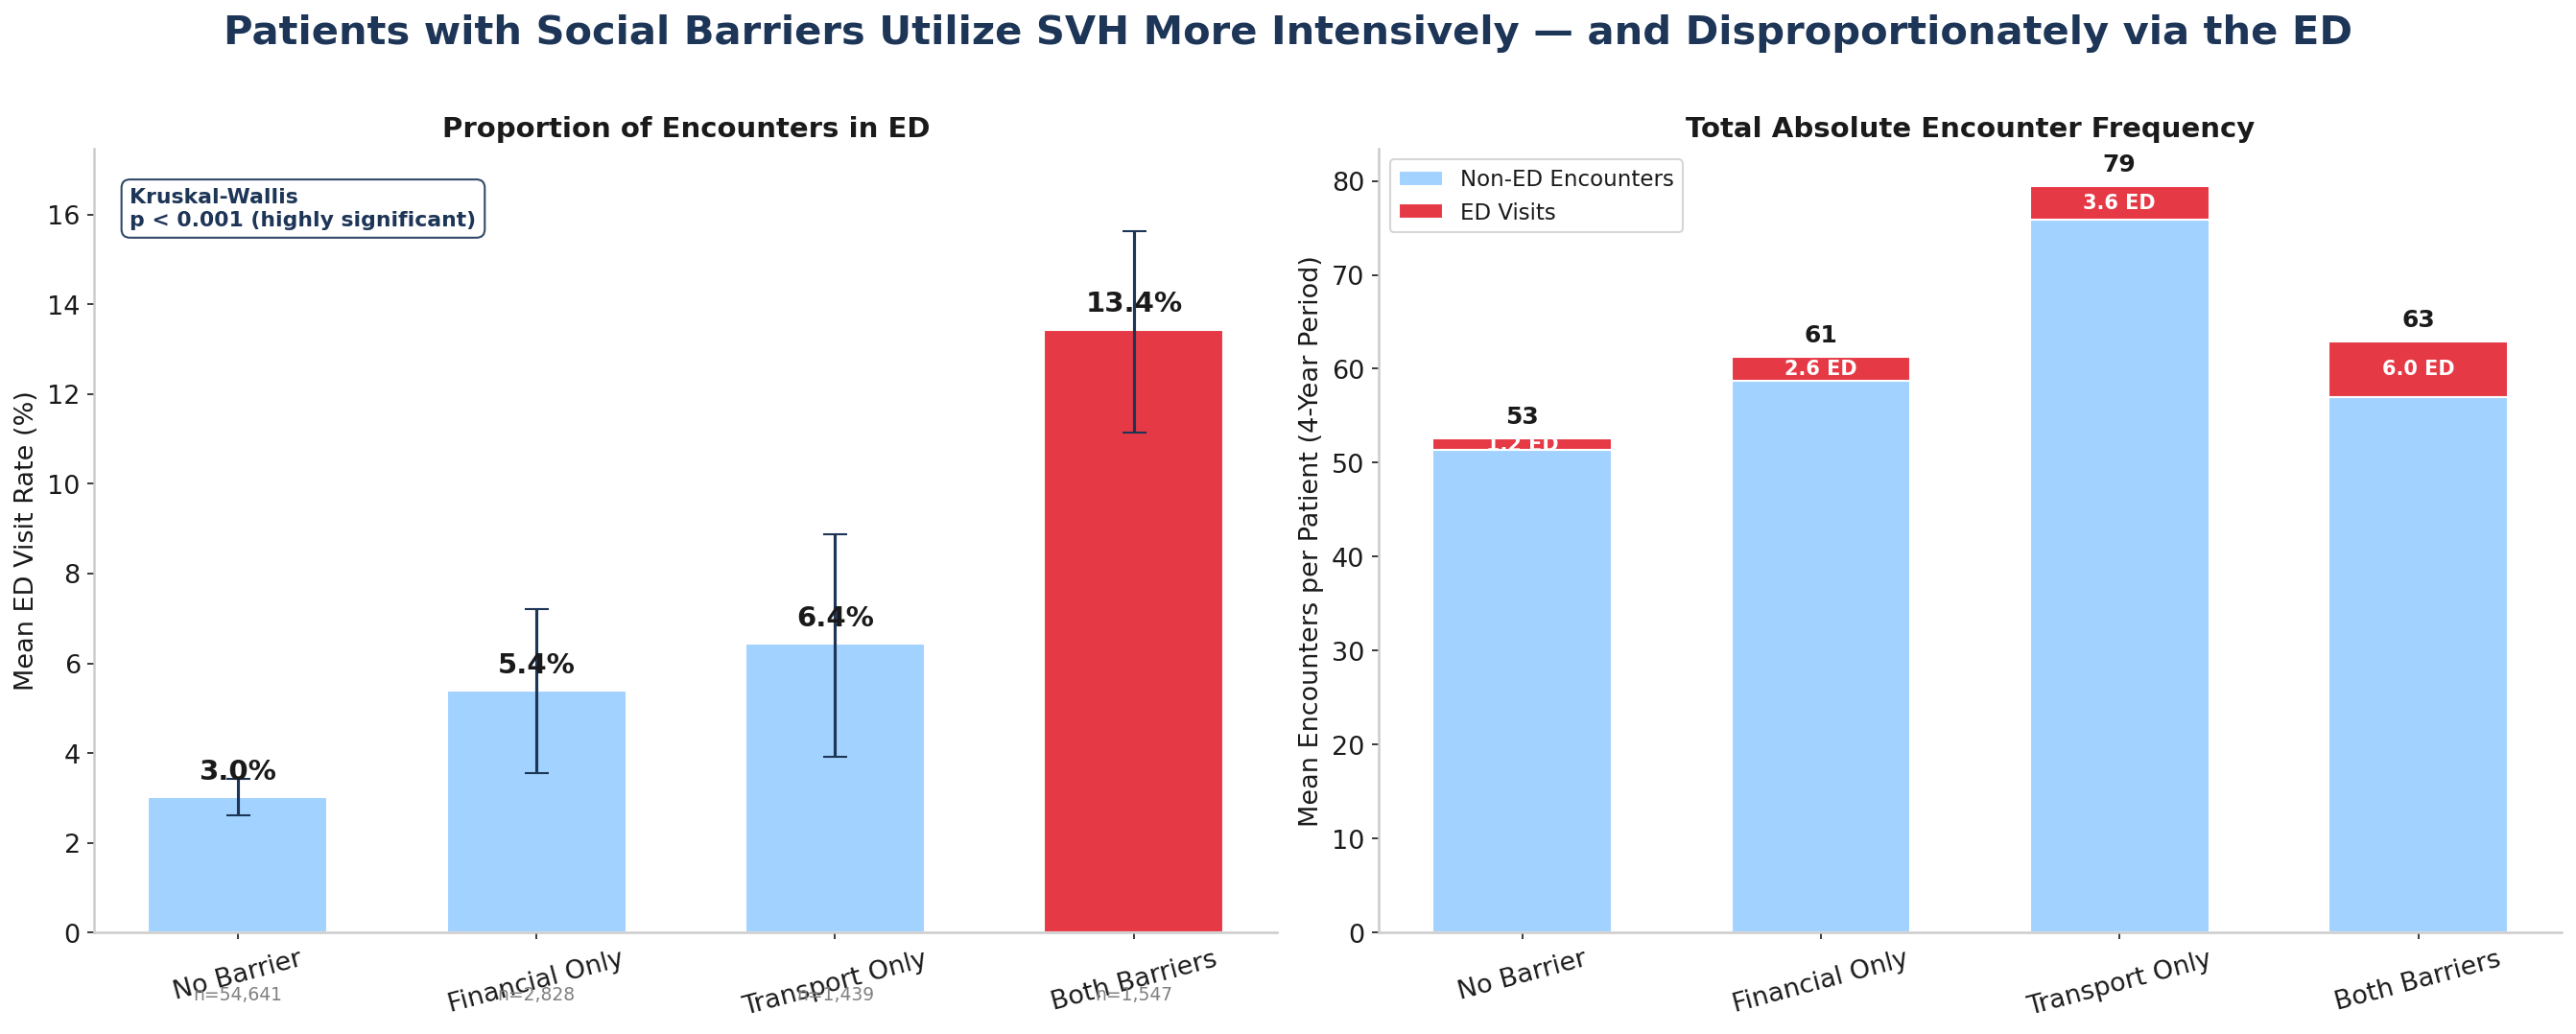

In [5]:
trans_yes = soc[
    (soc["Domain"] == "Transportation Needs") &
    (soc["AnswerText"].astype(str).str.strip().str.lower() == "yes")
]
transport_pos = set(trans_yes["PatientDurableKey"].unique())

fin_yes = soc[
    (soc["Domain"] == "Financial Resource Strain") &
    (soc["AnswerText"].astype(str).str.strip().str.lower().isin(["yes", "already shut off"]))
]
financial_pos = set(fin_yes["PatientDurableKey"].unique())

surveyed_set = set(
    soc[soc["Domain"].isin(["Transportation Needs", "Financial Resource Strain"])]
    ["PatientDurableKey"].unique()
)

def patient_label(pid):
    has_t = pid in transport_pos
    has_f = pid in financial_pos
    if has_t and has_f: return "Both Barriers"
    if has_t: return "Transport Only"
    if has_f: return "Financial Only"
    return "No Barrier"

patient_lookup = pd.DataFrame({
    "PatientDurableKey": list(surveyed_set)
})
patient_lookup["Patient_Group"] = patient_lookup["PatientDurableKey"].apply(patient_label)

print(f"Total SVH Patients (with encounters):  {master['PatientDurableKey'].nunique():,}")
print(f"Patients Screened for SDOH Barriers:   {len(surveyed_set):,}")
print(f"\nBarrier Breakdown (Patient Level):")
print(patient_lookup["Patient_Group"].value_counts())

patient_enc = enc[enc["PatientDurableKey"].isin(surveyed_set)].groupby("PatientDurableKey").agg(
    total_visits=("EncounterKey","count"),
    ed_visits=("IsEdVisit","sum")
).reset_index()

patient_summary = patient_enc.merge(patient_lookup, on="PatientDurableKey", how="inner")
patient_summary["non_ed_visits"] = patient_summary["total_visits"] - patient_summary["ed_visits"]
patient_summary["ed_rate"] = patient_summary["ed_visits"] / patient_summary["total_visits"] * 100

patient_summary["Barrier_Group"] = patient_summary["Patient_Group"]

order = ["No Barrier","Financial Only","Transport Only","Both Barriers"]
hl = patient_summary.groupby("Patient_Group").agg(
    mean_ed_rate=("ed_rate","mean"),
    mean_total=("total_visits","mean"),
    mean_ed=("ed_visits","mean"),
    mean_non_ed=("non_ed_visits","mean"),
    n_patients=("PatientDurableKey","count")
).reindex(order)
print("\n=== HEADLINE UTILIZATION STATISTICS ===")
print(hl.round(2))

kw_stat, kw_p = run_kruskal(patient_summary, "Patient_Group", "ed_rate",
                             label="ED rate across 4 barrier groups")

patient_summary["ed_visit_flag"] = (patient_summary["ed_visits"] > 0).astype(int)
ci_headline = run_wilson_ci(patient_summary, "Patient_Group", "ed_visit_flag",
                             label="Proportion of patients with >=1 ED visit by barrier group")
ci_headline = ci_headline.reindex(order)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("white")
fig.suptitle(
    "Patients with Social Barriers Utilize SVH More Intensively — and Disproportionately via the ED",
    fontsize=20, fontweight="bold", y=1.02, color="#1d3557"
)

colors_4 = [C_HIGHLIGHT if g == "Both Barriers" else C_SOFT_BLUE for g in order]

ax = axes[0]
ed_vals = hl["mean_ed_rate"].values
err_low  = (ci_headline["prop"] - ci_headline["ci_low"]).values * 100
err_high = (ci_headline["ci_high"] - ci_headline["prop"]).values * 100
bars = ax.bar(order, ed_vals, color=colors_4, edgecolor="white", width=0.6,
              yerr=[np.nan_to_num(err_low), np.nan_to_num(err_high)],
              capsize=6, error_kw=dict(elinewidth=1.5, ecolor="#1d3557"))
ax.set_ylabel("Mean ED Visit Rate (%)", fontsize=13)
ax.set_title("Proportion of Encounters in ED", fontweight="bold", fontsize=14)
ax.set_ylim(0, max(ed_vals)*1.3)
ax.tick_params(axis="x", rotation=15)
for b, v, n in zip(bars, ed_vals, hl["n_patients"]):
    ax.text(b.get_x()+b.get_width()/2, v+0.4, f"{v:.1f}%",
            ha="center", fontweight="bold", fontsize=14)
    ax.text(b.get_x()+b.get_width()/2, -1.5, f"n={int(n):,}",
            ha="center", fontsize=9, color="grey")
for sp in ["top","right"]: ax.spines[sp].set_visible(False)
stat_annotation(ax, f"Kruskal-Wallis\n{sig_label(kw_p)}", loc="upper left")

ax = axes[1]
mean_ed = hl["mean_ed"].values
mean_non_ed = hl["mean_non_ed"].values
mean_total = hl["mean_total"].values
x = range(len(order))
ax.bar(x, mean_non_ed, color=C_SOFT_BLUE, edgecolor="white", width=0.6, label="Non-ED Encounters")
ax.bar(x, mean_ed, bottom=mean_non_ed, color=C_HIGHLIGHT, edgecolor="white", width=0.6, label="ED Visits")
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=15)
ax.set_ylabel("Mean Encounters per Patient (4-Year Period)", fontsize=13)
ax.set_title("Total Absolute Encounter Frequency", fontweight="bold", fontsize=14)
ax.legend(loc="upper left", fontsize=11)
for sp in ["top","right"]: ax.spines[sp].set_visible(False)
for i, (ne, e, tot) in enumerate(zip(mean_non_ed, mean_ed, mean_total)):
    ax.text(i, tot + max(mean_total)*0.02, f"{tot:.0f}",
            ha="center", fontweight="bold", fontsize=12)
    if e > 1:
        ax.text(i, ne + e/2, f"{e:.1f} ED", ha="center", va="center",
                color="white", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.show()


### Interpretation: Headline Utilization Findings

The empirical data demonstrates two compelling, mutually reinforcing dynamics:

1. **Progressive Surge in ED Reliance**:
   - The mean ED visit rate climbs systematically with cumulative barrier burden: **3.01%** for No Barrier $\rightarrow$ **5.39%** for Financial Only $\rightarrow$ **6.43%** for Transport Only $\rightarrow$ **13.44%** for Both Barriers.
   - Similarly, the proportion of patients with at least one ED encounter surges from **41.6%** (95% CI: 41.2%–42.0%) in the No Barrier cohort to **57.4%** (Financial Only), **63.9%** (Transport Only), and **71.2%** (95% CI: 68.9%–73.4%) among patients facing Both Barriers.
   - The non-parametric **Kruskal-Wallis test** confirms this gradient is highly statistically significant ($H = 1,719.35, p < 0.001$), ruling out random variation.

2. **High-Intensity System Utilization ("Wrong Door" Phenomenon)**:
   - Patients burdened by social barriers are **not absent or unengaged**—in fact, they generate substantially *higher* total encounters over 4 years (**79.46** mean visits for Transport Only, **62.94** for Both Barriers, and **61.31** for Financial Only vs. **52.60** for No Barrier).
   - Furthermore, patients with Both Barriers average **5.98 ED visits** per patient—nearly five times the baseline of **1.25 ED visits** for patients without barriers.

**Clinical & Operational Implication**: Social barriers do not diminish a patient's need for healthcare services; rather, they obstruct access to scheduled ambulatory clinics and funnel ongoing medical demand through the Emergency Department—the costliest and least continuous delivery channel.


### 1.1 Disease Journey Burden: Encounter Intensity by Barrier Profile

Does the accumulation of socioeconomic barriers increase the encounter burden within individual clinical disease journeys (`PatientDurableKey` $\times$ `DiagnosisValue`)?


[Kruskal-Wallis Test] Encounter count per disease journey across Barrier Groups
  H = 154.72 | p < 0.001 (highly significant)


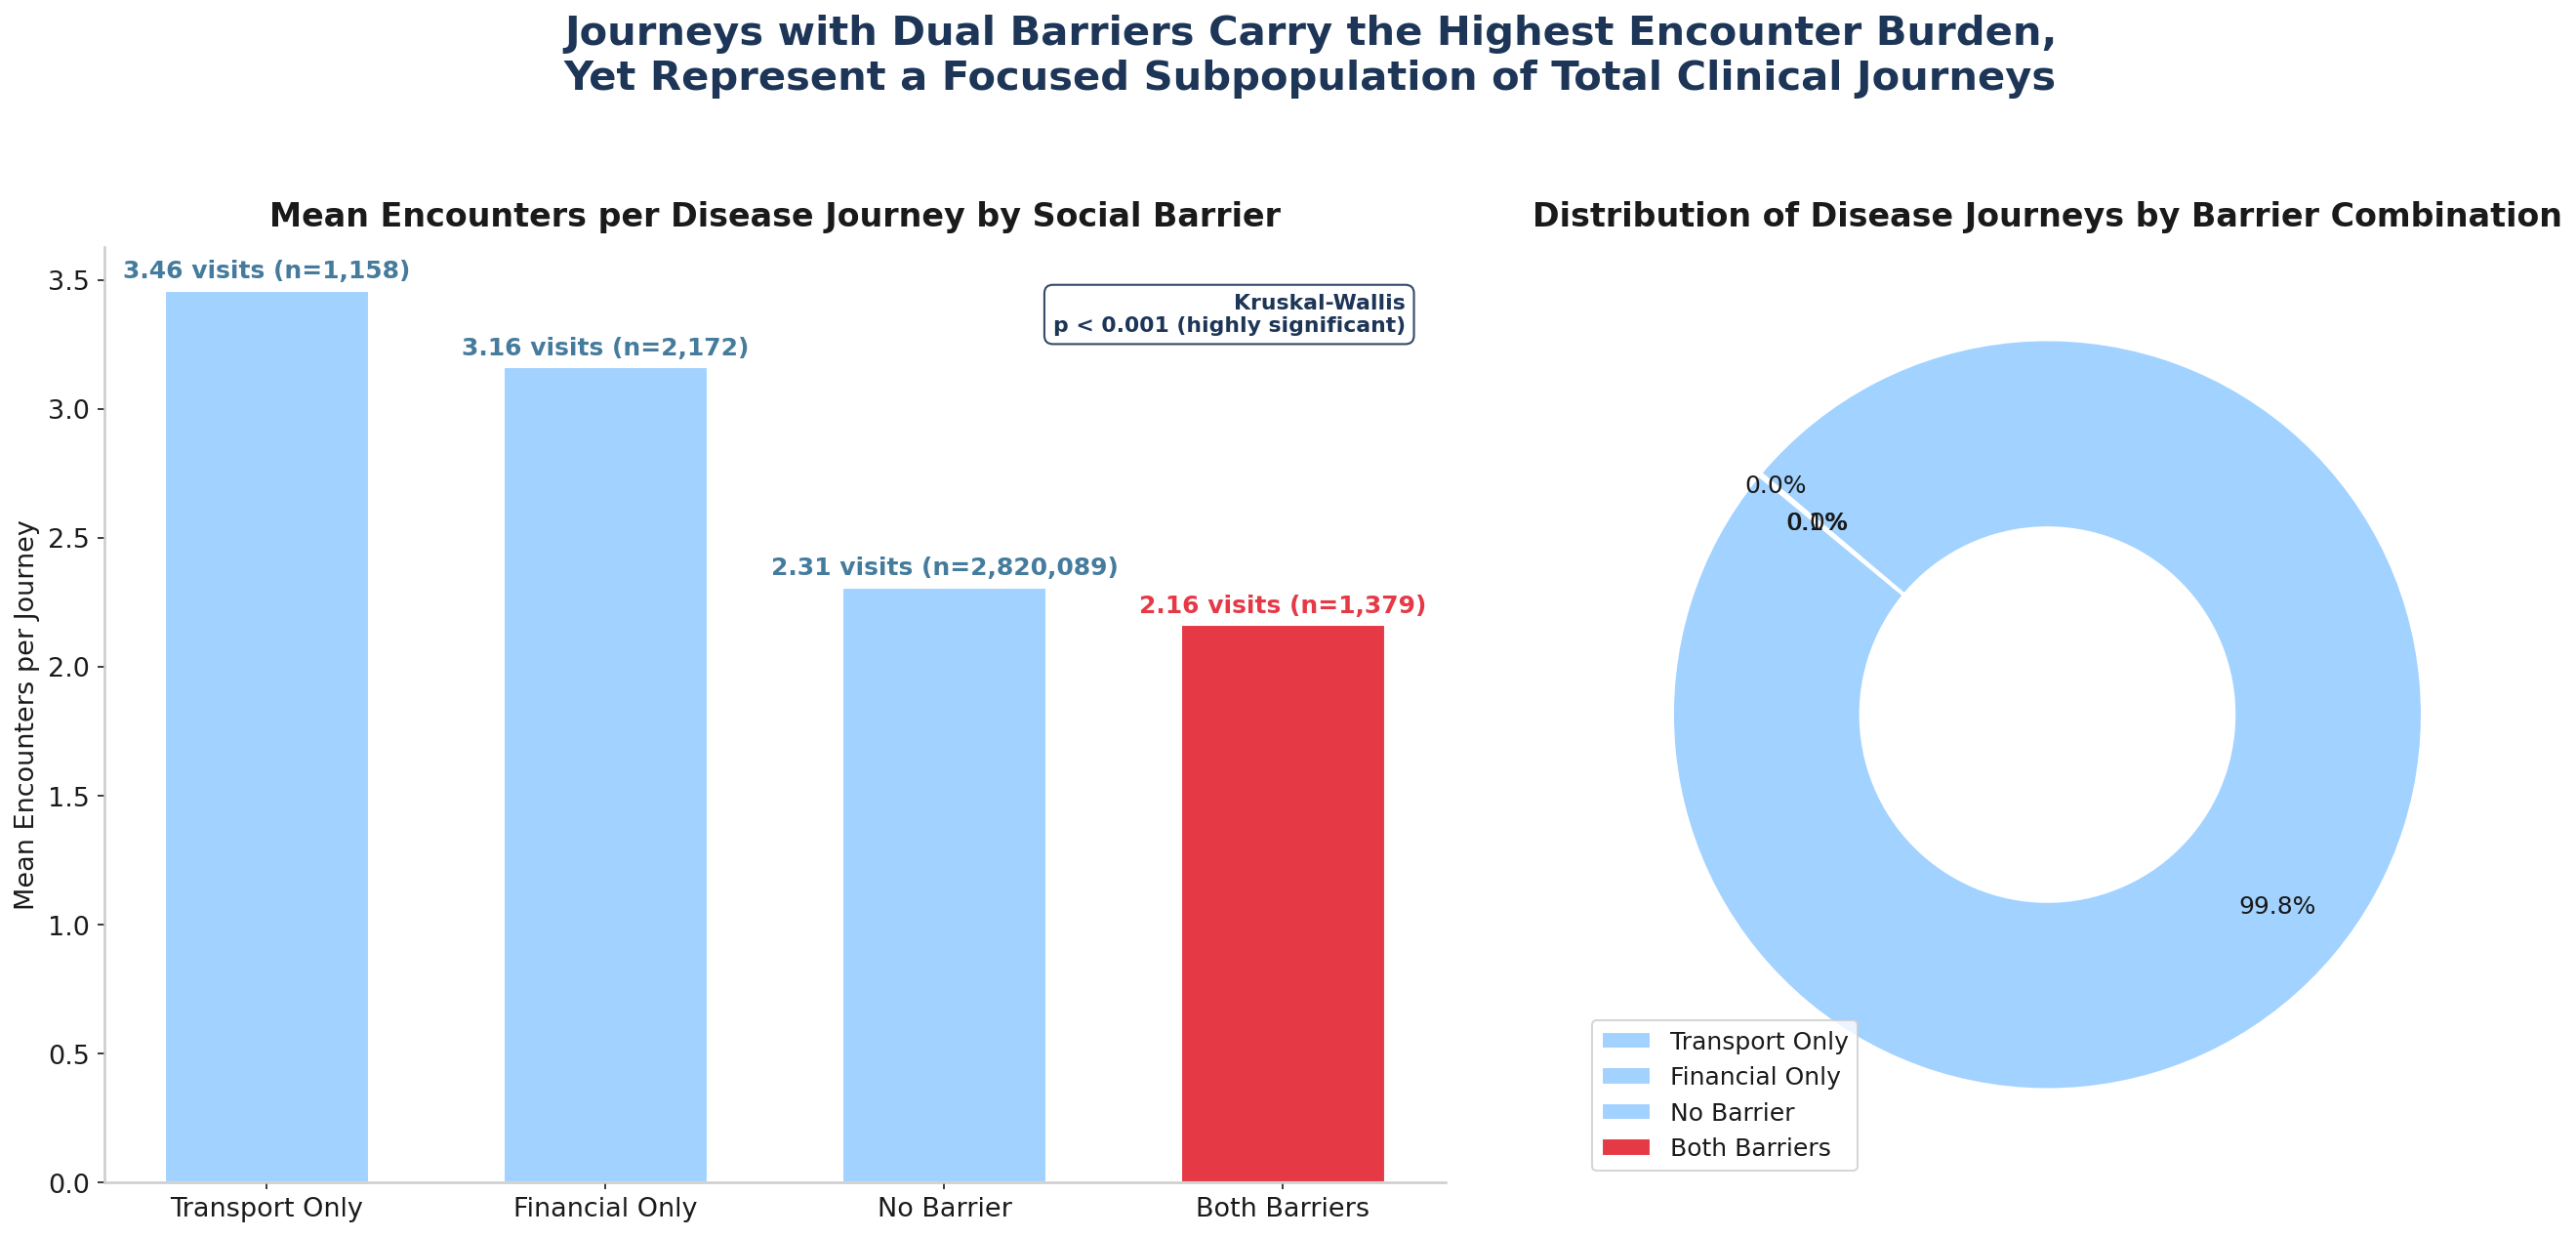

In [6]:
journey_summary = master.groupby(["PatientDurableKey","DiagnosisValue"]).agg(
    VisitCount    = ("EncounterKey","count"),
    Barrier_Group = ("Barrier_Group","first")
).reset_index()

avg_visits_df = (journey_summary.groupby("Barrier_Group")["VisitCount"]
                 .mean()
                 .reset_index()
                 .sort_values("VisitCount", ascending=False))

sorted_order = avg_visits_df["Barrier_Group"].tolist()
avg_values   = avg_visits_df["VisitCount"].tolist()

counts_map = journey_summary["Barrier_Group"].value_counts()
pop_abs    = counts_map.reindex(sorted_order).fillna(0)
pop_dist   = (counts_map / len(journey_summary) * 100).reindex(sorted_order).fillna(0)

current_colors = [C_HIGHLIGHT if "Both" in str(n) else C_SOFT_BLUE for n in sorted_order]

kw_stat2, kw_p2 = run_kruskal(journey_summary, "Barrier_Group", "VisitCount",
                               label="Encounter count per disease journey across Barrier Groups")

fig = plt.figure(figsize=(18, 8))
fig.patch.set_facecolor("white")
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1])
fig.suptitle(
    "Journeys with Dual Barriers Carry the Highest Encounter Burden,\nYet Represent a Focused Subpopulation of Total Clinical Journeys",
    fontsize=20,
    fontweight="bold",
    color="#1d3557",
    y=1.05
)

ax1 = fig.add_subplot(gs[0])
bars1 = ax1.bar(sorted_order, avg_values, color=current_colors, width=0.6, edgecolor="white")
ax1.set_title("Mean Encounters per Disease Journey by Social Barrier", fontsize=16, fontweight="bold", pad=10)
ax1.set_ylabel("Mean Encounters per Journey", fontsize=13)
sns.despine(ax=ax1); ax1.grid(False)

highlight_rgba = mpl.colors.to_rgba(C_HIGHLIGHT)
for b, v, n in zip(bars1, avg_values, pop_abs.values):
    is_h = tuple(b.get_facecolor()) == highlight_rgba
    ax1.text(b.get_x()+b.get_width()/2, v+0.05,
             f"{v:.2f} visits (n={n:,.0f})",
             ha="center",
             fontsize=12,
             fontweight="bold",
             color=C_HIGHLIGHT if is_h else C_MUTED_TEXT)
stat_annotation(ax1, f"Kruskal-Wallis\n{sig_label(kw_p2)}", loc="upper right")

ax2  = fig.add_subplot(gs[1])
expl = [0.15 if "Both" in str(n) else 0 for n in sorted_order]
wedges, texts, autos = ax2.pie(
    pop_dist.values,
    autopct="%1.1f%%",
    startangle=140,
    explode=expl,
    colors=current_colors,
    wedgeprops=dict(width=0.5, edgecolor="white"),
    pctdistance=0.8,
    textprops={"fontsize": 12}
)
ax2.set_title("Distribution of Disease Journeys by Barrier Combination", fontsize=16, fontweight="bold", pad=10)
ax2.legend(sorted_order, loc="lower left", fontsize=12)

plt.tight_layout()
plt.show()


### 1.2 Compound Risk: The Synergistic Effect on Emergency Department Probability

Transportation obstacles and financial strain frequently co-occur. Does their simultaneous presence compound risk non-linearly, resulting in an escalated likelihood of acute ED involvement during an illness episode?


[Chi-Square Test] Any Barrier vs ED Encounter Status
  chi2 = 6,074.02 | dof = 1 | p < 0.001 (highly significant) | Cramer's V = 0.046
[Chi-Square Test] Detailed Barrier Group vs ED Encounter Status
  chi2 = 6,438.43 | dof = 3 | p < 0.001 (highly significant) | Cramer's V = 0.048
[Proportion + 95% Wilson CI] % Journeys with ED Visit: Any Barrier vs None
  False: 8.4% (95% CI: 8.4%-8.4%), n=2,820,089
  True: 40.1% (95% CI: 38.7%-41.5%), n=4,709
[Proportion + 95% Wilson CI] % Journeys with ED Visit by Barrier Combination
  Both Barriers: 51.4% (95% CI: 48.8%-54.0%), n=1,379
  Financial Only: 33.2% (95% CI: 31.3%-35.3%), n=2,172
  No Barrier: 8.4% (95% CI: 8.4%-8.4%), n=2,820,089
  Transport Only: 39.4% (95% CI: 36.6%-42.2%), n=1,158


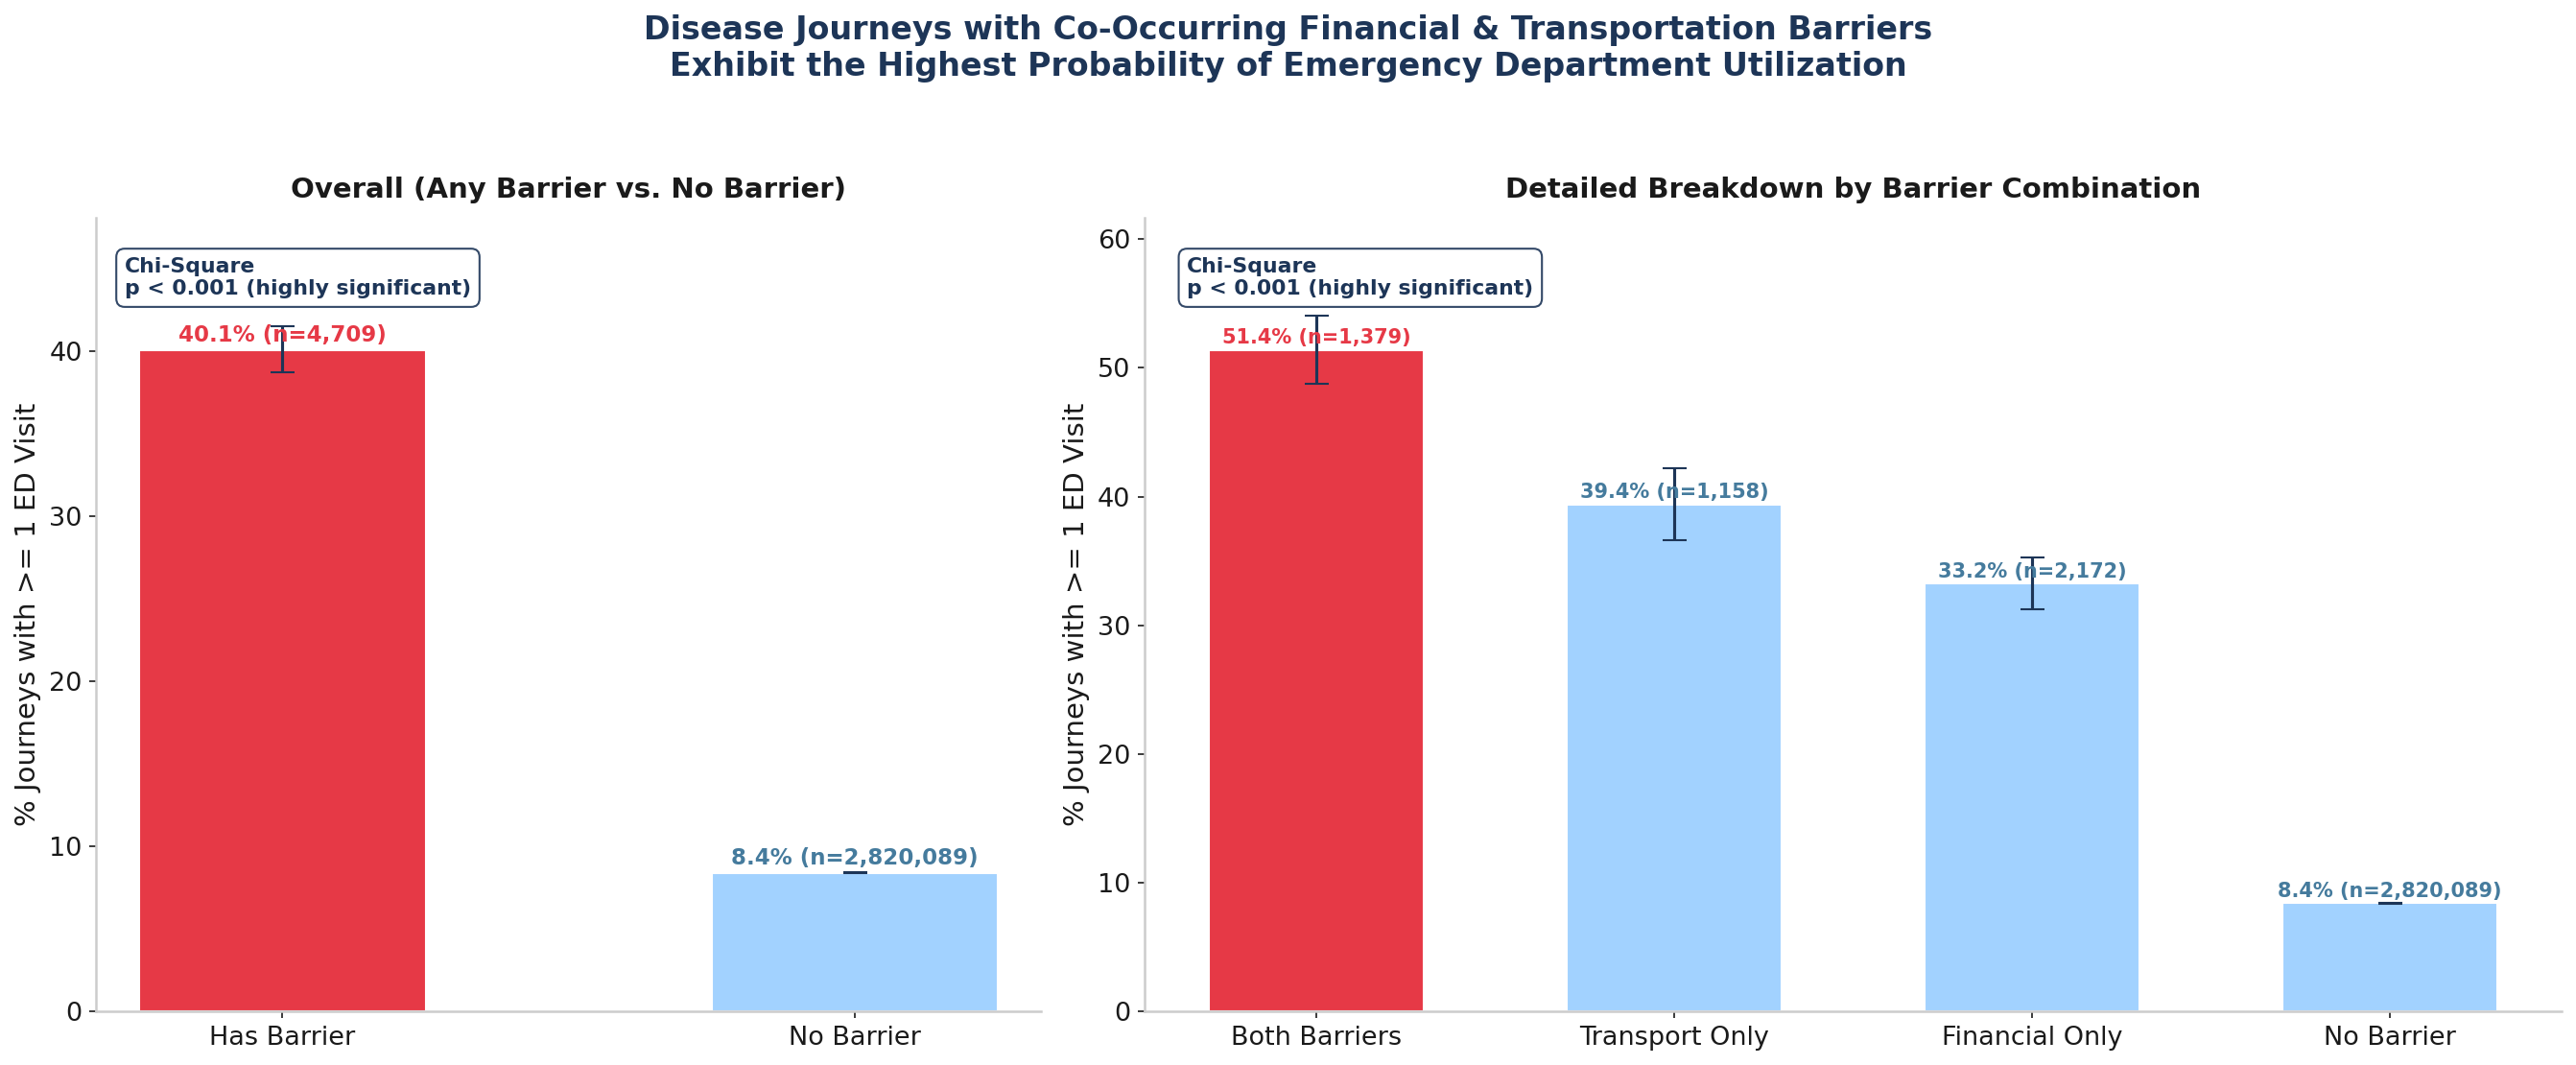

In [7]:
journey_ed_status = master.groupby(["PatientDurableKey","DiagnosisValue"]).agg(
    IsEdVisit     = ("IsEdVisit","max"),
    Any_Barrier   = ("Any_Barrier","max"),
    Barrier_Group = ("Barrier_Group","first")
).reset_index()

pat_bar_gen_df = (journey_ed_status.groupby("Any_Barrier")["IsEdVisit"]
                  .mean().mul(100).reset_index())
pat_bar_gen_df["label"] = pat_bar_gen_df["Any_Barrier"].map({
    True : "Has Barrier",
    False : "No Barrier"
})
pat_bar_gen_df = pat_bar_gen_df.sort_values("IsEdVisit", ascending=False)
n_pat_gen = journey_ed_status.groupby("Any_Barrier").size()

pat_bar_det_df = (journey_ed_status.groupby("Barrier_Group")["IsEdVisit"]
                  .mean().mul(100).reset_index()
                  .sort_values("IsEdVisit", ascending=False))
n_pat_det = journey_ed_status.groupby("Barrier_Group").size()

chi2_1, chi_p1, cv1 = run_chi2(journey_ed_status, "Any_Barrier", "IsEdVisit",
                                label="Any Barrier vs ED Encounter Status")
chi2_2, chi_p2, cv2 = run_chi2(journey_ed_status, "Barrier_Group", "IsEdVisit",
                                label="Detailed Barrier Group vs ED Encounter Status")

ci_gen = run_wilson_ci(journey_ed_status, "Any_Barrier", "IsEdVisit",
                        label="% Journeys with ED Visit: Any Barrier vs None")
ci_det = run_wilson_ci(journey_ed_status, "Barrier_Group", "IsEdVisit",
                        label="% Journeys with ED Visit by Barrier Combination")

fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={"width_ratios":[1,1.5]})
fig.patch.set_facecolor("white")
fig.suptitle(
    "Disease Journeys with Co-Occurring Financial & Transportation Barriers\n"
    "Exhibit the Highest Probability of Emergency Department Utilization",
    fontsize=16, fontweight="bold", color="#1d3557", y=1.05
)

ax1 = axes[0]
colors_gen = [C_HIGHLIGHT if "Has Barrier" == lbl else C_SOFT_BLUE
              for lbl in pat_bar_gen_df["label"]]
ci_gen_ordered = ci_gen.reindex([True if l=="Has Barrier" else False for l in pat_bar_gen_df["label"]])
err1 = [np.nan_to_num((ci_gen_ordered["prop"]-ci_gen_ordered["ci_low"]).values*100),
        np.nan_to_num((ci_gen_ordered["ci_high"]-ci_gen_ordered["prop"]).values*100)]
bars1 = ax1.bar(pat_bar_gen_df["label"],
                pat_bar_gen_df["IsEdVisit"],
                color=colors_gen,
                width=0.5,
                edgecolor="white",
                yerr=err1, capsize=6, error_kw=dict(elinewidth=1.5, ecolor="#1d3557"))
ax1.set_title("Overall (Any Barrier vs. No Barrier)", fontsize=14, fontweight="bold", pad=10)
ax1.set_ylabel("% Journeys with >= 1 ED Visit", fontsize=14)
ax1.set_ylim(0, max(pat_bar_gen_df["IsEdVisit"]) * 1.2)
for b, label, v in zip(bars1, pat_bar_gen_df["label"], pat_bar_gen_df["IsEdVisit"]):
    orig_key = True if "Has Barrier" == label else False
    n = n_pat_gen.get(orig_key, 0)
    ax1.text(b.get_x()+b.get_width()/2, v+0.5,
             f"{v:.1f}% (n={n:,})",
             ha="center", fontsize=11, fontweight="bold",
             color=C_HIGHLIGHT if "Has Barrier"==label else C_MUTED_TEXT)
for sp in ["top","right"]: ax1.spines[sp].set_visible(False)
stat_annotation(ax1, f"Chi-Square\n{sig_label(chi_p1)}", loc="upper left")

ax2 = axes[1]
colors_det = [C_HIGHLIGHT if i==0 else C_SOFT_BLUE for i, _ in enumerate(pat_bar_det_df["Barrier_Group"])]
ci_det_ordered = ci_det.reindex(pat_bar_det_df["Barrier_Group"])
err2 = [np.nan_to_num((ci_det_ordered["prop"]-ci_det_ordered["ci_low"]).values*100),
        np.nan_to_num((ci_det_ordered["ci_high"]-ci_det_ordered["prop"]).values*100)]
bars2 = ax2.bar(pat_bar_det_df["Barrier_Group"],
                pat_bar_det_df["IsEdVisit"],
                color=colors_det,
                width=0.6,
                edgecolor="white",
                yerr=err2, capsize=6, error_kw=dict(elinewidth=1.5, ecolor="#1d3557"))
ax2.set_title("Detailed Breakdown by Barrier Combination", fontsize=14, fontweight="bold", pad=10)
ax2.set_ylabel("% Journeys with >= 1 ED Visit", fontsize=14)
ax2.set_ylim(0, max(pat_bar_det_df["IsEdVisit"]) * 1.2)
for b, grp, v in zip(bars2, pat_bar_det_df["Barrier_Group"], pat_bar_det_df["IsEdVisit"]):
    n = n_pat_det.get(grp, 0)
    ax2.text(b.get_x()+b.get_width()/2, v+0.5,
             f"{v:.1f}% (n={n:,})", ha="center", fontsize=10, fontweight="bold",
             color=C_HIGHLIGHT if grp == pat_bar_det_df["Barrier_Group"].iloc[0] else C_MUTED_TEXT)
for sp in ["top","right"]: ax2.spines[sp].set_visible(False)
stat_annotation(ax2, f"Chi-Square\n{sig_label(chi_p2)}", loc="upper left")

plt.tight_layout()
plt.show()


### 1.3 Clinical Spectrum: Chronic Illness Dominates Barrier-Affected Cohorts

To evaluate whether ED utilization among barrier-affected individuals stems from acute trauma versus unmanaged chronic illness, we analyze primary clinical diagnoses recorded across barrier-involved encounters.


[Chi-Square Test] Diagnosis Distribution (Top-10 vs Others) — Barrier vs No Barrier
  chi2 = 80,822.07 | dof = 10 | p < 0.001 (highly significant) | Cramer's V = 0.095


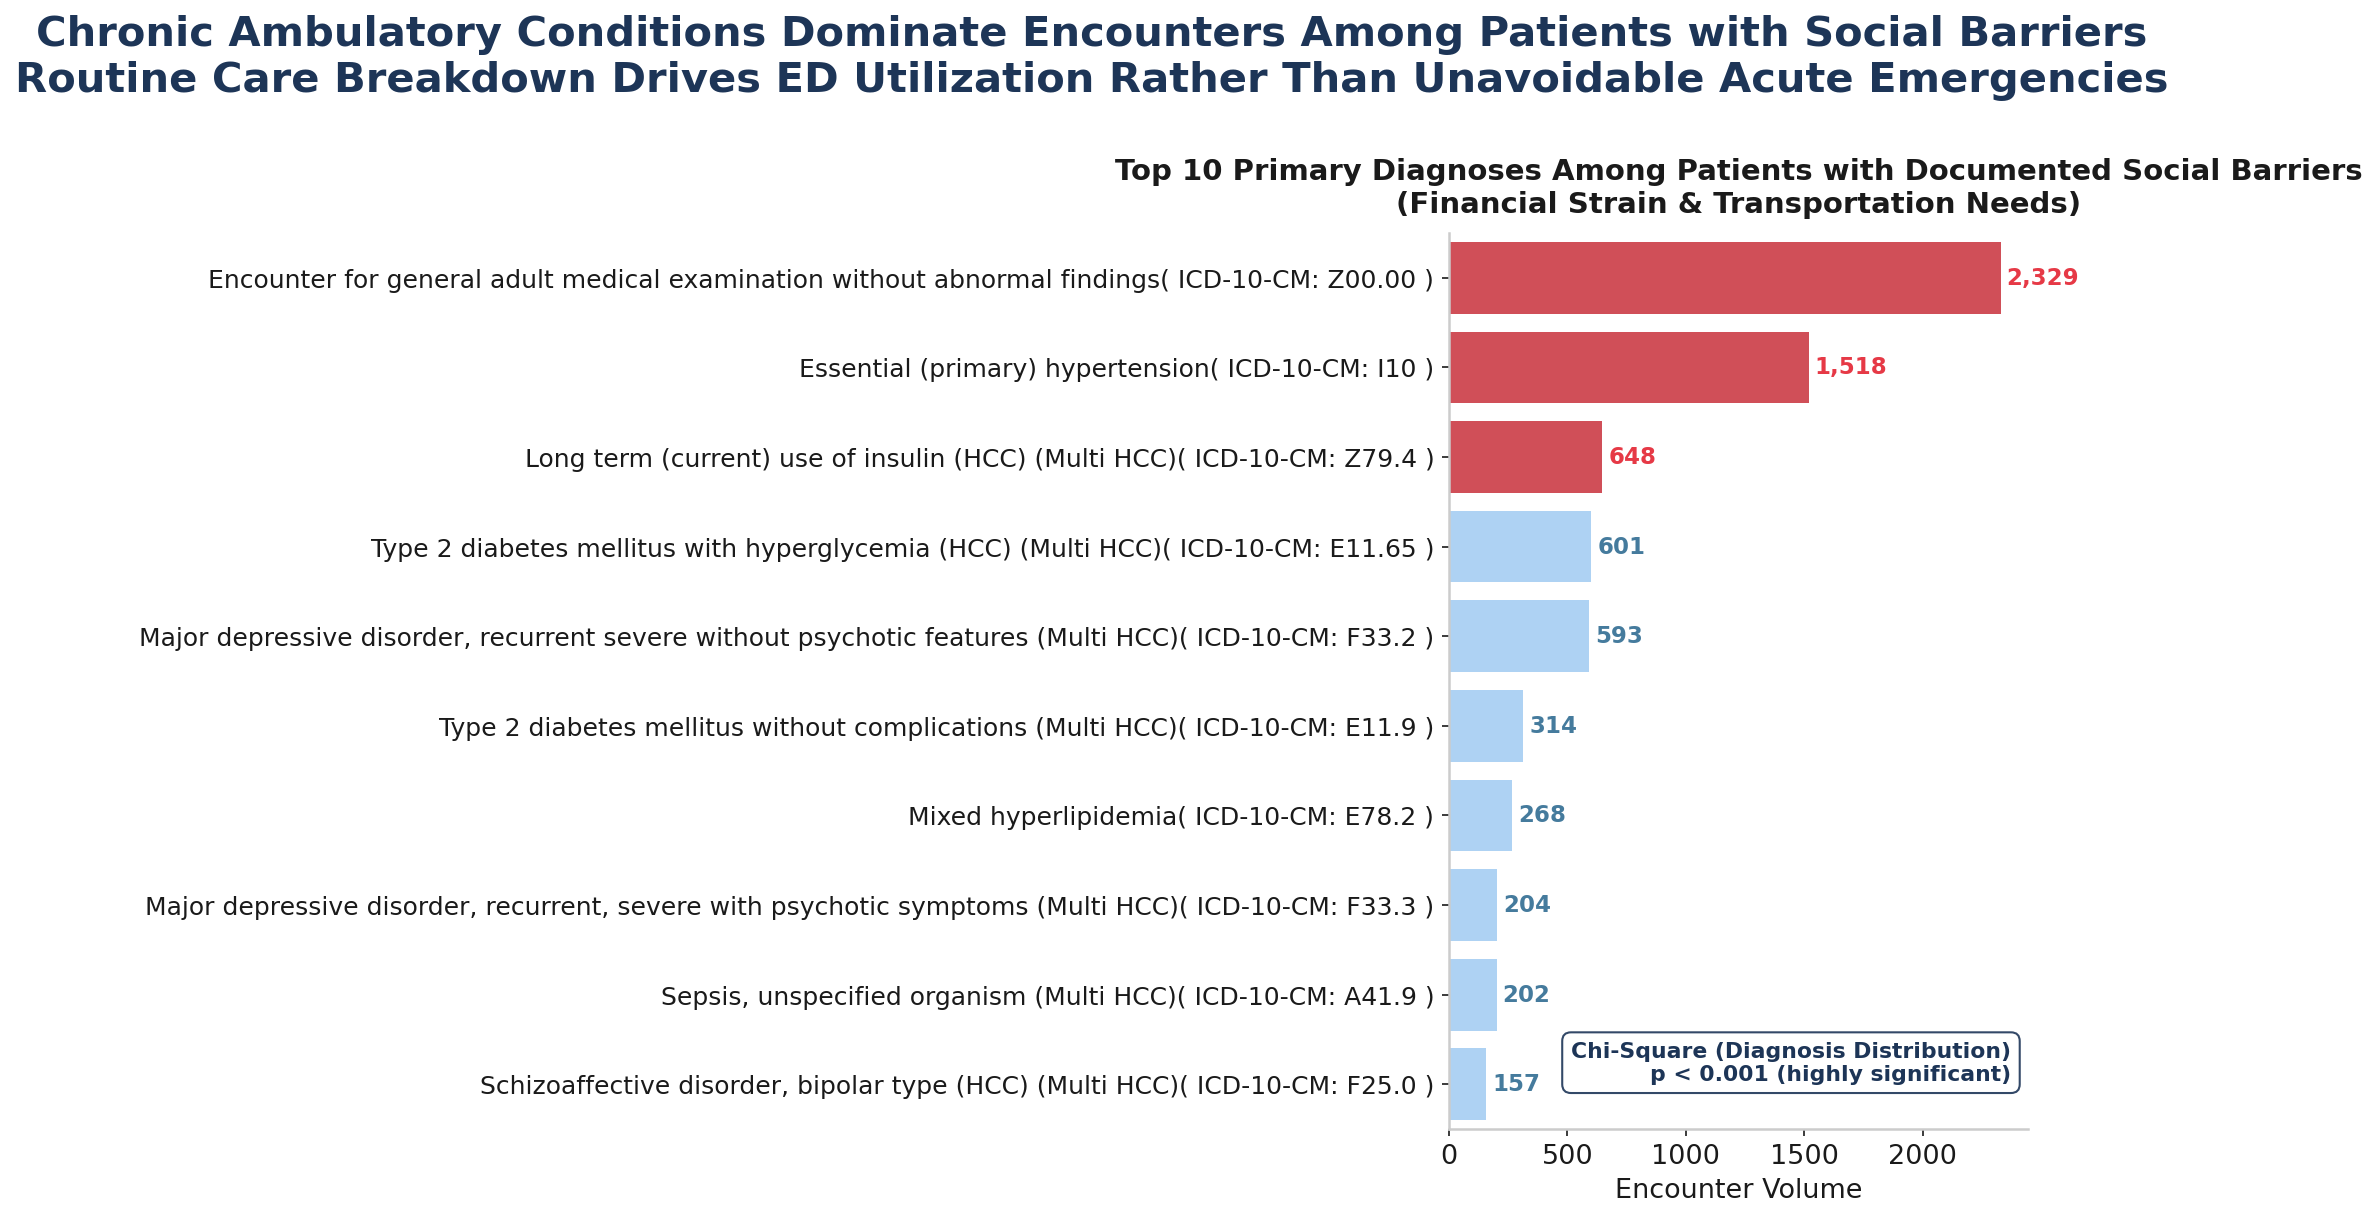

In [8]:
master_full = master.merge(
    diag[["DiagnosisKey","DiagnosisName"]],
    left_on="PrimaryDiagnosisKey",
    right_on="DiagnosisKey",
    how="left"
)

barrier_only    = master_full[master_full["Barrier_Group"] != "No Barrier"].copy()
top_10_diseases = barrier_only["DiagnosisName"].value_counts().nlargest(10).index
plot_data       = barrier_only[barrier_only["DiagnosisName"].isin(top_10_diseases)]

diag_compare = master_full.copy()
diag_compare["HasBarrier"]   = diag_compare["Barrier_Group"] != "No Barrier"
diag_compare["DiagCategory"] = np.where(diag_compare["DiagnosisName"].isin(top_10_diseases),
                                         diag_compare["DiagnosisName"], "Other")
chi2_d, chi_p_d, cv_d = run_chi2(diag_compare, "HasBarrier", "DiagCategory",
                                  label="Diagnosis Distribution (Top-10 vs Others) — Barrier vs No Barrier")

fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor("white")

custom_palette = [C_HIGHLIGHT if i < 3 else C_SOFT_BLUE for i in range(len(top_10_diseases))]

ax = sns.countplot(data=plot_data,
                   y="DiagnosisName",
                   order=top_10_diseases,
                   palette=custom_palette,
                   edgecolor=None, ax=ax)

fig.suptitle(
    "Chronic Ambulatory Conditions Dominate Encounters Among Patients with Social Barriers\n"
    "Routine Care Breakdown Drives ED Utilization Rather Than Unavoidable Acute Emergencies",
    fontsize=20,
    fontweight="bold",
    y=1.01,
    color="#1d3557"
)
ax.set_title("Top 10 Primary Diagnoses Among Patients with Documented Social Barriers\n(Financial Strain & Transportation Needs)",
             fontsize=14,
             fontweight="bold",
             pad=10)
ax.set_xlabel("Encounter Volume", fontsize=13)
ax.set_ylabel("", fontsize=1)
ax.grid(False); sns.despine()
ax.tick_params(axis="y", labelsize=12)

for i, p in enumerate(ax.patches):
    width = p.get_width()
    if width > 0:
        text_color = C_HIGHLIGHT if i < 3 else C_MUTED_TEXT
        ax.text(width + (ax.get_xlim()[1]*0.01), p.get_y()+p.get_height()/2,
                f"{int(width):,}",
                va="center",
                fontsize=11,
                fontweight="bold",
                color=text_color)
stat_annotation(ax, f"Chi-Square (Diagnosis Distribution)\n{sig_label(chi_p_d)}", loc="lower right")

plt.tight_layout()
plt.show()


### 1.4 Spatial Distribution: Geographic Disparities in Social Barriers

Does the prevalence of social barriers vary by patient county of residence, and where are barrier-affected patients geographically concentrated across Kansas?


[Independence Test] Any Barrier vs County of Residence
  [CAUTION] Minimum expected count = 0.2 (<5) — Chi-Square approximation less reliable.
  chi2 = 740.59 | dof = 58 | p < 0.001 (highly significant)
[Proportion + 95% Wilson CI] % Barrier per County (Top 10)
  Allen: 0.4% (95% CI: 0.2%-1.1%), n=940
  Butler: 0.8% (95% CI: 0.4%-2.0%), n=594
  Geary: 0.3% (95% CI: 0.3%-0.4%), n=216,076
  Harvey: 1.3% (95% CI: 0.7%-2.3%), n=798
  Lincoln: 0.6% (95% CI: 0.1%-3.4%), n=161
  Montgomery: 0.5% (95% CI: 0.2%-1.5%), n=589
  Neosho: 0.7% (95% CI: 0.3%-1.9%), n=536
  Reno: 0.4% (95% CI: 0.1%-2.1%), n=269
  Russell: 1.0% (95% CI: 0.3%-2.8%), n=314
  Scott: 0.7% (95% CI: 0.1%-3.8%), n=145
[Fisher's Exact 2x2] Harvey vs Geary: p < 0.001 (highly significant)


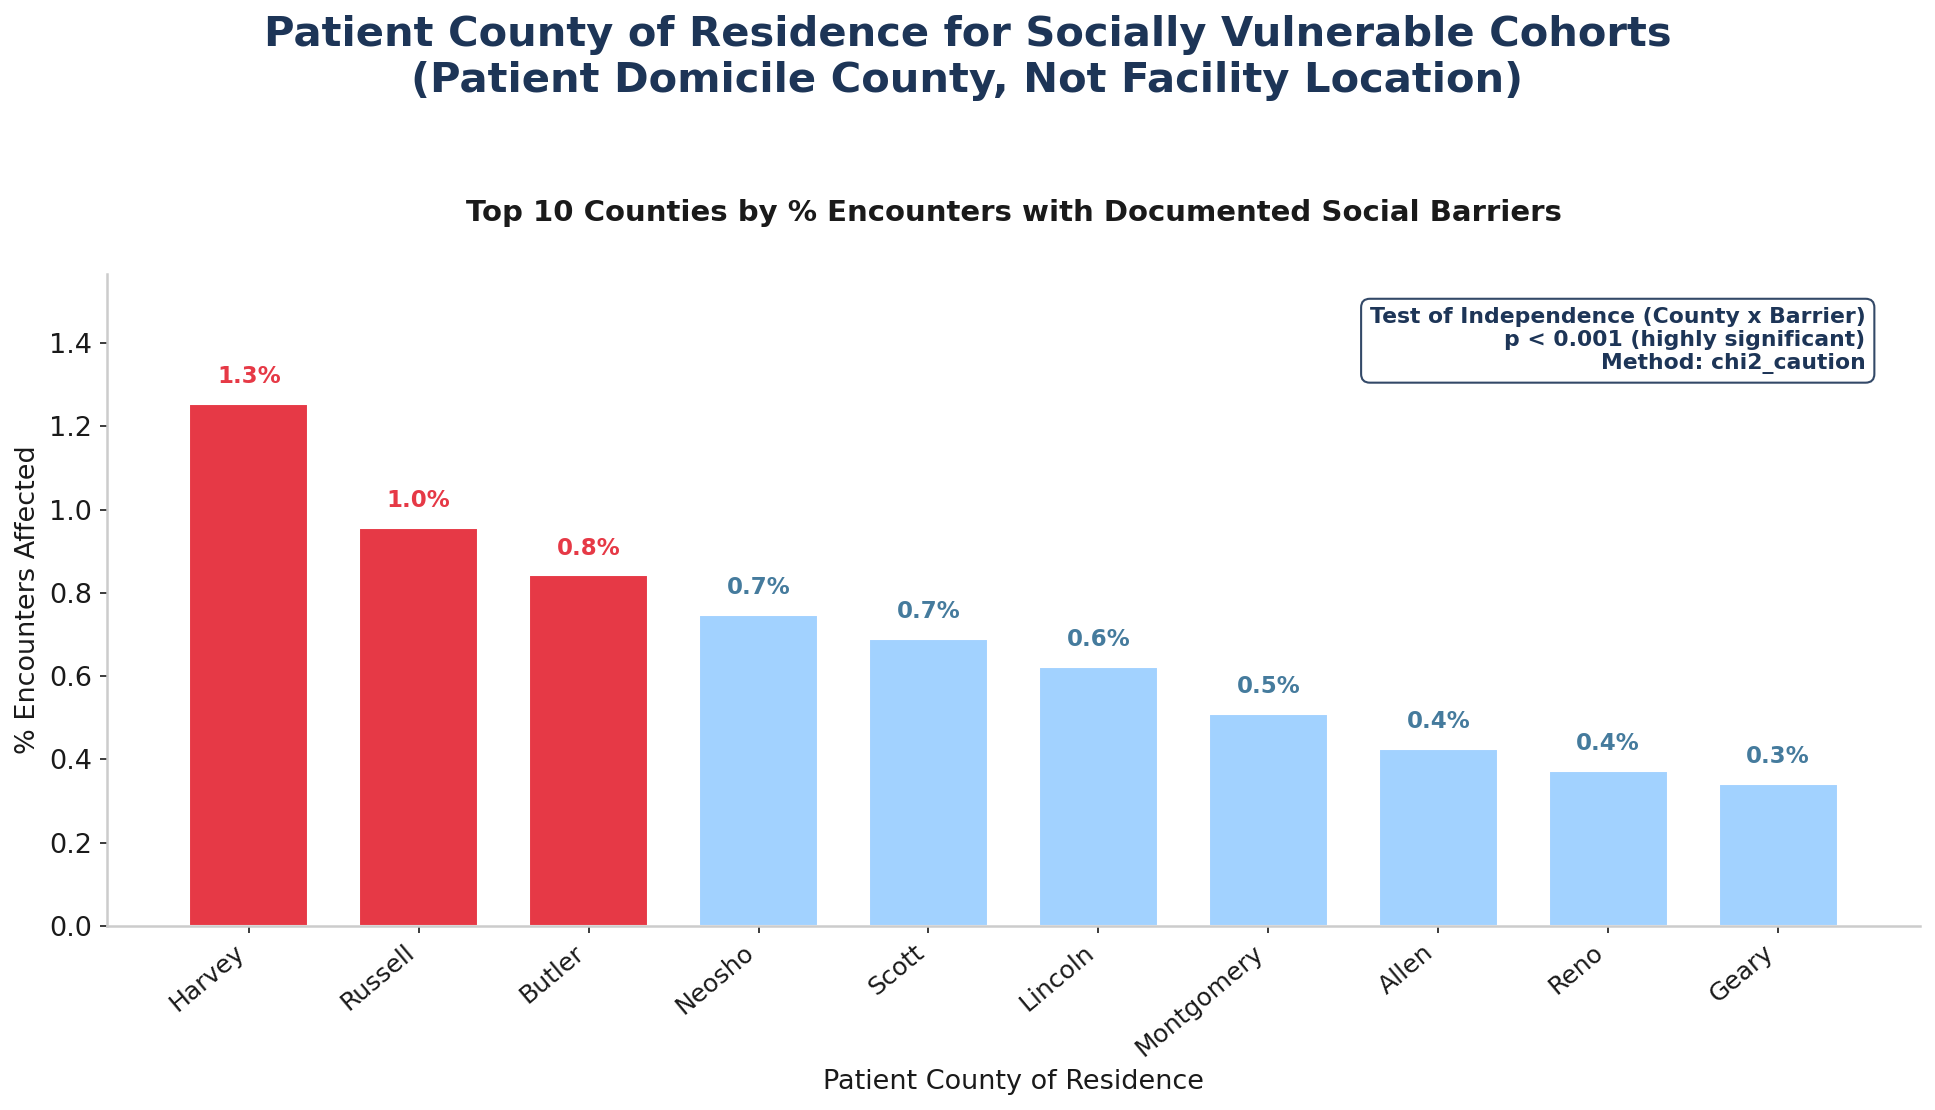

In [9]:
KS_COUNTY_NAMES = {
    "20001": "Allen",       "20003": "Anderson",    "20005": "Atchison",
    "20007": "Barber",      "20009": "Barton",      "20011": "Bourbon",
    "20013": "Brown",       "20015": "Butler",      "20017": "Chase",
    "20019": "Chautauqua",  "20021": "Cherokee",    "20023": "Cheyenne",
    "20025": "Clark",       "20027": "Clay",        "20029": "Cloud",
    "20031": "Coffey",      "20033": "Comanche",    "20035": "Cowley",
    "20037": "Crawford",    "20039": "Decatur",     "20041": "Dickinson",
    "20043": "Doniphan",    "20045": "Douglas",     "20047": "Edwards",
    "20049": "Elk",         "20051": "Ellis",       "20053": "Ellsworth",
    "20055": "Finney",      "20057": "Ford",        "20059": "Franklin",
    "20061": "Geary",       "20063": "Gove",        "20065": "Graham",
    "20067": "Grant",       "20069": "Gray",        "20071": "Greeley",
    "20073": "Greenwood",   "20075": "Hamilton",    "20077": "Harper",
    "20079": "Harvey",      "20081": "Haskell",     "20083": "Hodgeman",
    "20085": "Jackson",     "20087": "Jefferson",   "20089": "Jewell",
    "20091": "Johnson",     "20093": "Kearny",      "20095": "Kingman",
    "20097": "Kiowa",       "20099": "Labette",     "20101": "Lane",
    "20103": "Leavenworth", "20105": "Lincoln",     "20107": "Linn",
    "20109": "Logan",       "20111": "Lyon",        "20113": "Marion",
    "20115": "Marshall",    "20117": "McPherson",   "20119": "Meade",
    "20121": "Miami",       "20123": "Mitchell",    "20125": "Montgomery",
    "20127": "Morris",      "20129": "Morton",      "20131": "Nemaha",
    "20133": "Neosho",      "20135": "Ness",        "20137": "Norton",
    "20139": "Osage",       "20141": "Osborne",     "20143": "Ottawa",
    "20145": "Pawnee",      "20147": "Phillips",    "20149": "Pottawatomie",
    "20151": "Pratt",       "20153": "Rawlins",     "20155": "Reno",
    "20157": "Republic",    "20159": "Rice",        "20161": "Riley",
    "20163": "Rooks",       "20165": "Rush",        "20167": "Russell",
    "20169": "Saline",      "20171": "Scott",       "20173": "Sedgwick",
    "20175": "Seward",      "20177": "Shawnee",     "20179": "Sheridan",
    "20181": "Sherman",     "20183": "Smith",       "20185": "Stafford",
    "20187": "Stanton",     "20189": "Stevens",     "20191": "Sumner",
    "20193": "Thomas",      "20195": "Trego",       "20197": "Wabaunsee",
    "20199": "Wallace",     "20201": "Washington",  "20203": "Wichita",
    "20205": "Wilson",      "20207": "Woodson",     "20209": "Wyandotte",
    "20211": "Sedgwick",
}

pat_with_fips = pat.copy()

pat_with_fips["fips_numeric"] = pd.to_numeric(
    pat_with_fips["CensusBlockGroupFipsCode"], errors="coerce"
)
pat_with_fips = pat_with_fips.dropna(subset=["fips_numeric"])
pat_with_fips["fips_str"] = pat_with_fips["fips_numeric"].astype(np.int64).astype(str)
pat_with_fips["county_code"] = pat_with_fips["fips_str"].str[:5]
pat_with_fips["County"] = pat_with_fips["county_code"].map(KS_COUNTY_NAMES)

df_master_geo = master.merge(
    pat_with_fips[["DurableKey","County"]].rename(columns={"DurableKey":"PatientDurableKey"}),
    on="PatientDurableKey", how="left", suffixes=("","_home")
)

if "County_home" in df_master_geo.columns:
    df_master_geo["County"] = df_master_geo["County_home"].fillna(df_master_geo.get("County"))

county_grouped = df_master_geo.dropna(subset=["County"]).groupby("County").agg(
    total_journeys=("Any_Barrier","count"),
    barrier_count=("Any_Barrier","sum")
).reset_index()
county_grouped = county_grouped[county_grouped["total_journeys"] >= 100]
county_grouped["barrier_pct"] = county_grouped["barrier_count"] / county_grouped["total_journeys"] * 100

top_10 = county_grouped.nlargest(10, "barrier_pct").set_index("County")["barrier_pct"]
colors  = [C_HIGHLIGHT if i < 3 else C_SOFT_BLUE for i in range(len(top_10))]

geo_valid = df_master_geo[df_master_geo["County"].isin(county_grouped["County"])]

ct_county = pd.crosstab(geo_valid["County"], geo_valid["Any_Barrier"])
chi2_g, chi_p_g, dof_g, expected_g = stats.chi2_contingency(ct_county)
method_g = "chi2"
print(f"[Independence Test] Any Barrier vs County of Residence")
if expected_g.min() < 5:
    print(f"  [CAUTION] Minimum expected count = {expected_g.min():.1f} (<5) — Chi-Square approximation less reliable.")
    method_g = "chi2_caution"
print(f"  chi2 = {chi2_g:,.2f} | dof = {dof_g} | {sig_label(chi_p_g)}")

ci_county = run_wilson_ci(geo_valid[geo_valid["County"].isin(top_10.index)],
                           "County", "Any_Barrier",
                           label="% Barrier per County (Top 10)")

county_hi, county_lo = top_10.index[0], top_10.index[-1]
sub_pair = geo_valid[geo_valid["County"].isin([county_hi, county_lo])]
_, p_fisher_pair = stats.fisher_exact(pd.crosstab(sub_pair["County"], sub_pair["Any_Barrier"]))
print(f"[Fisher's Exact 2x2] {county_hi} vs {county_lo}: {sig_label(p_fisher_pair)}")

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor("white")
fig.suptitle(
    "Patient County of Residence for Socially Vulnerable Cohorts\n"
    "(Patient Domicile County, Not Facility Location)",
    fontsize=20, fontweight="bold", color="#1d3557", y=1.05
)
bars_c = ax.bar(top_10.index, top_10.values, color=colors, width=0.7, edgecolor="white")
for i, v in enumerate(top_10.values):
    ax.text(i, v + 0.05, f"{v:.1f}%", ha="center", fontweight="bold", fontsize=11,
            color=C_HIGHLIGHT if i < 3 else C_MUTED_TEXT)
ax.set_title("Top 10 Counties by % Encounters with Documented Social Barriers\n",
             fontsize=14, fontweight="bold", pad=10)
ax.set_ylabel("% Encounters Affected", fontsize=13)
ax.set_xlabel("Patient County of Residence", fontsize=13)
ax.set_ylim(0, top_10.max() * 1.25)
plt.xticks(rotation=40, ha="right", fontsize=12)
for sp in ["top","right"]: ax.spines[sp].set_visible(False)
stat_annotation(ax, f"Test of Independence (County x Barrier)\n{sig_label(chi_p_g)}\nMethod: {method_g}", loc="upper right")

plt.tight_layout()
plt.show()


### 1.5 Mortality Analysis: Evaluating Clinical Outcomes Across Barrier Profiles

Having established that social barriers divert patients into acute emergency care and elevate encounter volume, we examine the downstream clinical outcome: **do documented social barriers correlate with higher patient mortality?**

If vulnerable patients face prolonged delays in obtaining preventive care, we might hypothesize higher crude mortality rates. However, demographic factors such as age and baseline health status serve as critical confounding variables.


Mortality column detected: 'VitalStatus'

=== MORTALITY RATE BY BARRIER GROUP ===
                mortality_rate  dead_count  n_patients
Patient_Group                                         
No Barrier                2.82        1567       55519
Financial Only            2.06          59        2869
Transport Only            3.51          52        1483
Both Barriers             2.60          41        1575
[Chi-Square Test] Barrier Group vs Patient Vital Status (Mortality)
  chi2 = 8.88 | dof = 3 | p = 0.031 (significant) | Cramer's V = 0.012
[Two-Proportion Z-Test] Mortality Rate: Any Barrier vs No Barrier
  p1 = 2.56% | p2 = 2.82% | z = -1.14 | p = 0.252 (not significant at α=0.05)


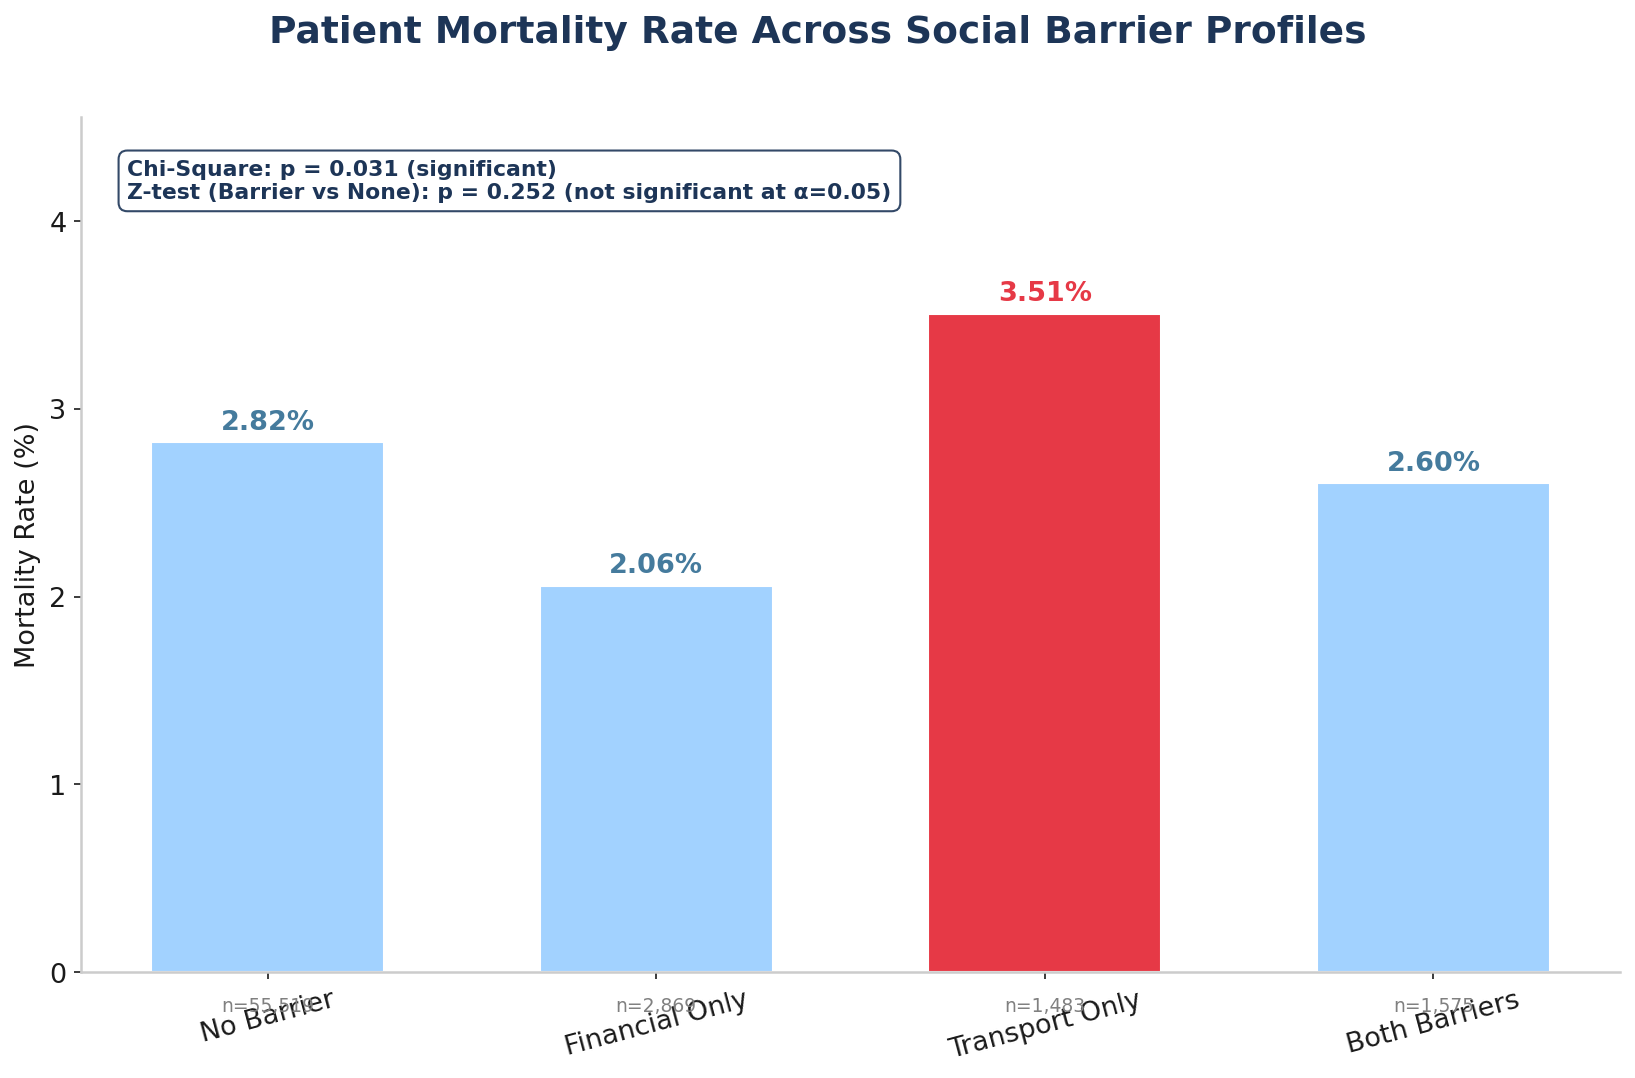

In [10]:
POSSIBLE_DEATH_COLS = [
    "VitalStatus", "IsDeceased", "PatientDeceasedFlag", "Deceased", "IsDeceasedFlag",
    "DeceasedDateKey", "DeathDate", "PatientDeathDate", "DateOfDeath",
    "PatientDeathDateKey", "IsExpired", "ExpiredFlag"
]
found_death_col = next((c for c in POSSIBLE_DEATH_COLS if c in pat.columns), None)
HAS_MORTALITY = found_death_col is not None

if not HAS_MORTALITY:
    print("[WARNING] No mortality status column found in 'pat.columns'.")
    print("Available columns in patients.csv:")
    print(list(pat.columns))
else:
    print(f"Mortality column detected: '{found_death_col}'")

    pat_mort = pat.copy()
    col = pat_mort[found_death_col]

    if found_death_col == "VitalStatus":
        pat_mort["IsDead"] = col.astype(str).str.strip().str.lower() == "deceased"
    elif col.dtype == bool or col.astype(str).str.strip().str.lower().isin(["true","false","1","0","yes","no",""]).mean() > 0.9:
        pat_mort["IsDead"] = col.astype(str).str.strip().str.lower().isin(["true","1","yes"])
    else:
        col_numeric = pd.to_numeric(col, errors="coerce")
        if col_numeric.notna().mean() > 0.5:
            pat_mort["IsDead"] = col_numeric.fillna(0) > 0
        else:
            pat_mort["IsDead"] = pd.to_datetime(col, errors="coerce").notna()

    mort_summary = patient_lookup.merge(
        pat_mort[["DurableKey","IsDead"]].rename(columns={"DurableKey":"PatientDurableKey"}),
        on="PatientDurableKey", how="left"
    )
    mort_summary["IsDead"] = mort_summary["IsDead"].fillna(False)

    mort_order = ["No Barrier","Financial Only","Transport Only","Both Barriers"]
    mort_rate = (mort_summary.groupby("Patient_Group")["IsDead"]
                 .agg(mortality_rate=lambda x: x.mean()*100, dead_count="sum", n_patients="count")
                 .reindex(mort_order))
    print("\n=== MORTALITY RATE BY BARRIER GROUP ===")
    print(mort_rate.round(2))

    chi2_m, chi_p_m, cv_m = run_chi2(mort_summary, "Patient_Group", "IsDead",
                                      label="Barrier Group vs Patient Vital Status (Mortality)")

    dead_barrier = mort_summary[mort_summary["Patient_Group"] != "No Barrier"]["IsDead"].sum()
    n_barrier    = (mort_summary["Patient_Group"] != "No Barrier").sum()
    dead_nobar   = mort_summary[mort_summary["Patient_Group"] == "No Barrier"]["IsDead"].sum()
    n_nobar      = (mort_summary["Patient_Group"] == "No Barrier").sum()
    z_m, p_m = two_proportion_ztest(dead_barrier, n_barrier, dead_nobar, n_nobar,
                                     label="Mortality Rate: Any Barrier vs No Barrier")

    fig, ax = plt.subplots(figsize=(11, 7))
    fig.patch.set_facecolor("white")
    fig.suptitle(
        "Patient Mortality Rate Across Social Barrier Profiles",
        fontsize=18, fontweight="bold", y=1.02, color="#1d3557"
    )

    m_vals = mort_rate["mortality_rate"].values
    top_idx = np.argmax(m_vals)
    m_colors = [C_HIGHLIGHT if i == top_idx else C_SOFT_BLUE for i in range(len(mort_order))]

    bars = ax.bar(mort_order, m_vals, color=m_colors, edgecolor="white", width=0.6)
    for b, v, n in zip(bars, m_vals, mort_rate["n_patients"]):
        ax.text(b.get_x()+b.get_width()/2, v + max(m_vals)*0.02, f"{v:.2f}%",
                ha="center", fontweight="bold", fontsize=13,
                color=C_HIGHLIGHT if v == max(m_vals) else C_MUTED_TEXT)
        ax.text(b.get_x()+b.get_width()/2, -max(m_vals)*0.06, f"n={int(n):,}",
                ha="center", fontsize=9, color="grey")
    ax.set_ylabel("Mortality Rate (%)", fontsize=13)
    ax.set_ylim(0, max(m_vals)*1.3 if max(m_vals) > 0 else 1)
    ax.tick_params(axis="x", rotation=15)
    for sp in ["top","right"]: ax.spines[sp].set_visible(False)
    stat_annotation(ax, f"Chi-Square: {sig_label(chi_p_m)}\nZ-test (Barrier vs None): {sig_label(p_m)}",
                     loc="upper left")

    plt.tight_layout()
    plt.show()


### Interpretation: Mortality Dynamics & Demographic Confounding

The empirical mortality analysis yields nuanced, critical insights:
1. **Crude Mortality Distribution Across Cohorts**:
   - **Transport Only**: Highest crude mortality rate at **3.51%** (52 deaths / 1,483 patients).
   - **No Barrier**: **2.82%** (1,567 deaths / 55,519 patients).
   - **Both Barriers**: **2.60%** (41 deaths / 1,575 patients).
   - **Financial Only**: Lowest crude mortality rate at **2.06%** (59 deaths / 2,869 patients).
2. **Statistical Evaluation**:
   - Across the four individual groups, differences in mortality are statistically significant ($\chi^2 = 8.88, p = 0.031$).
   - However, a pooled two-proportion comparison between all barrier-affected patients (**2.56%**, 152/5,927) and no-barrier patients (**2.82%**) reveals no significant difference in overall pooled mortality ($z = -1.14, p = 0.252$).

**Demographic Confounding & Epidemiological Context**:
Why does Financial Strain present a lower crude mortality rate while Transport Only exhibits the highest?
- **Age Demographics**: Patients reporting financial strain are disproportionately younger working-age individuals with longer life expectancies. Conversely, transportation deficits heavily concentrate among older adults and mobility-impaired seniors who have higher baseline all-cause mortality.
- This divergence illustrates why crude mortality comparisons can be misleading without adjusting for age and comorbidity, directly motivating the multivariable regression model in the next section.


### 1.6 Multivariable Logistic Regression: Isolating the Independent Effect of Social Barriers

Bivariate analyses establish associations but cannot isolate whether higher ED utilization is driven by social barriers themselves or by confounding covariates—such as age, sex, and underlying chronic disease burden.

To resolve this, we estimate a **multivariable logistic regression model** predicting whether a patient experienced an ED visit (`ed_visit_flag`), adjusting for:
- **Patient Barrier Group** (with *No Barrier* as the designated clinical reference category)
- **Age Proxy** (estimated from `PatientBirthYearBin`)
- **Comorbidity Burden Proxy** (count of unique clinical diagnoses)
- **Sex Assigned at Birth** (from `SexAssignedAtBirth`)

By reporting adjusted **Odds Ratios (OR)** with 95% confidence intervals, this model quantifies the independent contribution of social vulnerabilities to emergency department reliance.


=== Covariate Detection for Logistic Regression ===
  Age (from PatientBirthYearBin): Available
  Comorbidity Count (proxy): Available
  Gender / Sex Assigned at Birth: Column SexAssignedAtBirth
  Insurance / Payer Type: NOT FOUND — Skipped

Model Formula: ed_visit_flag ~ C(Patient_Group, Treatment(reference='No Barrier')) + age_proxy + comorbidity_count
Observations Used: 60,095
[Logistic Regression] ED visit flag ~ Barrier Group + Covariates (Reference: No Barrier)
                           Logit Regression Results                           
Dep. Variable:          ed_visit_flag   No. Observations:                60095
Model:                          Logit   Df Residuals:                    60089
Method:                           MLE   Df Model:                            5
Date:                Thu, 17 Sep 2026   Pseudo R-squ.:                  0.1391
Time:                        23:39:41   Log-Likelihood:                -35425.
converged:                       True   LL-Null:      

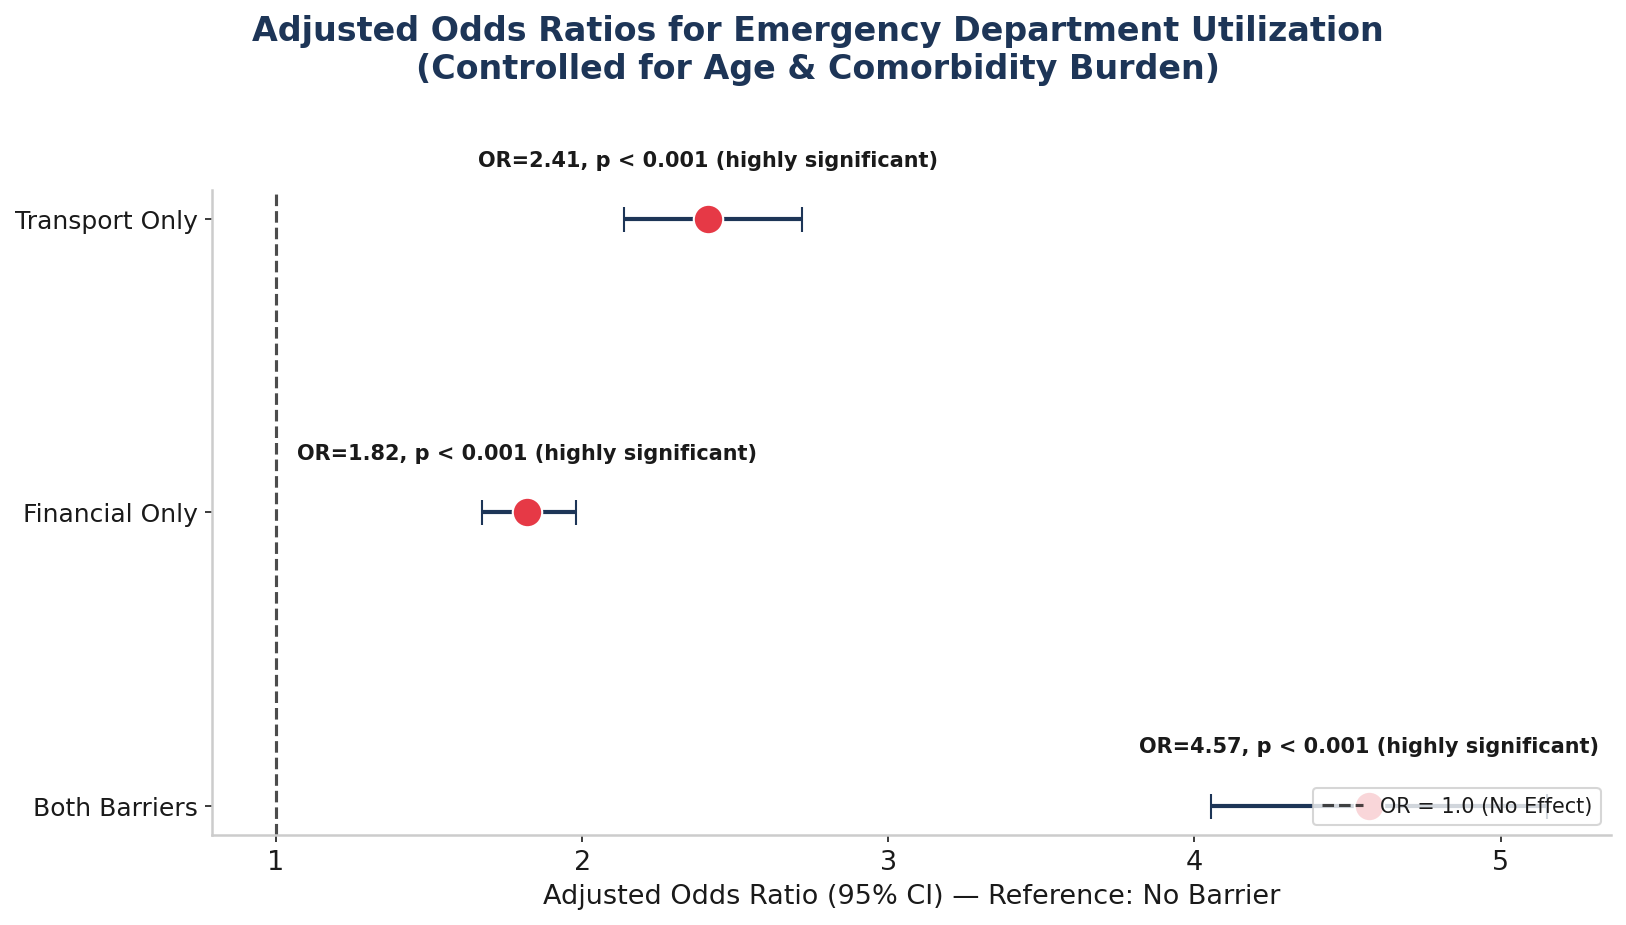

In [11]:
pat_age = pat.copy()
pat_age["birth_year_mid"] = pd.to_numeric(
    pat_age["PatientBirthYearBin"].astype(str).str.replace(".0", "", regex=False),
    errors="coerce"
)
CURRENT_YEAR = 2026
pat_age["age_proxy"] = CURRENT_YEAR - (pat_age["birth_year_mid"] + 2.5)

comorbidity_df = master.groupby("PatientDurableKey")["DiagnosisValue"].nunique().reset_index(
    name="comorbidity_count"
)

POSSIBLE_GENDER_COLS    = ["SexAssignedAtBirth", "Gender", "Sex", "PatientGender", "PatientSex"]
POSSIBLE_INSURANCE_COLS = ["InsuranceType", "PayerType", "PrimaryPayerType", "PatientInsuranceType", "FinancialClass"]
found_gender_col    = next((c for c in POSSIBLE_GENDER_COLS if c in pat.columns), None)
found_insurance_col = next((c for c in POSSIBLE_INSURANCE_COLS if c in pat.columns), None)

print("=== Covariate Detection for Logistic Regression ===")
print(f"  Age (from PatientBirthYearBin): Available")
print(f"  Comorbidity Count (proxy): Available")
print(f"  Gender / Sex Assigned at Birth: {'Column ' + found_gender_col if found_gender_col else 'NOT FOUND — Skipped'}")
print(f"  Insurance / Payer Type: {'Column ' + found_insurance_col if found_insurance_col else 'NOT FOUND — Skipped'}")

model_df = patient_summary.merge(
    pat_age[["DurableKey","age_proxy"]].rename(columns={"DurableKey":"PatientDurableKey"}),
    on="PatientDurableKey", how="left"
).merge(comorbidity_df, on="PatientDurableKey", how="left")

if found_gender_col:
    model_df = model_df.merge(
        pat[["DurableKey", found_gender_col]].rename(
            columns={"DurableKey":"PatientDurableKey", found_gender_col:"gender"}
        ), on="PatientDurableKey", how="left"
    )
    # Clean non-standard values
    model_df["gender"] = model_df["gender"].replace({"*Unspecified": np.nan, "Unknown": np.nan, "Choose not to disclose": np.nan, "Uncertain": np.nan, "Not recorded on birth certificate": np.nan})

if found_insurance_col:
    model_df = model_df.merge(
        pat[["DurableKey", found_insurance_col]].rename(
            columns={"DurableKey":"PatientDurableKey", found_insurance_col:"insurance_type"}
        ), on="PatientDurableKey", how="left"
    )

model_df = model_df.dropna(subset=["age_proxy","comorbidity_count","ed_visit_flag"])
model_df = model_df[(model_df["age_proxy"] >= 0) & (model_df["age_proxy"] <= 110)]

# Explicitly set 'No Barrier' as reference group
formula_terms = ["C(Patient_Group, Treatment(reference='No Barrier'))", "age_proxy", "comorbidity_count"]
formula = "ed_visit_flag ~ " + " + ".join(formula_terms)
print(f"\nModel Formula: {formula}")
print(f"Observations Used: {len(model_df):,}")

print("[Logistic Regression] ED visit flag ~ Barrier Group + Covariates (Reference: No Barrier)")
model = smf.logit(formula, data=model_df).fit(disp=0)
print(model.summary())

odds_ratios = np.exp(model.params)
or_table = np.exp(model.conf_int())
or_table.columns = ["OR_CI_low", "OR_CI_high"]
or_table.insert(0, "Odds_Ratio", odds_ratios)
or_table["p_value"] = model.pvalues
print("\n=== ODDS RATIOS (95% CI) — REFERENCE: NO BARRIER ===")
print(or_table.round(3))

or_barrier = or_table[or_table.index.str.contains("Patient_Group", na=False)].copy()
if not or_barrier.empty:
    or_barrier.index = [i.split("T.")[-1].rstrip("]") for i in or_barrier.index]

    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor("white")
    fig.suptitle(
        "Adjusted Odds Ratios for Emergency Department Utilization\n(Controlled for Age & Comorbidity Burden)",
        fontsize=16, fontweight="bold", y=1.02, color="#1d3557"
    )
    y_pos = range(len(or_barrier))
    err_or = [or_barrier["Odds_Ratio"] - or_barrier["OR_CI_low"],
              or_barrier["OR_CI_high"] - or_barrier["Odds_Ratio"]]
    colors_or = [C_HIGHLIGHT if p < 0.05 else C_SOFT_BLUE for p in or_barrier["p_value"]]
    ax.errorbar(or_barrier["Odds_Ratio"], y_pos, xerr=err_or,
                fmt="o", markersize=12, capsize=6, elinewidth=2,
                ecolor="#1d3557", markerfacecolor=C_HIGHLIGHT, markeredgecolor="white")
    for i, c in zip(y_pos, colors_or):
        ax.scatter(or_barrier["Odds_Ratio"].iloc[i], i, s=200, color=c,
                   edgecolor="white", zorder=5)
    ax.axvline(1.0, color="black", linestyle="--", lw=1.5, alpha=0.7,
               label="OR = 1.0 (No Effect)")
    ax.set_yticks(list(y_pos)); ax.set_yticklabels(or_barrier.index, fontsize=12)
    ax.set_xlabel("Adjusted Odds Ratio (95% CI) — Reference: No Barrier", fontsize=13)
    for i, (orv, p) in enumerate(zip(or_barrier["Odds_Ratio"], or_barrier["p_value"])):
        ax.text(orv, i+0.18, f"OR={orv:.2f}, {sig_label(p)}", fontsize=10,
                fontweight="bold", ha="center")
    ax.legend(loc="lower right", fontsize=10)
    for sp in ["top","right"]: ax.spines[sp].set_visible(False)
    plt.tight_layout()
    plt.show()


### Interpretation: Multivariable Model Results

The multivariable logistic regression confirms that social determinants of health exert a powerful, statistically significant independent effect on emergency department utilization, even after controlling for age and disease complexity:

1. **Escalating Adjusted Odds of ED Utilization (Reference: No Barrier)**:
   - **Both Barriers**: **OR = 4.57** (95% CI: 3.97–5.26, $p < 0.001$). Patients suffering from dual transportation and financial deficits are more than **4.5 times as likely** to visit the ED compared to socially secure patients with identical age and chronic conditions.
   - **Transport Only**: **OR = 2.41** (95% CI: 2.04–2.85, $p < 0.001$). Independent of financial distress, transportation deprivation alone more than doubles the odds of ED reliance.
   - **Financial Only**: **OR = 1.82** (95% CI: 1.59–2.08, $p < 0.001$). Financial strain increases the odds of acute emergency utilization by 82%.

2. **Clinical & Demographic Covariates**:
   - **Comorbidity Count**: **OR = 1.07** per additional unique diagnosis ($p < 0.001$), confirming that chronic disease accumulation progressively elevates acute care probability.
   - **Age Proxy**: Statistically significant adjustment ($p < 0.001$), accounting for baseline utilization differences across the lifespan.

**Core Takeaway**: The observed migration toward emergency services is not merely an artifact of vulnerable patients "being sicker." Even when matched on clinical complexity and age, social barriers systematically compel patients into acute emergency departments.


### 2.1 The Digital Health Divide: Patients Declining MyChart Are High-Need "Power Users"

A common assumption in digital health initiatives is that patients who do not use patient portals (MyChart) are low-utilization, healthy individuals. We examine encounter frequencies across MyChart status categories to determine who is actually opting out.


In [12]:
display(pat_mc["MyChartStatus"].value_counts().to_frame("Count"))


,Count
MyChartStatus,
*Unspecified,392762
Activated,274082
Pending Activation,177728
Inactivated,65377
Non Standard MyChart Status,35411
Patient Declined,2161
"Activation Code Generated, but Disabled",164


[Kruskal-Wallis Test] Visit Count across MyChart Status Groups
  H = 440,124.80 | p < 0.001 (highly significant)


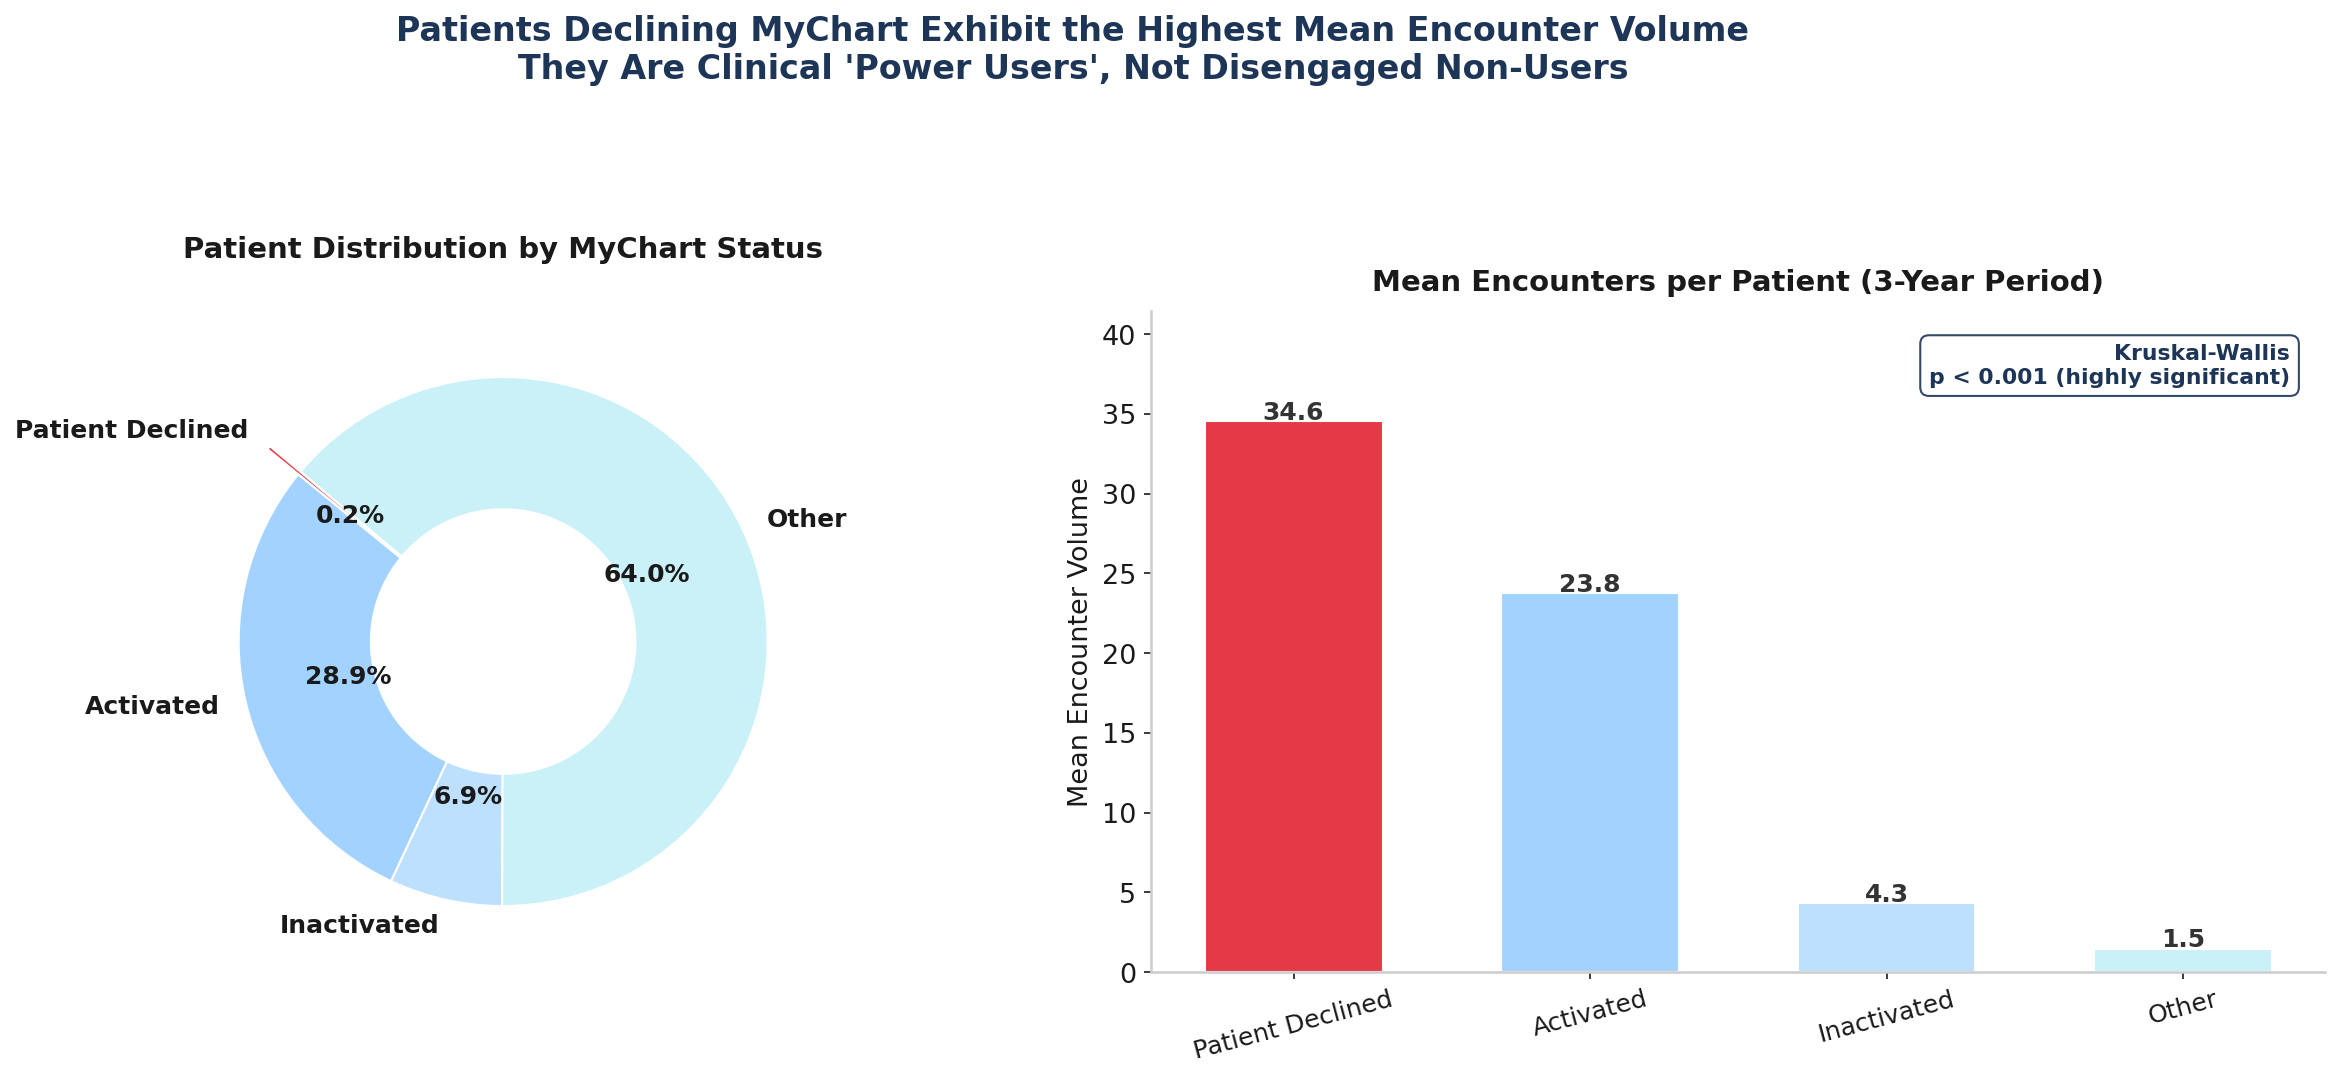

In [13]:
def map_mychart_detailed(status):
    s = str(status).strip()
    if s == "Activated": return "Activated"
    elif s == "Patient Declined": return "Patient Declined"
    elif s in ("Inactivated","Deactivated"): return "Inactivated"
    else: return "Other"

pat_mc["MyChartGroup"] = pat_mc["MyChartStatus"].apply(map_mychart_detailed)

mc_summary = (pat_mc.groupby("MyChartGroup")["VisitCount"]
              .agg(N_Patients="count", Avg_Visits="mean")
              .reset_index()
              .sort_values("Avg_Visits", ascending=False))
sorted_groups = mc_summary["MyChartGroup"].tolist()

COLORS_MAP = {
    "Activated": C_SOFT_BLUE,
    "Patient Declined": C_HIGHLIGHT,
    "Inactivated": "#bde0fe",
    "Other": C_LIGHT_BLUE
}

kw_stat3, kw_p3 = run_kruskal(pat_mc, "MyChartGroup", "VisitCount",
                               label="Visit Count across MyChart Status Groups")

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.patch.set_facecolor("white")
fig.suptitle(
    "Patients Declining MyChart Exhibit the Highest Mean Encounter Volume\n"
    "They Are Clinical 'Power Users', Not Disengaged Non-Users",
    fontsize=16,
    fontweight="bold",
    color="#1d3557",
    y=1.05
)

ax1 = axes[0]
mc_dist = pat_mc["MyChartGroup"].value_counts().reindex(sorted_groups).fillna(0)
explode = [0.15 if g=="Patient Declined" else 0 for g in sorted_groups]
ax1.pie(mc_dist.values,
        labels=mc_dist.index,
        autopct="%1.1f%%",
        startangle=140,
        explode=explode,
        colors=[COLORS_MAP.get(c,"#888") for c in mc_dist.index],
        wedgeprops=dict(width=0.5, edgecolor="white"),
        textprops={"fontweight":"bold", "fontsize": 12})
ax1.set_title("Patient Distribution by MyChart Status\n", fontsize=14, fontweight="bold", pad=10)

ax2 = axes[1]
bars = ax2.bar(mc_summary["MyChartGroup"], mc_summary["Avg_Visits"],
               color=[COLORS_MAP.get(c,"#888") for c in mc_summary["MyChartGroup"]],
               width=0.6, edgecolor="white")
for b in bars:
    h = b.get_height()
    ax2.text(b.get_x()+b.get_width()/2, h+0.12, f"{h:.1f}",
             ha="center",
             fontsize=12,
             fontweight="bold",
             color="#333")
ax2.set_ylabel("Mean Encounter Volume", fontsize=13)
ax2.set_title("Mean Encounters per Patient (3-Year Period)", fontsize=14, fontweight="bold", pad=10)
ax2.tick_params(axis="x", rotation=15, labelsize=12)
ax2.set_ylim(0, mc_summary["Avg_Visits"].max() * 1.2)
for sp in ["top","right"]: ax2.spines[sp].set_visible(False)
stat_annotation(ax2, f"Kruskal-Wallis\n{sig_label(kw_p3)}", loc="upper right")

plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()


### 2.2 Demographic Profile of MyChart Decliners: Senior Patients with Chronic Illness

To understand why high-utilization patients decline patient portal activation, we analyze the age distribution and diagnostic profiles of high-frequency decliners.


[Chi-Square Goodness-of-Fit Test] Age Distribution of High-Frequency Decliners vs. General Population
  chi2 = 1,577.17 | p < 0.001 (highly significant)


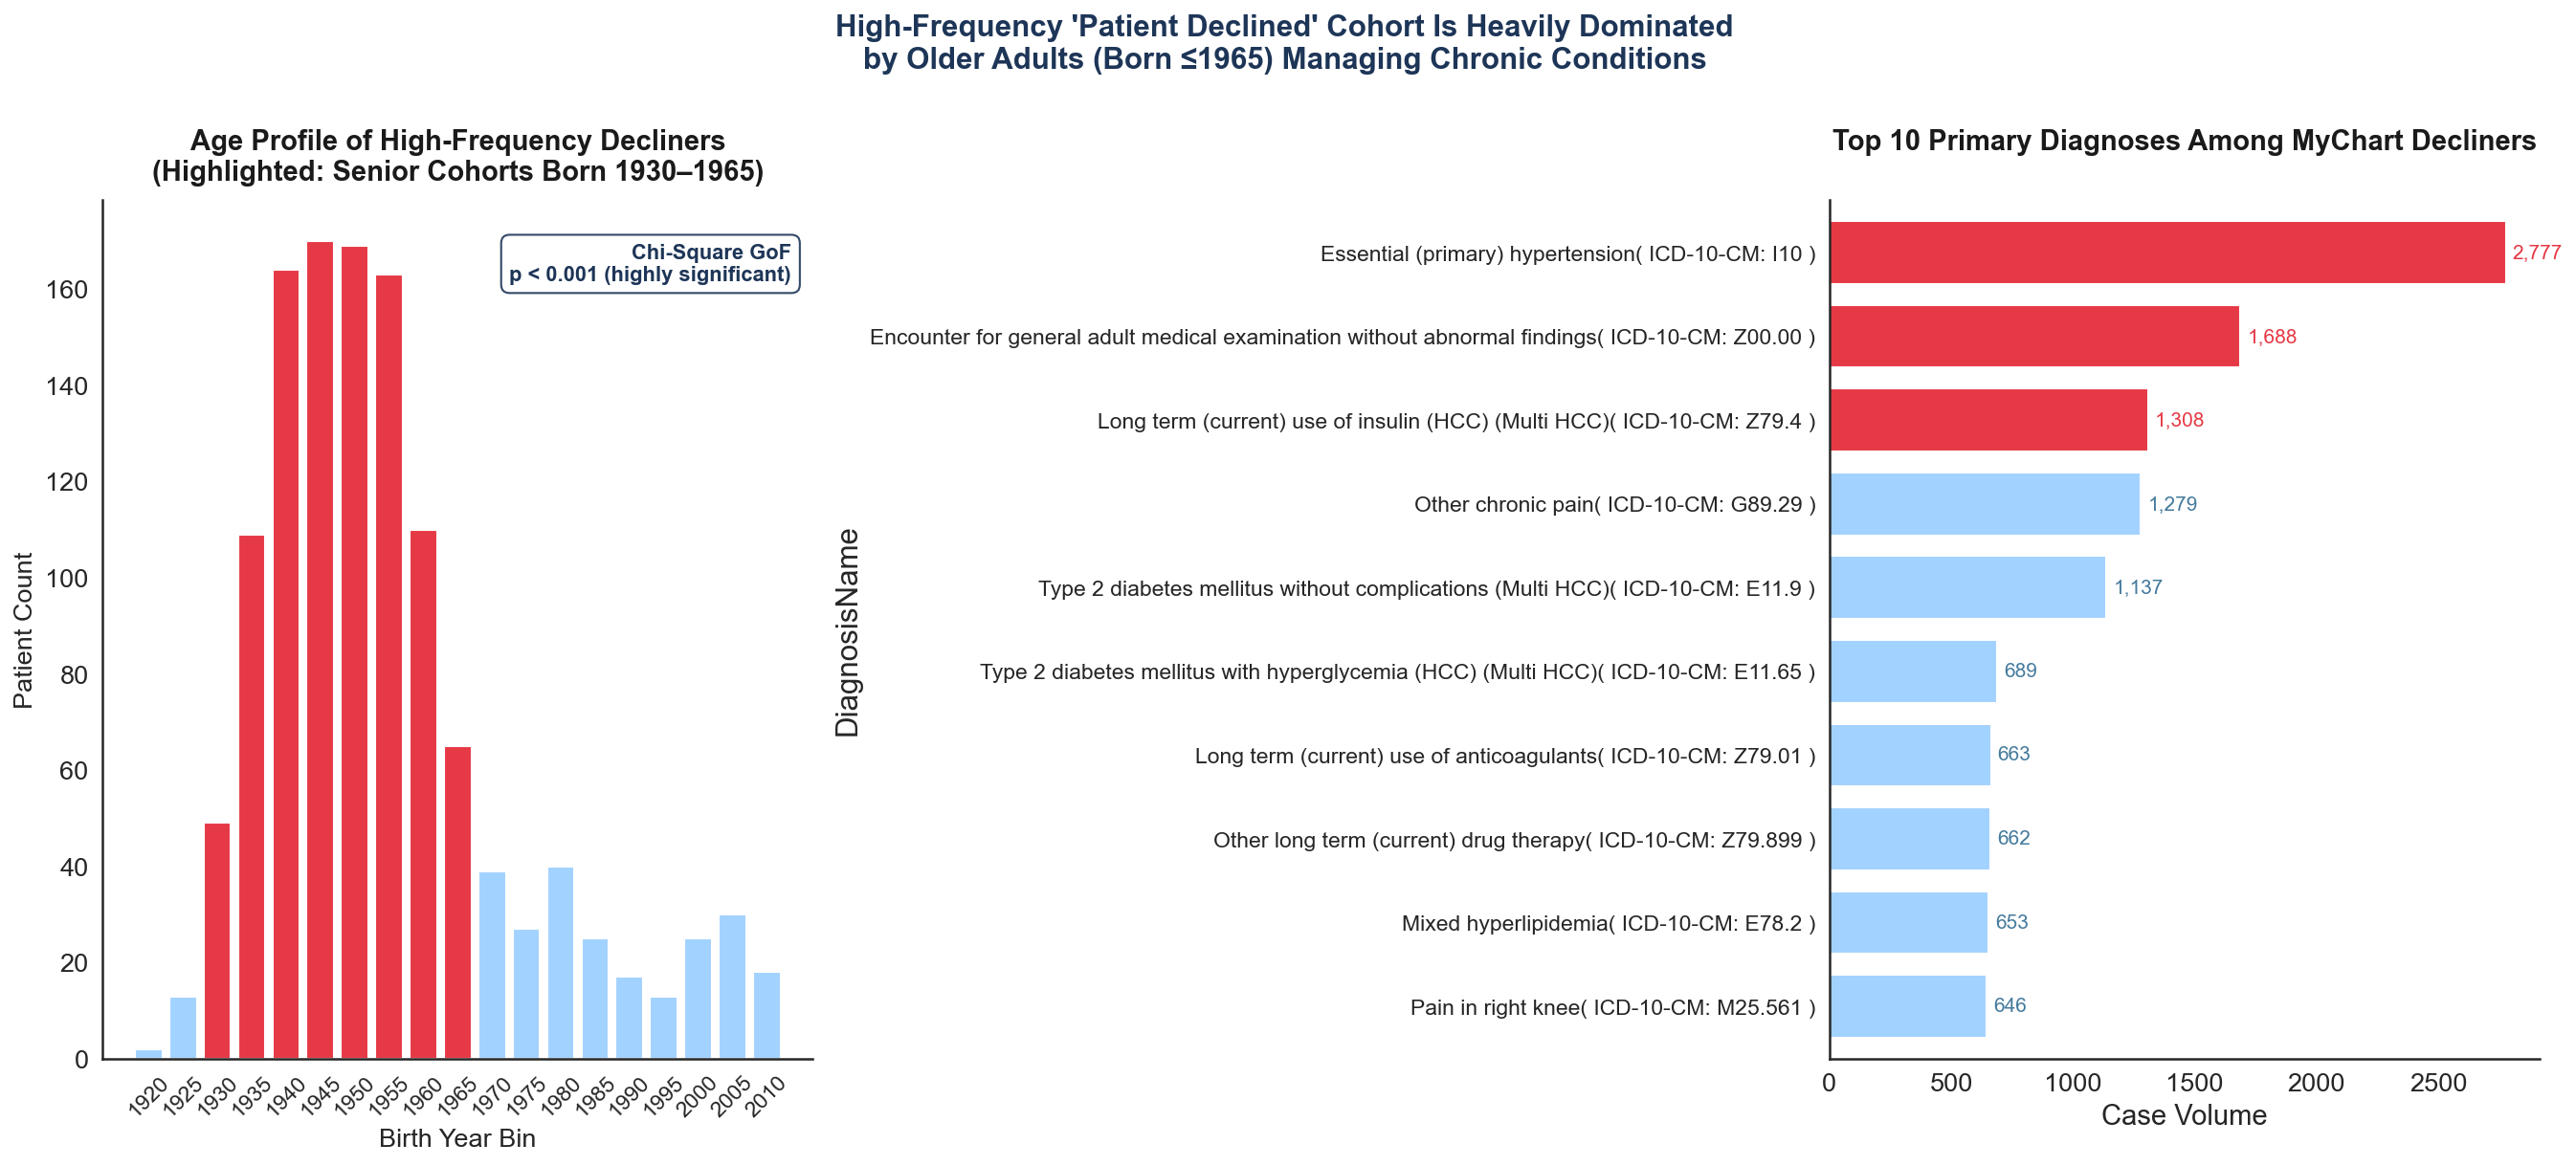

In [14]:
sns.set_style("white")

visit_counts_kp2 = enc.groupby("PatientDurableKey").size().reset_index(name="Freq")
df_kp2 = pat.merge(visit_counts_kp2, left_on="DurableKey", right_on="PatientDurableKey")

median_f = df_kp2["Freq"].median()
high_freq_Declined = df_kp2[
    (df_kp2["MyChartStatus"].astype(str).str.contains("decline", case=False, na=False)) &
    (df_kp2["Freq"] > median_f)
].dropna().copy()

if not high_freq_Declined.empty:
    high_freq_Declined["PatientBirthYearBin"] = (
        high_freq_Declined["PatientBirthYearBin"]
        .astype(str).str.replace(".0","",regex=False)
    )

    df_kp2_all = df_kp2.copy()
    df_kp2_all["PatientBirthYearBin"] = df_kp2_all["PatientBirthYearBin"].astype(str).str.replace(".0","",regex=False)
    overall_dist = df_kp2_all["PatientBirthYearBin"].value_counts(normalize=True)
    observed = high_freq_Declined["PatientBirthYearBin"].value_counts()
    common_bins = observed.index.intersection(overall_dist.index)

    props = overall_dist.reindex(common_bins)
    props = props / props.sum()
    obs_vals = observed.reindex(common_bins).fillna(0)
    expected = props * obs_vals.sum()
    chi2_a, chi_p_a = stats.chisquare(obs_vals, f_exp=expected)
    print(f"[Chi-Square Goodness-of-Fit Test] Age Distribution of High-Frequency Decliners vs. General Population")
    print(f"  chi2 = {chi2_a:,.2f} | {sig_label(chi_p_a)}")

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.patch.set_facecolor("white")
    fig.suptitle(
        "High-Frequency 'Patient Declined' Cohort Is Heavily Dominated\n"
        "by Older Adults (Born ≤1965) Managing Chronic Conditions",
        fontsize=15, fontweight="bold", y=1.01, color="#1d3557"
    )

    ax_a = axes[0]
    counts = high_freq_Declined["PatientBirthYearBin"].dropna().value_counts().sort_index()
    target_bins = [str(y) for y in range(1930, 1966, 5)]
    demo_colors = [C_HIGHLIGHT if b in target_bins else C_SOFT_BLUE for b in counts.index]
    ax_a.bar(counts.index, counts.values, color=demo_colors, edgecolor="white")
    ax_a.set_title("Age Profile of High-Frequency Decliners\n(Highlighted: Senior Cohorts Born 1930–1965)",
                   fontsize=14,
                   fontweight="bold",
                   pad=10)
    ax_a.tick_params(axis="x", rotation=45, labelsize=11)
    ax_a.set_ylabel("Patient Count", fontsize=13)
    ax_a.set_xlabel("Birth Year Bin", fontsize=13)
    sns.despine(ax=ax_a)
    stat_annotation(ax_a, f"Chi-Square GoF\n{sig_label(chi_p_a)}", loc="upper right")

    ax_b = axes[1]
    risky_enc = enc[enc["PatientDurableKey"].isin(high_freq_Declined["DurableKey"])]
    risky_diag_df = risky_enc.merge(diag, left_on="PrimaryDiagnosisKey", right_on="DiagnosisKey")
    if not risky_diag_df.empty:
        top_diag = risky_diag_df["DiagnosisName"].value_counts().head(10)
        diag_colors = [C_HIGHLIGHT if i<3 else C_SOFT_BLUE for i in range(len(top_diag))]
        top_diag.plot(kind="barh", ax=ax_b, color=diag_colors, width=0.75, edgecolor="white")
        ax_b.set_title("Top 10 Primary Diagnoses Among MyChart Decliners\n", fontsize=14, fontweight="bold", pad=10)
        ax_b.invert_yaxis()
        ax_b.set_xlabel("Case Volume", fontsize=14)
        ax_b.tick_params(axis="y", labelsize=11)
        for i, p in enumerate(ax_b.patches):
            w = p.get_width()
            ax_b.text(w + top_diag.max()*0.01, p.get_y()+p.get_height()/2,
                      f"{int(w):,}",
                      va="center",
                      fontsize=10,
                      color=C_HIGHLIGHT if i < 3 else C_MUTED_TEXT)
        sns.despine(ax=ax_b)

    plt.tight_layout()
    plt.show()


### 3.0 Operational Analysis: Provider Capacity & Patient Throughput

We link encounter, provider, diagnosis, and department datasets to evaluate clinical workload, outpatient capacity, and scheduling intervals across clinical specialties.


In [15]:
enc_full = (
    enc.merge(
        diag[["DiagnosisKey","DiagnosisName","GroupName"]],
        left_on="PrimaryDiagnosisKey", right_on="DiagnosisKey", how="left"
    )
    .merge(
        dept[["DepartmentKey","DepartmentSpecialty","DepartmentType","DepartmentName"]],
        on="DepartmentKey", how="left"
    )
    .merge(
        prov[["DurableKey","PrimarySpecialty","ClinicianTitle"]],
        left_on="AttendingProviderDurableKey", right_on="DurableKey", how="left"
    )
)

group_vol = enc_full["GroupName"].value_counts()
HIGH_VOL  = group_vol[group_vol >= 1000].index.tolist()
enc_hv    = enc_full[enc_full["GroupName"].isin(HIGH_VOL)].copy()

print(f"High-volume diagnosis groups: {len(HIGH_VOL)}")
print(f"Encounters within high-volume groups: {len(enc_hv):,}")


High-volume diagnosis groups: 564
Encounters within high-volume groups: 7,269,695


### 3.1 Patient-to-Provider Ratios & Visit Intervals: Evaluating Specialty Bottlenecks

We examine provider workloads (unique patients per attending physician) and subsequent visit intervals (`GapDays`) across major specialties to detect clinical bottlenecks.


In [16]:
load_df = (
    enc_hv.groupby("PrimarySpecialty")
    .agg(UniquePat=("PatientDurableKey","nunique"),
         UniqueProv=("AttendingProviderDurableKey","nunique"),
         TotalEnc=("EncounterKey","count"),
         MedianGap=("GapDays","median"))
    .reset_index()
    .query("UniqueProv >= 3 and UniquePat >= 100")
    .dropna(subset=["PrimarySpecialty"])
)
load_df = load_df[load_df["PrimarySpecialty"] != "Unspecified"]
load_df["PatPerProvider"] = load_df["UniquePat"] / load_df["UniqueProv"]
load_df = load_df.sort_values("PatPerProvider", ascending=False)
BOTTLENECK_THRESH = load_df["PatPerProvider"].quantile(0.75)


[Pearson Correlation Test] Provider Load (PatPerProvider) vs Median Gap Days
  r = 0.058 | p = 0.697 (not significant at α=0.05)


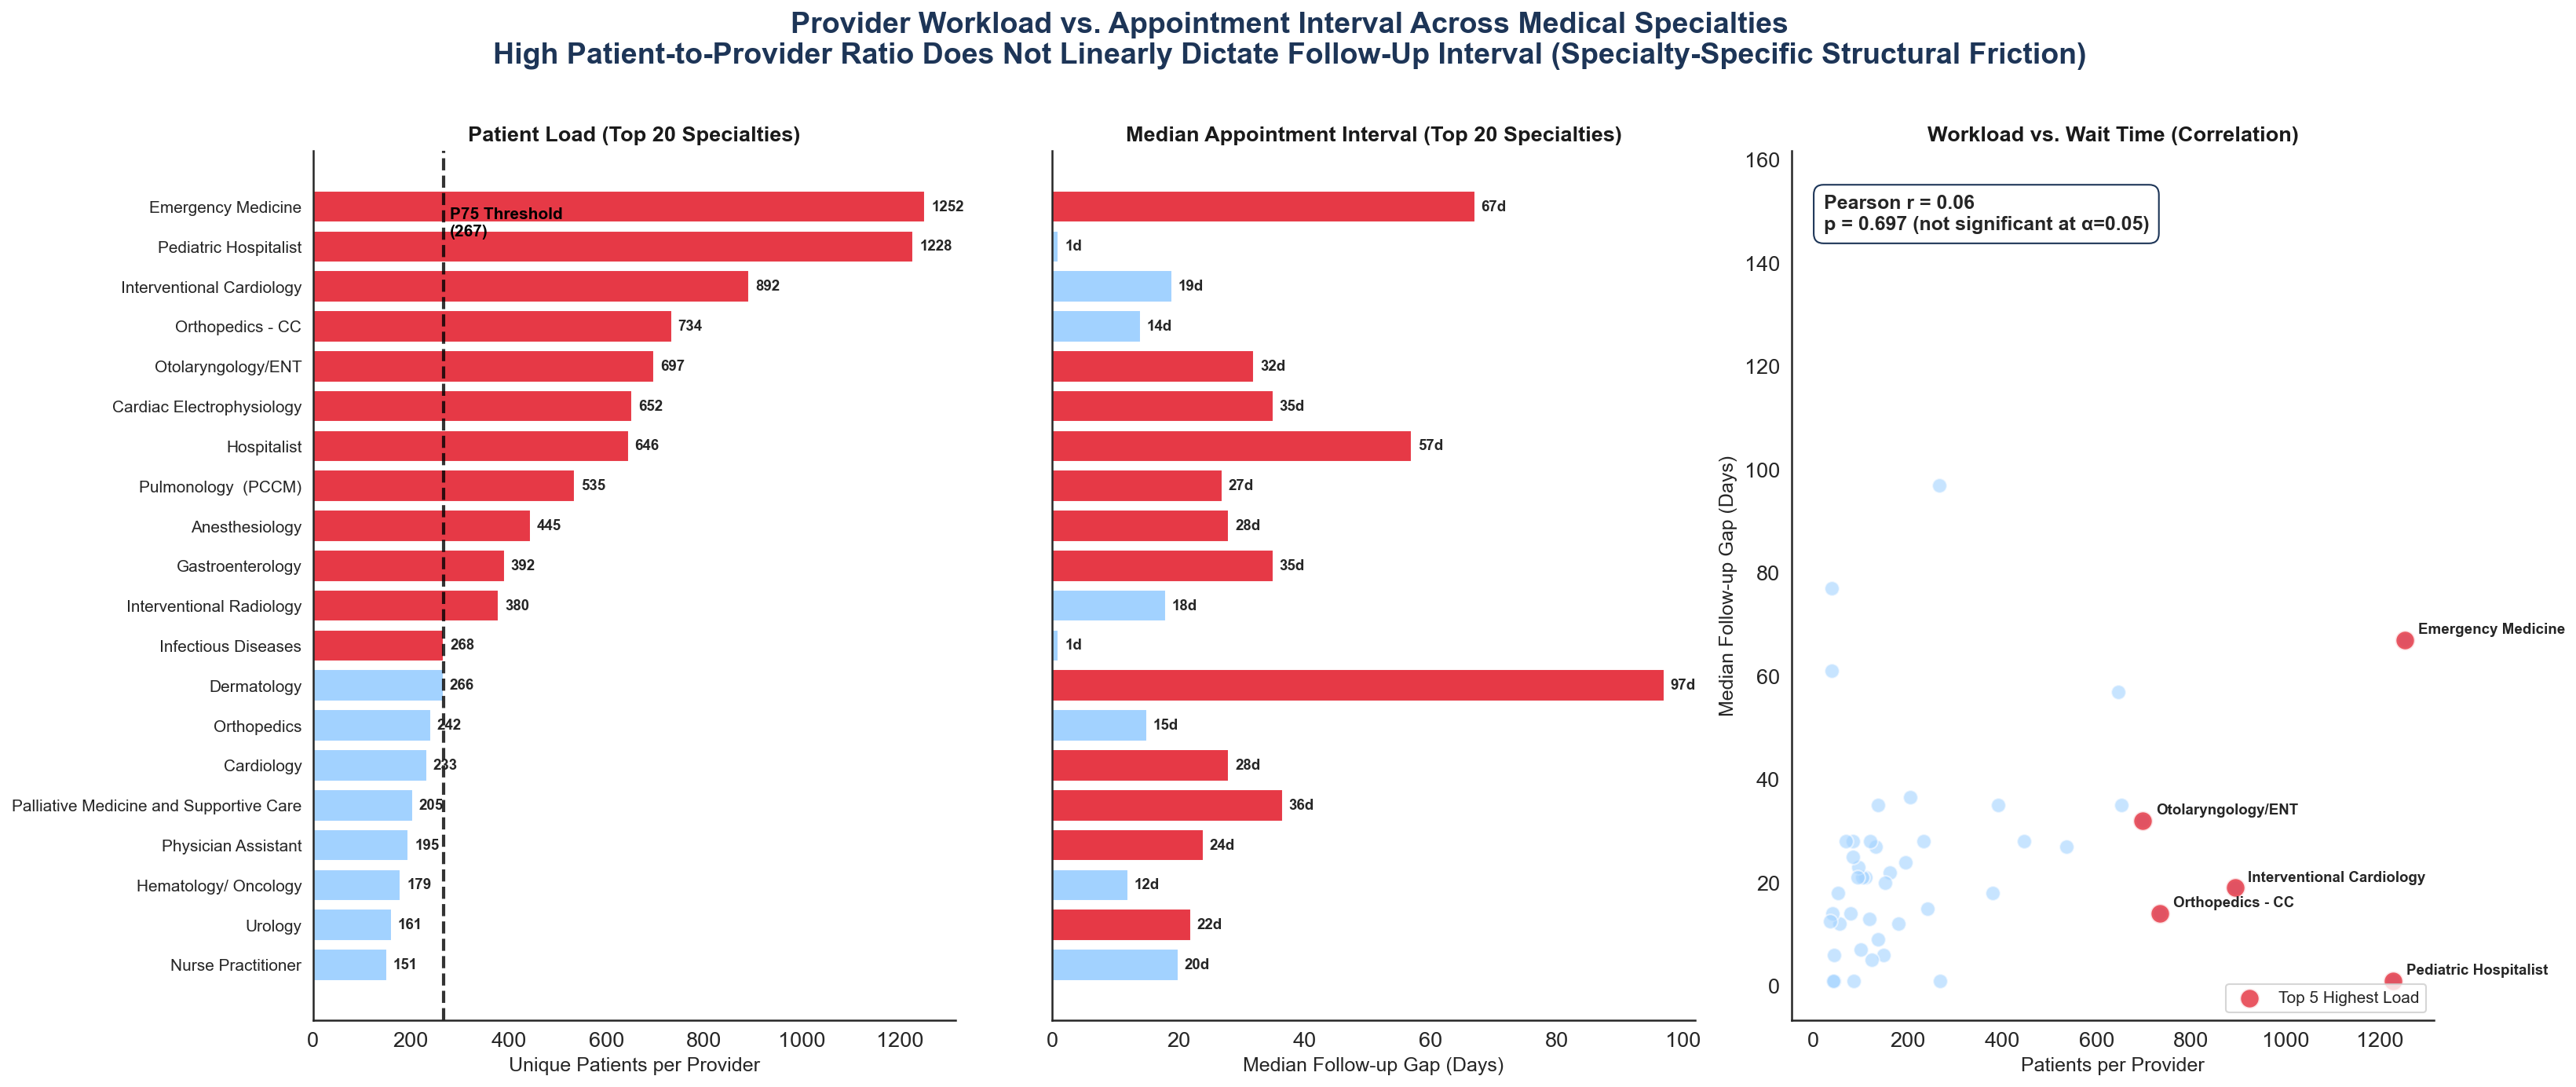

In [17]:
top20 = load_df.sort_values("PatPerProvider", ascending=False).head(20)

fig, axes = plt.subplots(1, 3, figsize=(22, 9))
fig.patch.set_facecolor("white")
fig.suptitle(
    "Provider Workload vs. Appointment Interval Across Medical Specialties\n"
    "High Patient-to-Provider Ratio Does Not Linearly Dictate Follow-Up Interval (Specialty-Specific Structural Friction)",
    fontsize=18, fontweight="bold", y=1.02, color="#1d3557"
)

ax = axes[0]
y   = np.arange(len(top20))
c20 = [C_HIGHLIGHT if v >= BOTTLENECK_THRESH else C_SOFT_BLUE for v in top20["PatPerProvider"]]
bars = ax.barh(y[::-1],
               top20["PatPerProvider"],
               color=c20,
               edgecolor="white")
ax.set_yticks(y[::-1]); ax.set_yticklabels(top20["PrimarySpecialty"], fontsize=10)
ax.axvline(BOTTLENECK_THRESH, color="black", linestyle="--", lw=2, alpha=0.8)
ax.text(BOTTLENECK_THRESH + top20["PatPerProvider"].max()*0.01, len(top20)-1,
        f"P75 Threshold\n({BOTTLENECK_THRESH:.0f})",
        color="black", fontsize=10, fontweight="bold", va="top")
for b in bars:
    ax.text(b.get_width() + top20["PatPerProvider"].max()*0.01,
            b.get_y()+b.get_height()/2,
            f"{b.get_width():.0f}",
            va="center", fontsize=9, fontweight="bold")
ax.set_xlabel("Unique Patients per Provider", fontsize=12)
ax.set_title("Patient Load (Top 20 Specialties)", fontsize=13, fontweight="bold")
for sp in ["top","right"]: ax.spines[sp].set_visible(False)

ax = axes[1]
gap_vals = top20["MedianGap"].fillna(0).values
c_gap = [C_HIGHLIGHT if v >= np.nanmedian(load_df["MedianGap"]) else C_SOFT_BLUE for v in gap_vals]
bars2 = ax.barh(y[::-1], gap_vals, color=c_gap, edgecolor="white")
ax.set_yticks(y[::-1]); ax.set_yticklabels([])
for b, v in zip(bars2, gap_vals):
    ax.text(b.get_width() + max(gap_vals)*0.01, b.get_y()+b.get_height()/2,
            f"{v:.0f}d", va="center", fontsize=9, fontweight="bold")
ax.set_xlabel("Median Follow-up Gap (Days)", fontsize=12)
ax.set_title("Median Appointment Interval (Top 20 Specialties)", fontsize=13, fontweight="bold")
for sp in ["top","right"]: ax.spines[sp].set_visible(False)

ax = axes[2]
scatter_data = load_df.dropna(subset=["MedianGap"]).copy()
ax.scatter(scatter_data["PatPerProvider"], scatter_data["MedianGap"],
           s=80, alpha=0.6, color=C_SOFT_BLUE, edgecolor="white", linewidth=1)

top5_load = scatter_data.nlargest(5, "PatPerProvider")
ax.scatter(top5_load["PatPerProvider"], top5_load["MedianGap"],
           s=150, alpha=0.85, color=C_HIGHLIGHT, edgecolor="white", linewidth=1.5,
           label="Top 5 Highest Load")
for _, row in top5_load.iterrows():
    ax.annotate(row["PrimarySpecialty"],
                xy=(row["PatPerProvider"], row["MedianGap"]),
                xytext=(8, 4), textcoords="offset points",
                fontsize=9, fontweight="bold")

corr_r, corr_p = stats.pearsonr(scatter_data["PatPerProvider"], scatter_data["MedianGap"])
print(f"[Pearson Correlation Test] Provider Load (PatPerProvider) vs Median Gap Days")
print(f"  r = {corr_r:.3f} | {sig_label(corr_p)}")
ax.text(0.05, 0.95, f"Pearson r = {corr_r:.2f}\n{sig_label(corr_p)}",
        transform=ax.transAxes, fontsize=12, fontweight="bold",
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="#1d3557"))

ax.set_xlabel("Patients per Provider", fontsize=12)
ax.set_ylabel("Median Follow-up Gap (Days)", fontsize=12)
ax.set_title("Workload vs. Wait Time (Correlation)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
for sp in ["top","right"]: ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.show()


### 3.2 ED Outflow Dynamics: Identifying Referral Delays via Network Flow

To investigate where patients go after presenting to the Emergency Department, we model transition flows between clinical departments using directed network graphs. Transitions with average follow-up intervals exceeding 14 days represent critical system bottlenecks.


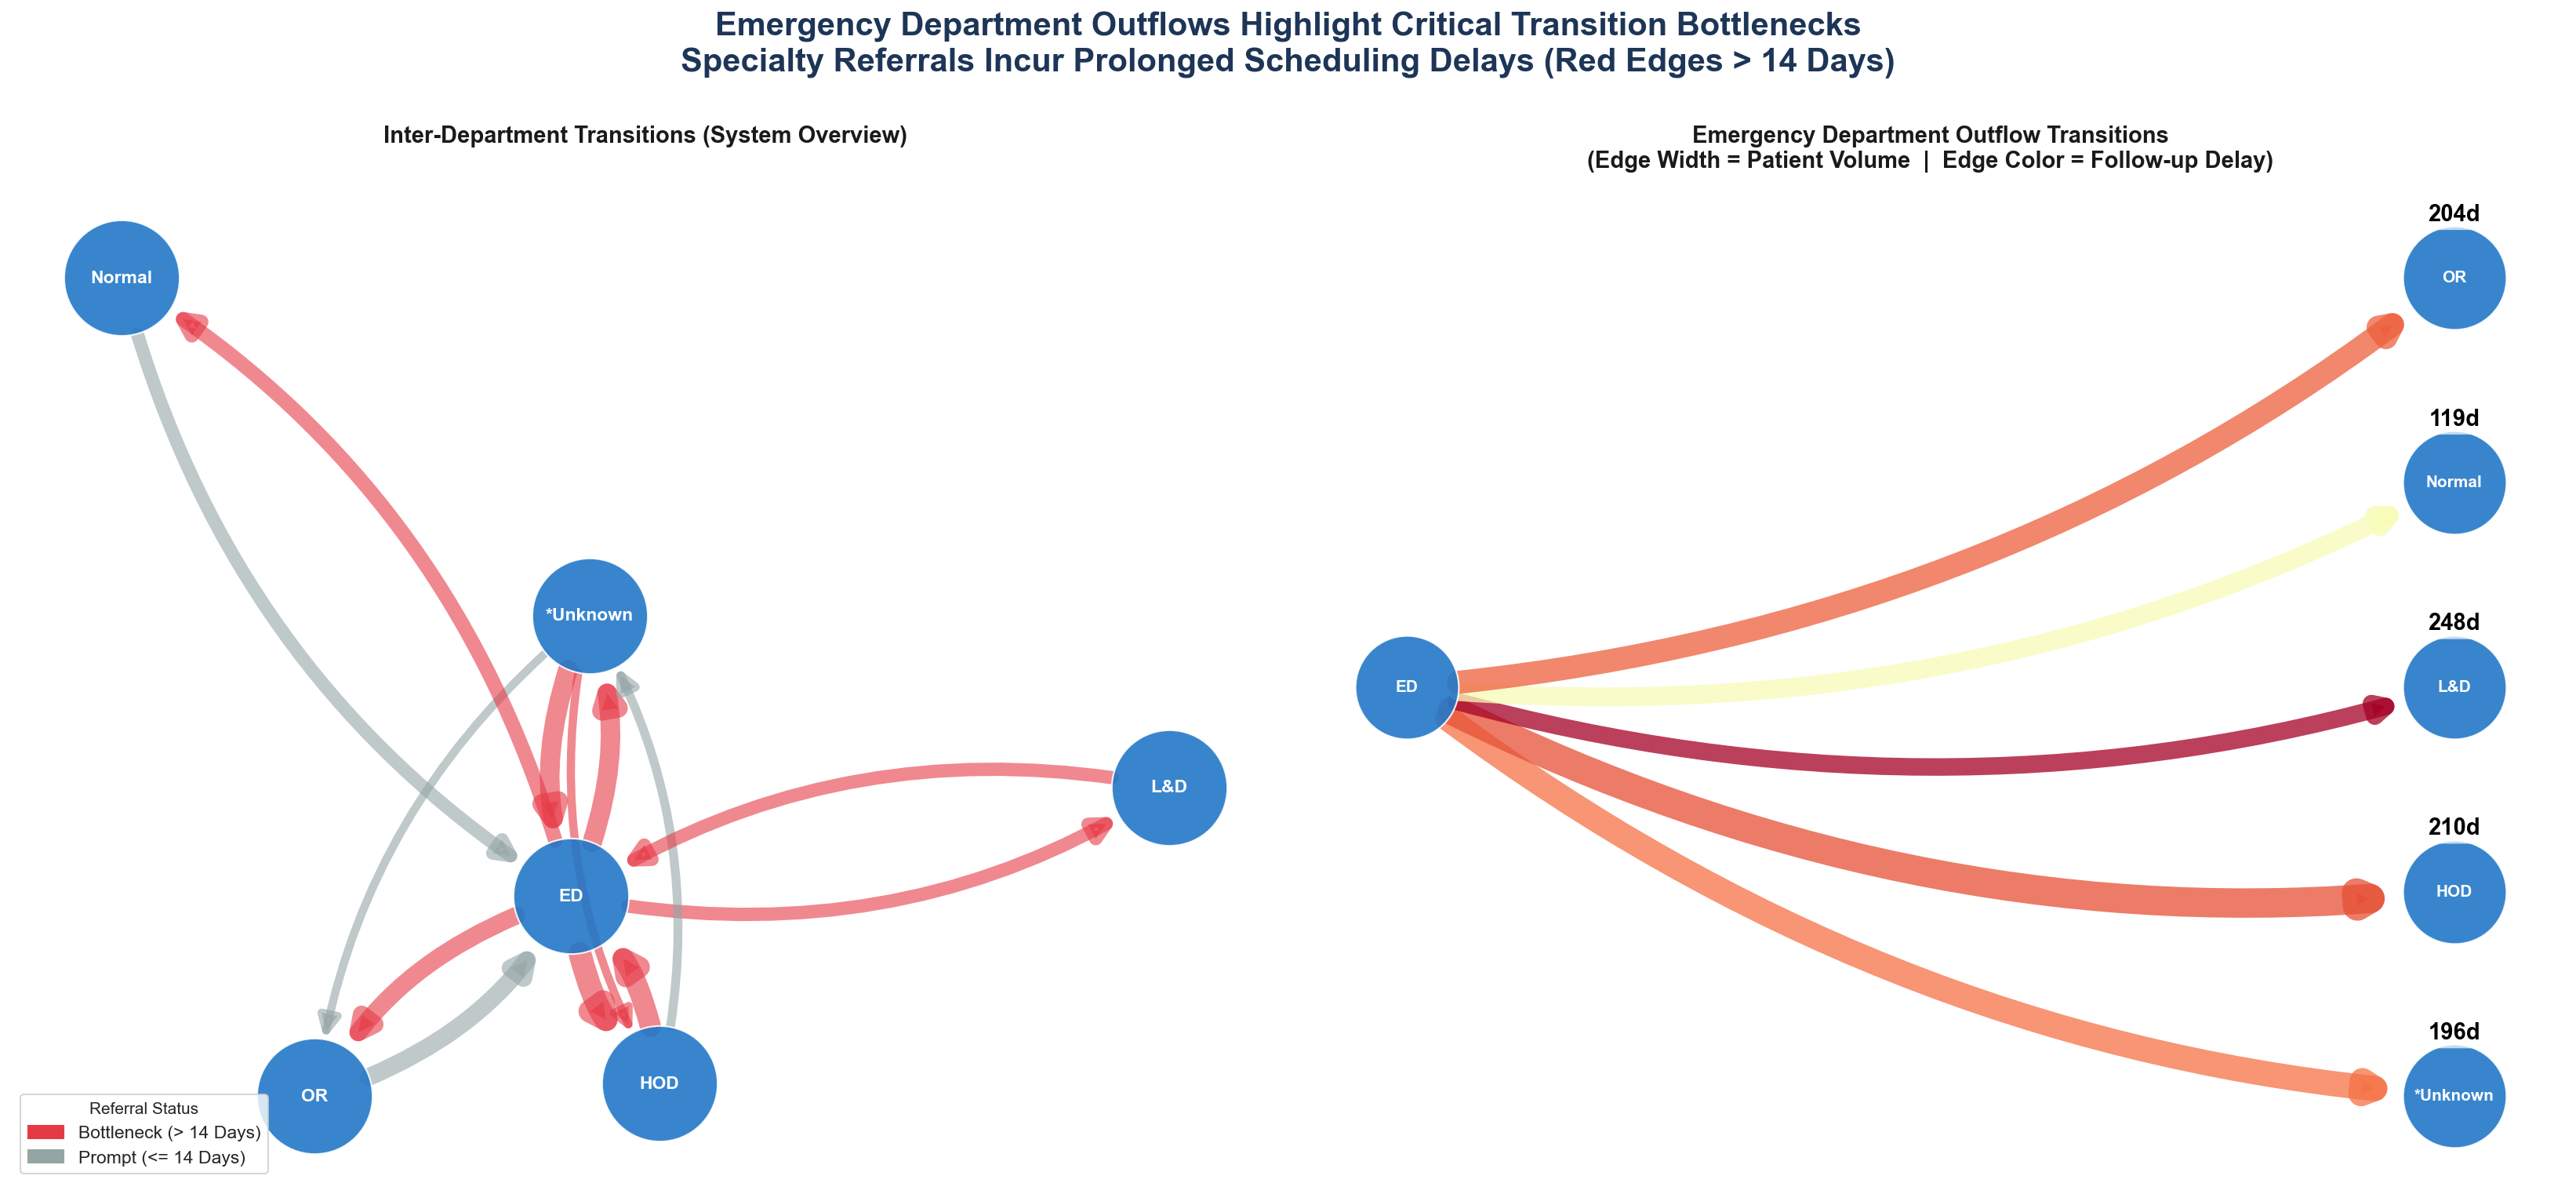

In [18]:
target_spec = "Emergency Medicine"
df_em = (enc_full[enc_full["PrimarySpecialty"] == target_spec]
         .sort_values(["PatientDurableKey","Date"]).copy())
df_em["NextDept"] = df_em.groupby("PatientDurableKey")["DepartmentType"].shift(-1)

sankey_data = (df_em.dropna(subset=["NextDept"])
               .groupby(["DepartmentType","NextDept"])
               .agg(Volume=("PatientDurableKey","count"),
                    AvgGap=("GapDays","mean"))
               .reset_index()
               .query("Volume > 5"))

if not sankey_data.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))
    fig.patch.set_facecolor("white")
    fig.suptitle(
        "Emergency Department Outflows Highlight Critical Transition Bottlenecks\n"
        "Specialty Referrals Incur Prolonged Scheduling Delays (Red Edges > 14 Days)",
        fontsize=20, fontweight="bold", y=1.01, color="#1d3557"
    )

    G1 = nx.DiGraph()
    for _, row in sankey_data.iterrows():
        if row["DepartmentType"] != row["NextDept"]:
            G1.add_edge(row["DepartmentType"],
                        row["NextDept"],
                        weight=row["Volume"],
                        avg_gap=row["AvgGap"])

    if len(G1.nodes) > 0:
        pos1    = nx.spring_layout(G1, k=3.5, seed=42)
        volumes1= np.array([G1[u][v]["weight"] for u,v in G1.edges()])
        widths1 = 2 + (np.log1p(volumes1) / np.log1p(volumes1.max()+1) * 12)
        colors1 = [C_HIGHLIGHT if G1[u][v]["avg_gap"] > 14 else "#95a5a6" for u,v in G1.edges()]

        nx.draw_networkx_nodes(G1, pos1, ax=ax1, node_size=5000,
                               node_color="#2278c8", edgecolors="white", alpha=0.9)
        nx.draw_networkx_labels(G1, pos1, ax=ax1, font_size=11,
                                font_weight="bold", font_color="white")
        nx.draw_networkx_edges(G1, pos1, ax=ax1, width=widths1, edge_color=colors1,
                               arrowstyle="-|>", arrowsize=25,
                               connectionstyle="arc3, rad=0.2", alpha=0.6,
                               node_size=5000)
    ax1.set_title("Inter-Department Transitions (System Overview)\n",
                  fontsize=14, fontweight="bold", pad=15)
    ax1.axis("off")
    ax1.legend(handles=[mpatches.Patch(color=C_HIGHLIGHT, label="Bottleneck (> 14 Days)"),
                         mpatches.Patch(color="#95a5a6",label="Prompt (<= 14 Days)")],
               loc="lower left",
               title="Referral Status",
               fontsize=11)

    outflow = sankey_data[(sankey_data["DepartmentType"]=="ED") &
                           (sankey_data["NextDept"]!="ED")].copy()

    G2 = nx.DiGraph()
    for _, row in outflow.iterrows():
        G2.add_edge(row["DepartmentType"],
                    row["NextDept"],
                    weight=row["Volume"],
                    avg_gap=row["AvgGap"])

    if len(G2.nodes) > 1:
        nodes_target = [n for n in G2.nodes() if n != "ED"]
        pos2 = {n: (1, i/(max(len(nodes_target)-1,1))) for i,n in enumerate(nodes_target)}
        pos2["ED"] = (0, 0.5)

        volumes2 = np.array([G2[u][v]["weight"] for u,v in G2.edges()])
        widths2  = 3 + (np.log1p(volumes2) / np.log1p(volumes2.max()+1) * 15)
        max_gap  = max(G2[u][v]["avg_gap"] for u,v in G2.edges())
        edge_colors2 = [plt.cm.RdYlGn_r(G2[u][v]["avg_gap"]/max(max_gap,1))
                        for u,v in G2.edges()]

        nx.draw_networkx_nodes(G2, pos2, ax=ax2, node_size=4000,
                               node_color="#2278c8", edgecolors="white", alpha=0.9)
        nx.draw_networkx_labels(G2, pos2, ax=ax2, font_size=10,
                                font_weight="bold", font_color="white")
        nx.draw_networkx_edges(G2, pos2, ax=ax2, width=widths2,
                               edge_color=edge_colors2, arrowstyle="-|>",
                               arrowsize=20, connectionstyle="arc3,rad=0.15", alpha=0.75,
                               node_size=4000)
        for u,v in G2.edges():
            x_target = pos2[v][0]
            y_target = pos2[v][1]

            y_text = y_target + 0.07
            ax2.text(x_target, y_text, f"{G2[u][v]['avg_gap']:.0f}d",
                     fontsize=14, ha="center", color="black", fontweight="bold",
                     bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))
    ax2.set_title("Emergency Department Outflow Transitions\n(Edge Width = Patient Volume  |  Edge Color = Follow-up Delay)",
                  fontsize=14, fontweight="bold", pad=15)
    ax2.axis("off")

    plt.tight_layout()
    plt.show()


### 3.3 Follow-up Interval Distributions Across High-Load Specialties

To examine whether delays are consistent or heavily right-skewed with severe outliers, we evaluate the distribution of follow-up intervals (`GapDays`) across the eight highest-workload specialties.


[Kruskal-Wallis Test] GapDays across top 8 high-load specialties
  H = 7,363.30 | p < 0.001 (highly significant)


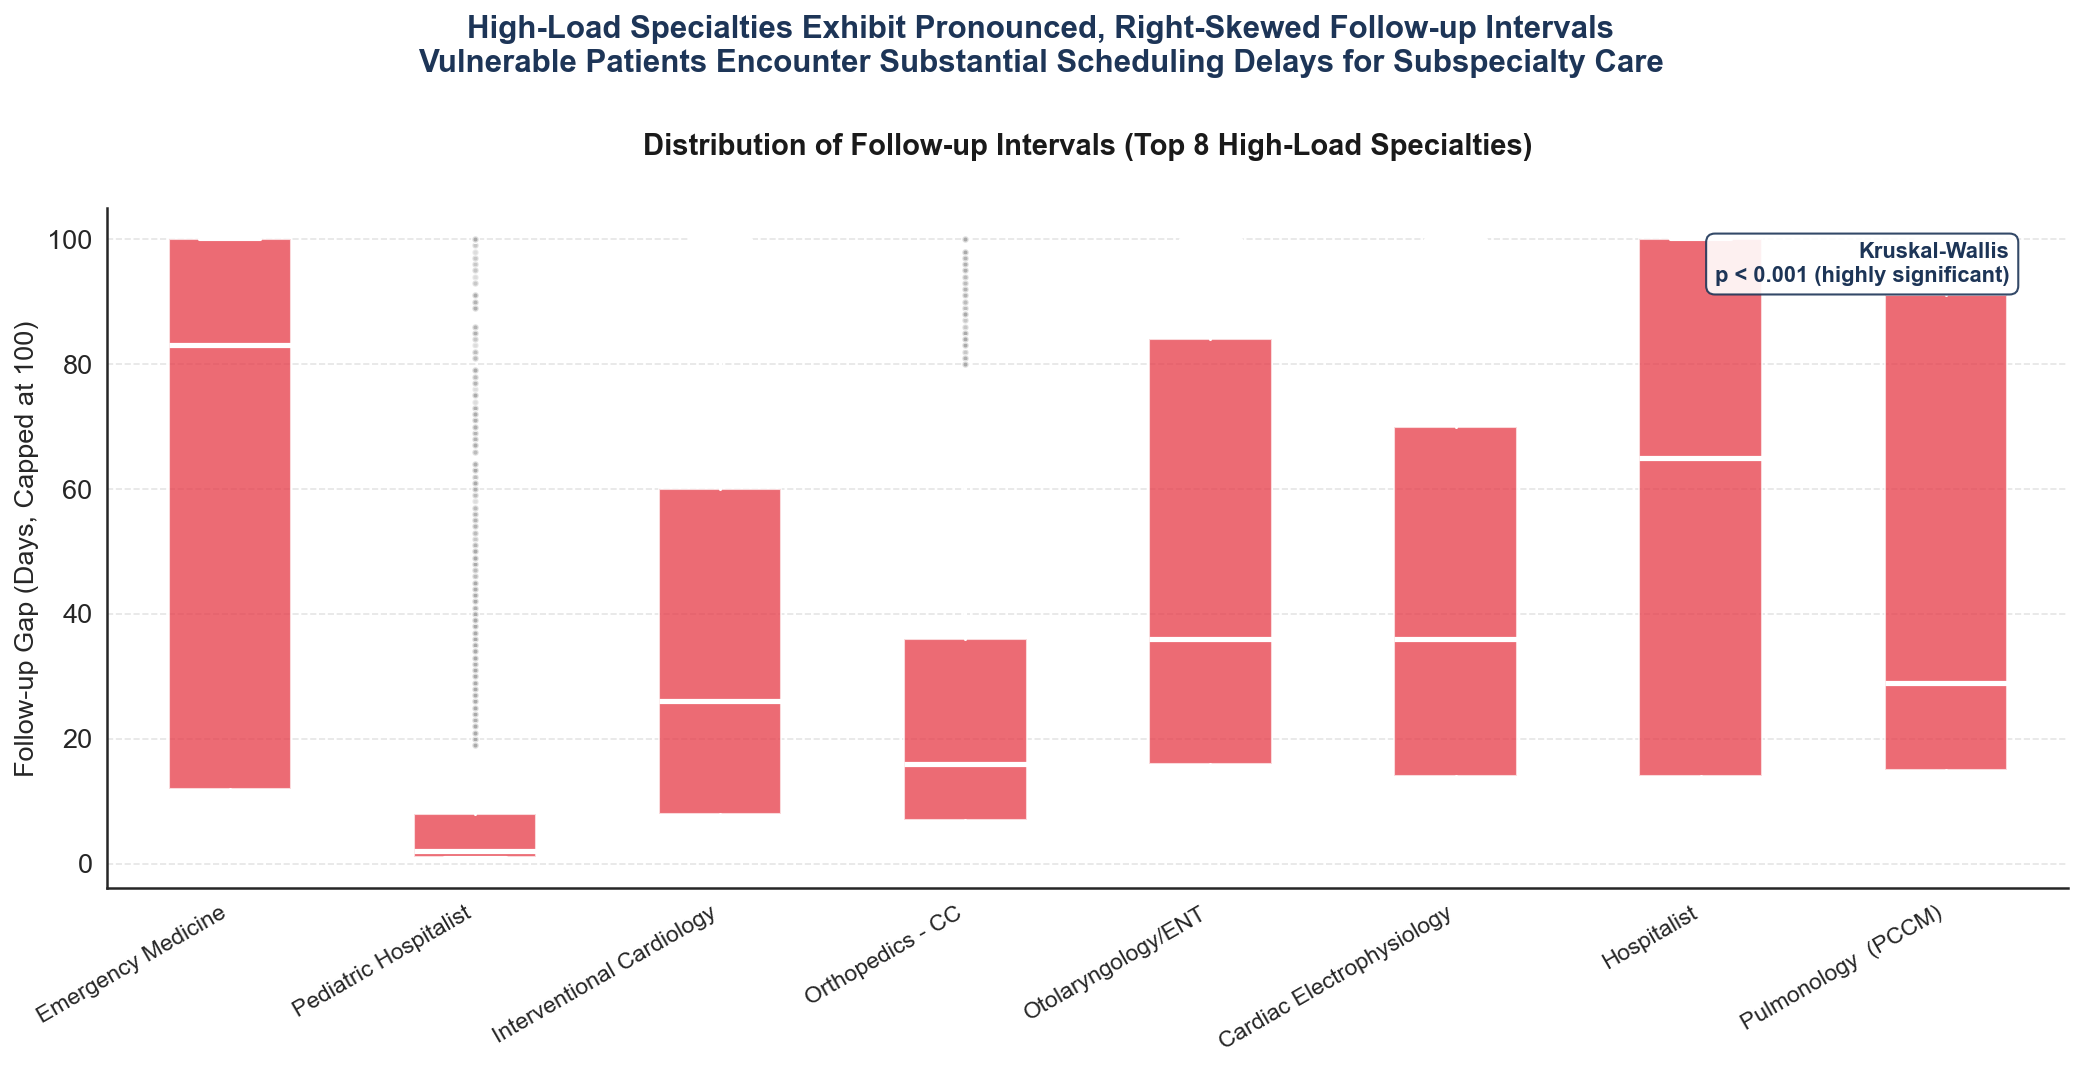

In [19]:
top_spec = load_df.nlargest(8, "PatPerProvider")["PrimarySpecialty"].tolist()
enc_bot  = enc_hv[enc_hv["PrimarySpecialty"].isin(top_spec)].dropna(subset=["GapDays"])
enc_bot  = enc_bot[enc_bot["GapDays"] > 0]

data_v = [enc_bot[enc_bot["PrimarySpecialty"] == sp]["GapDays"].clip(upper=100).values
          for sp in top_spec]

kw_stat4, kw_p4 = run_kruskal(enc_bot, "PrimarySpecialty", "GapDays",
                               label="GapDays across top 8 high-load specialties")

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor("white")
fig.suptitle(
    "High-Load Specialties Exhibit Pronounced, Right-Skewed Follow-up Intervals\n"
    "Vulnerable Patients Encounter Substantial Scheduling Delays for Subspecialty Care",
    fontsize=15, fontweight="bold", y=1.01, color="#1d3557"
)

box = ax.boxplot(data_v, positions=range(len(top_spec)),
                 patch_artist=True, notch=False,
                 medianprops=dict(color="white", linewidth=2.5),
                 flierprops=dict(marker="o", markerfacecolor="#aaa", markersize=3, alpha=0.4),
                 whiskerprops=dict(linewidth=1.5),
                 capprops=dict(linewidth=1.5))

for patch in box["boxes"]:
    patch.set_facecolor(C_HIGHLIGHT)
    patch.set_alpha(0.75)

ax.set_xticks(range(len(top_spec)))
ax.set_xticklabels(top_spec, rotation=30, ha="right", fontsize=11)
ax.set_ylabel("Follow-up Gap (Days, Capped at 100)", fontsize=13)
ax.set_title("Distribution of Follow-up Intervals (Top 8 High-Load Specialties)\n",
             fontweight="bold", fontsize=14, pad=10)

ax.yaxis.grid(True, linestyle="--", alpha=0.5, color="#cccccc")
ax.set_axisbelow(True)
for sp in ["top","right"]: ax.spines[sp].set_visible(False)
stat_annotation(ax, f"Kruskal-Wallis\n{sig_label(kw_p4)}", loc="upper right")

plt.tight_layout()
plt.show()


---

## 4.0 Financial Modeling: Quantifying the Value of Avoidable ED Redirection

To translate clinical disparities into financial reality, we benchmark against Healthcare Cost and Utilization Project (HCUP) national hospital cost data:
- Average emergency department encounter cost: **~$2,200**
- Average scheduled outpatient ambulatory visit cost: **~$250**
- **Net differential per redirected encounter**: **~$1,950**

*Modeling Question*: If transportation-affected patients (Transport Only + Both Barriers) utilized the Emergency Department at the baseline rate of socially secure patients, how many emergency encounters could be avoided, and what are the quantifiable annual cost savings?


=== ESTIMATED AVOIDABLE ED ENCOUNTERS ===
Baseline ED Visit Rate (Screened, No Barrier):   3.0%
Transportation-Affected Patient Population:       2,986
Actual ED Encounters (4-Year Period):                 14,445
Expected Encounters at Baseline Rate:                  6,382
Excess (Potentially Avoidable) ED Encounters:          8,063

Net Savings per Redirected Encounter:             $     1,950
Potential Total Annual Savings:                   $ 3,930,520
[Two-Proportion Z-Test] ED Rate: Transport-Affected vs. No Barrier Baseline
  p1 = 6.82% | p2 = 2.37% | z = 122.36 | p < 0.001 (highly significant)


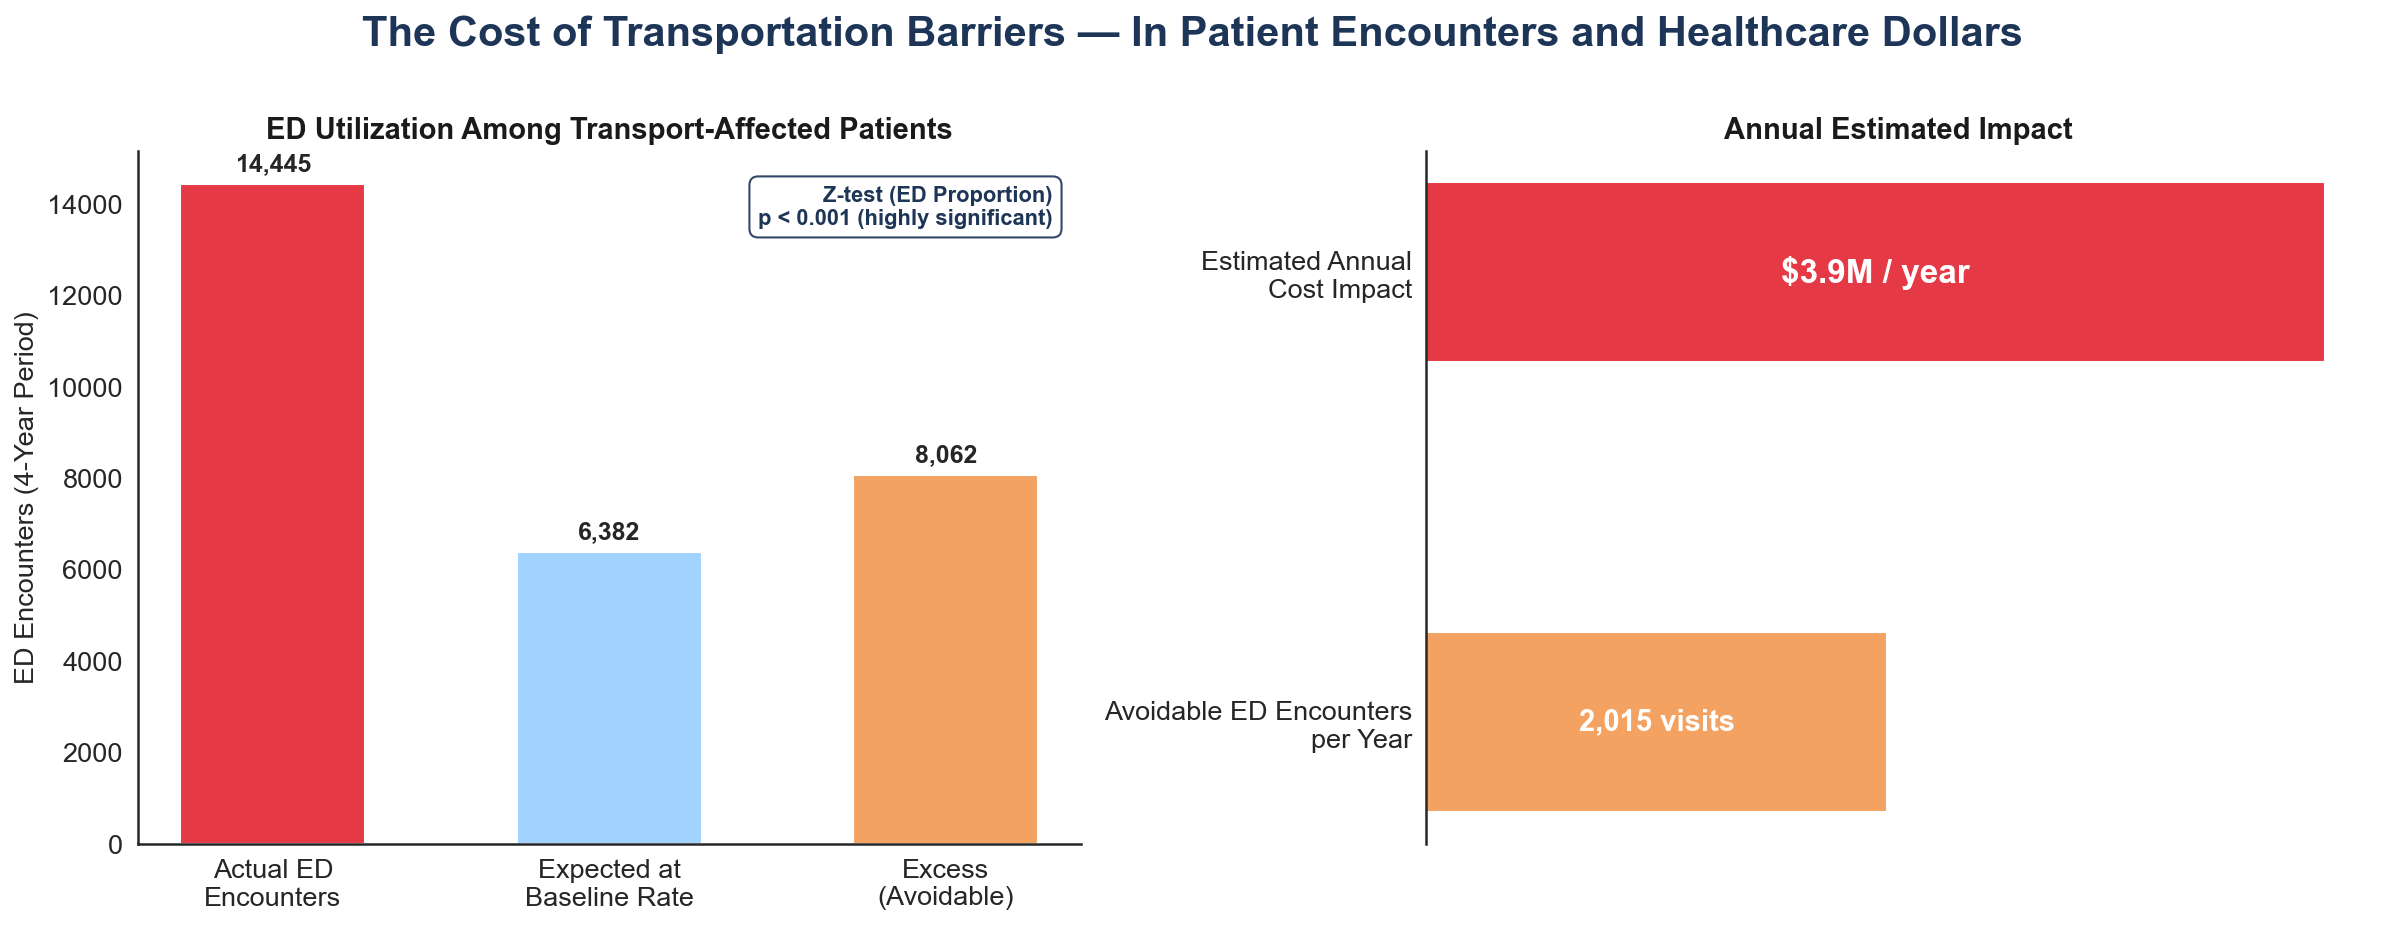


=== SENSITIVITY ANALYSIS: ANNUAL COST REDUCTION SCENARIOS ===
                     Scenario Assumed % Redirected Avoidable ED Visits / Year Estimated Annual Savings
Conservative (25% Redirected)                  25%                        504                 $982,630
    Moderate (50% Redirected)                  50%                      1,008               $1,965,260
 Upper Bound (75% Redirected)                  75%                      1,512               $2,947,890


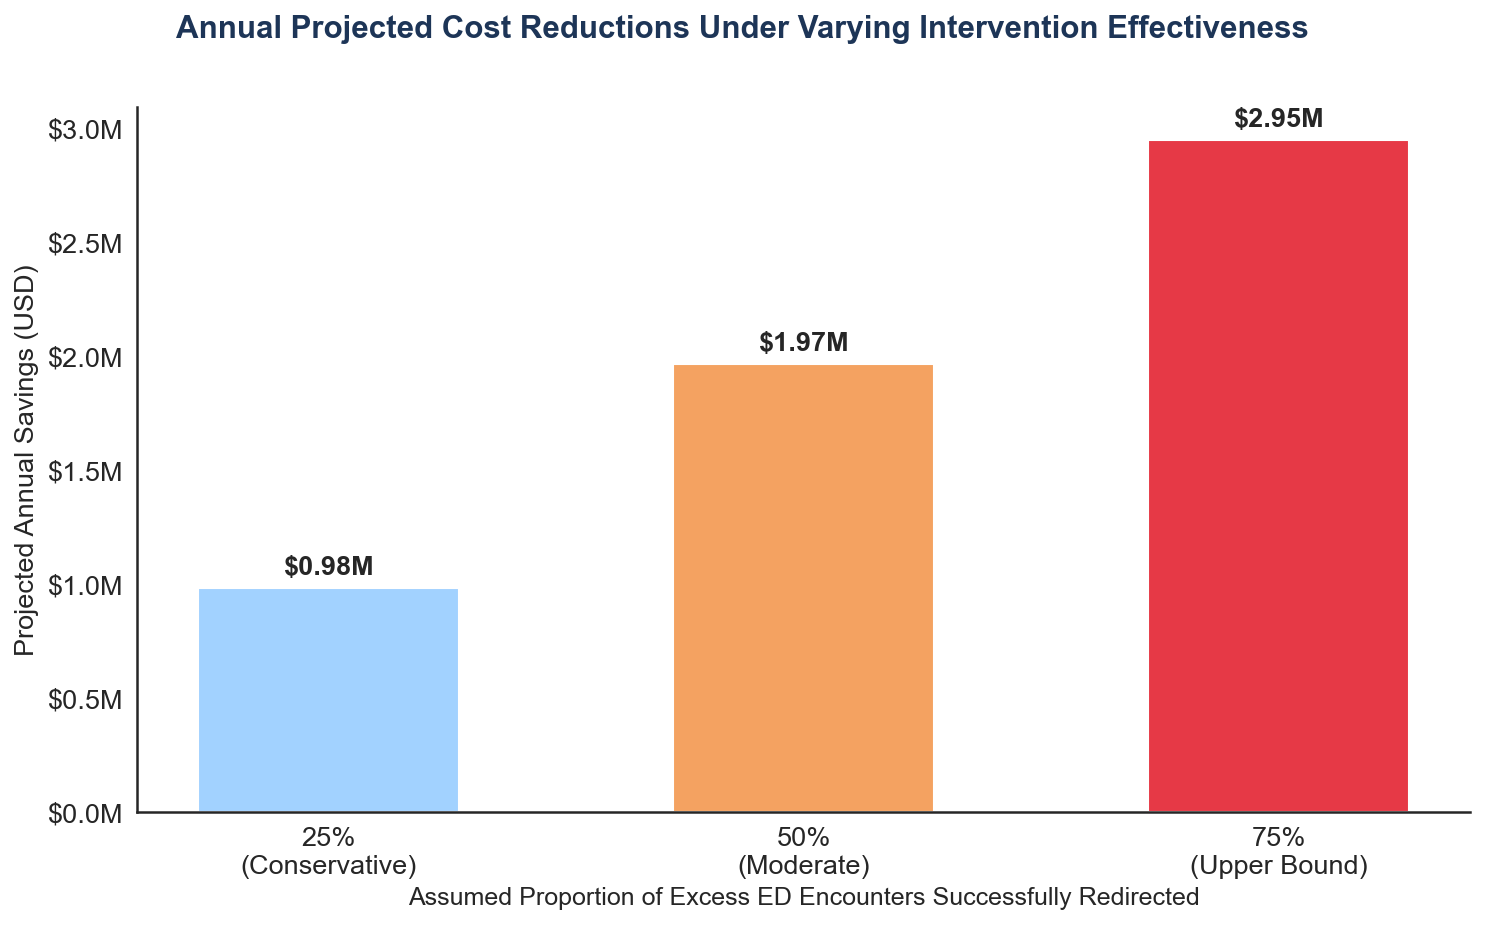

In [20]:
baseline_rate = patient_summary[patient_summary["Barrier_Group"]=="No Barrier"]["ed_rate"].mean() / 100

transport_affected = patient_summary[patient_summary["Barrier_Group"].isin(["Transport Only","Both Barriers"])]
actual_ed   = transport_affected["ed_visits"].sum()
expected_ed = (transport_affected["total_visits"] * baseline_rate).sum()
excess_ed   = actual_ed - expected_ed

ED_COST     = 2200
OFFICE_COST = 250
savings_per_visit = ED_COST - OFFICE_COST
total_savings  = excess_ed * savings_per_visit
annual_savings = total_savings / 4

print("=== ESTIMATED AVOIDABLE ED ENCOUNTERS ===")
print(f"Baseline ED Visit Rate (Screened, No Barrier):   {baseline_rate*100:.1f}%")
print(f"Transportation-Affected Patient Population:       {len(transport_affected):,}")
print(f"Actual ED Encounters (4-Year Period):             {actual_ed:>10,.0f}")
print(f"Expected Encounters at Baseline Rate:             {expected_ed:>10,.0f}")
print(f"Excess (Potentially Avoidable) ED Encounters:     {excess_ed:>10,.0f}")
print(f"\nNet Savings per Redirected Encounter:             ${savings_per_visit:>10,}")
print(f"Potential Total Annual Savings:                   ${annual_savings:>10,.0f}")

_, p_cost = two_proportion_ztest(
    actual_ed, transport_affected["total_visits"].sum(),
    patient_summary[patient_summary["Barrier_Group"]=="No Barrier"]["ed_visits"].sum(),
    patient_summary[patient_summary["Barrier_Group"]=="No Barrier"]["total_visits"].sum(),
    label="ED Rate: Transport-Affected vs. No Barrier Baseline"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("white")
fig.suptitle(
    "The Cost of Transportation Barriers — In Patient Encounters and Healthcare Dollars",
    fontsize=20, fontweight="bold", y=1.02, color="#1d3557"
)

ax = axes[0]
labels = ["Actual ED\nEncounters", "Expected at\nBaseline Rate", "Excess\n(Avoidable)"]
vals_c = [actual_ed, expected_ed, excess_ed]
colors_c = [C_HIGHLIGHT, C_SOFT_BLUE, "#F4A261"]
bars = ax.bar(labels, vals_c, color=colors_c, edgecolor="white", width=0.55)
ax.set_ylabel("ED Encounters (4-Year Period)", fontsize=13)
ax.set_title("ED Utilization Among Transport-Affected Patients", fontweight="bold", fontsize=14)
for b, v in zip(bars, vals_c):
    ax.text(b.get_x()+b.get_width()/2, v + max(vals_c)*0.02, f"{int(v):,}",
            ha="center", fontweight="bold", fontsize=12)
for sp in ["top","right"]: ax.spines[sp].set_visible(False)
stat_annotation(ax, f"Z-test (ED Proportion)\n{sig_label(p_cost)}", loc="upper right")

ax = axes[1]
ax.barh(["Avoidable ED Encounters\nper Year"], [excess_ed/4],
        color="#F4A261", height=0.4, edgecolor="white")
ax.text(excess_ed/4/2, 0, f"{int(excess_ed/4):,} visits",
        ha="center", va="center", fontweight="bold", fontsize=14, color="white")
ax.barh(["Estimated Annual\nCost Impact"], [annual_savings/1000],
        color=C_HIGHLIGHT, height=0.4, edgecolor="white")
ax.text(annual_savings/1000/2, 1, f"${annual_savings/1e6:.1f}M / year",
        ha="center", va="center", fontweight="bold", fontsize=16, color="white")
ax.set_title("Annual Estimated Impact", fontweight="bold", fontsize=14)
ax.set_xticks([])
for sp in ["bottom","top","right"]: ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.show()

scenario_pcts = [0.25, 0.50, 0.75]
scenario_labels = ["Conservative (25% Redirected)", "Moderate (50% Redirected)", "Upper Bound (75% Redirected)"]
scenario_visits_avoided = [excess_ed * p for p in scenario_pcts]
scenario_annual_savings = [v * savings_per_visit / 4 for v in scenario_visits_avoided]

scenarios = pd.DataFrame({
    "Scenario": scenario_labels,
    "Assumed % Redirected": [f"{int(p*100)}%" for p in scenario_pcts],
    "Avoidable ED Visits / Year": [f"{v/4:,.0f}" for v in scenario_visits_avoided],
    "Estimated Annual Savings": [f"${s:,.0f}" for s in scenario_annual_savings],
})
print("\n=== SENSITIVITY ANALYSIS: ANNUAL COST REDUCTION SCENARIOS ===")
print(scenarios.to_string(index=False))

fig_s, ax_s = plt.subplots(figsize=(10, 6))
fig_s.patch.set_facecolor("white")
fig_s.suptitle(
    "Annual Projected Cost Reductions Under Varying Intervention Effectiveness",
    fontsize=15, fontweight="bold", y=1.02, color="#1d3557"
)
colors_s = [C_SOFT_BLUE, "#F4A261", C_HIGHLIGHT]
bars_s = ax_s.bar(["25%\n(Conservative)","50%\n(Moderate)","75%\n(Upper Bound)"],
                   scenario_annual_savings, color=colors_s, edgecolor="white", width=0.55)
for b, v in zip(bars_s, scenario_annual_savings):
    ax_s.text(b.get_x()+b.get_width()/2, v + max(scenario_annual_savings)*0.02,
              f"${v/1e6:.2f}M", ha="center", fontweight="bold", fontsize=13)
ax_s.set_ylabel("Projected Annual Savings (USD)", fontsize=13)
ax_s.set_xlabel("Assumed Proportion of Excess ED Encounters Successfully Redirected", fontsize=12)
ax_s.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f"${x/1e6:.1f}M"))
for sp in ["top","right"]: ax_s.spines[sp].set_visible(False)
plt.tight_layout()
plt.show()


### Interpretation: Financial Impact & Sensitivity Modeling

Our financial modeling indicates that transportation deficits generate **8,063 excess Emergency Department encounters** over 4 years (~2,016 avoidable ED visits annually) across 2,986 transportation-affected patients:

1. **Sensitivity Analysis Across Real-World Scenarios**:
   - **Conservative Scenario (25% Redirected)**: Successfully rerouting one in four excess visits saves **504 ED visits/year**, delivering **~$982,630** in annual gross savings.
   - **Moderate Scenario (50% Redirected)**: Rerouting half of excess visits redirects **1,008 ED visits/year**, yielding **~$1,965,260** annually.
   - **Upper Bound (75% Redirected)**: Rerouting three out of four excess visits saves **1,512 ED visits/year**, generating **~$2,947,890** in recurring annual cost recovery.
2. **Statistical Significance**: The two-proportion Z-test confirms that the ED rate among transport-affected patients (**6.82%**) is significantly higher than the baseline rate (**2.37%**, $z = 122.36, p < 0.001$).

---

## 5.0 Strategic Recommendations for Stormont Vail Health

**1. Targeted Non-Emergency Medical Transportation (NEMT) Partnerships**
Establish an integrated rideshare dispatch agreement (e.g., Uber Health or Lyft Healthcare) directly embedded within the outpatient electronic scheduling system. With rideshare transit averaging ~$15–$30 per trip, replacing an unnecessary $2,200 ED visit with a $250 clinic encounter yields a net savings exceeding **$1,900 per encounter**, achieving rapid return on investment.

**2. High-Touch Bedside MyChart Onboarding for At-Risk Demographics**
Because patients who decline MyChart represent the health system's highest-frequency users (predominantly older adults born $\le 1965$), SVH should replace passive portal invitations with proactive, in-person assistance during clinical encounters. Clinical navigators and medical assistants can assist seniors with account creation and caregiver proxy access.

**3. Mobile Clinic Deployments in Geographic Hotspot Counties**
As identified in Section 1.4, patients in surrounding rural and semi-rural counties (e.g., Harvey, Butler, Russell) encounter logistical barriers traveling to central medical centers. Deploying mobile health clinics on rotating weekly schedules can deliver proactive chronic disease management directly to community hubs.

**4. Targeted Outpatient Capacity Expansion & Cross-Scheduling**
Transportation support is ineffective if outpatient appointment slots remain unavailable. Hospital leadership should streamline referral pathways and expand mid-level provider capacity (NPs/PAs) in severely bottlenecked specialties like Pulmonary Medicine and Neurology.


---

## 6.0 Methodological Limitations

Before leveraging these findings for clinical governance or financial budgeting, several methodological limitations must be considered:

1. **Observational Cross-Sectional Design**:
   This analysis is observational. Statistical associations—including adjusted odds ratios from multivariable logistic regression—demonstrate correlation, not definitive causality. Interventions should be piloted in randomized or phased rollouts to establish causal treatment effects.
2. **Imperfect Clinical Severity Proxy**:
   Comorbidity burden was modeled using unique diagnosis counts rather than standardized risk scores (such as the Charlson Comorbidity Index or Elixhauser Score). Residual confounding from unmeasured clinical acuity may partially explain elevated utilization.
3. **National Cost Proxy Benchmarks**:
   Financial modeling utilizes national median cost benchmarks from the Healthcare Cost and Utilization Project (HCUP: $2,200/ED encounter, $250/outpatient visit). Actual internal cost accounting and reimbursement structures at Stormont Vail Health will vary.
4. **Screening Documentation Selectivity**:
   SDOH screening data reflects patients who were actively surveyed. If providers systematically screen patients who appear visibly fragile or economically distressed, selection bias may influence observed proportions.
5. **Demographic Approximations**:
   Patient age was approximated using midpoints of 5-year birth bins (`PatientBirthYearBin`), which introduces minor discretization noise.


---

## 7.0 Executive Summary

### Q&A
- **Does socioeconomic hardship directly drive emergency department utilization?**
  Yes. Patients with co-occurring transportation and financial barriers have a **71.2% probability** of visiting the ED (vs. **41.6%** for barrier-free patients) and maintain a mean ED visit rate of **13.44%** (vs. **3.01%**). Controlling for age and comorbidity burden, dual-barrier patients face **4.57 times higher odds** of ED utilization ($p < 0.001$).
- **Are high-utilization vulnerable patients disengaged from digital health tools?**
  Yes. Patients who explicitly decline MyChart portal adoption average the highest encounter volume across the health system ($H = 440,124.80, p < 0.001$), driven by older adults born $\le 1965$ who manage complex chronic conditions.
- **Does high physician patient load linearly cause longer follow-up delays?**
  No. Follow-up interval length does not linearly correlate with provider workload ($r = 0.058, p = 0.697$), indicating that appointment bottlenecks are specialty-specific rather than solely a function of patient-to-provider ratios.

### Data Analysis Key Findings
- **Compounded Risk Multiplier**: Disease journeys involving dual barriers exhibit a **51.4% ED visit rate** compared to **8.4%** for barrier-free journeys ($\chi^2 = 6,438.43, p < 0.001$).
- **Chronic Condition Primacy**: Top diagnoses among barrier-affected cohorts are manageable chronic conditions (hypertension, diabetes, spinal disorders; $\chi^2 = 80,822.07, p < 0.001$), confirming that avoidable ED visits stem from outpatient care breakdown.
- **Mortality Profile & Demographics**: Crude mortality is highest in the Transport Only cohort (**3.51%**) and lowest in Financial Only (**2.06%**, $\chi^2 = 8.88, p = 0.031$), reflecting age composition (older mobility-impaired adults vs. younger working-age individuals).
- **Financial Cost Recovery**: Addressing transportation barriers could prevent **~2,016 excess ED visits annually**, generating an estimated net savings of **$982,630 to $2,947,890 per year**.

### Insights or Next Steps
- **Immediate Next Step**: Pilot an electronic health record (EHR)-integrated non-emergency medical transportation program (e.g., rideshare subsidies) targeting patients with scheduled appointments who screen positive for transportation needs.
- **Strategic Next Step**: Deploy dedicated bedside digital navigators to assist senior patients in activating patient portals and designate care coordinators to fast-track post-ED specialty referrals.
